In [ ]:
#  Prospective CAIP simple metrics: 
# Fill in data_dir and H5 filenames, then run this cell.
# CAIP6 is used as a surrogate baseline, not a fully sampled ground truth.
%matplotlib widget

import os
import numpy as np
import h5py
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.widgets import RectangleSelector
import ipywidgets as widgets
from IPython.display import display


from skimage.metrics import structural_similarity as ssim


# -------------------------------------------------------------------------
# 
# -------------------------------------------------------------------------
data_dir = '/home/vault/iwbi/iwbi112h/CEST_DATA_06052026'  # e.g. '/home/vault/.../PROSPECTIVE_CAIP/'
h5_dataset = 'imgs'

Regs_list=['0.01','0.001']
SENSE_Reg=Regs_list[1]
LLR_Reg=Regs_list[0]
caip_h5 = {
    'LLR': {
        6: 'CEST_APT_C6/'\
            f'CEST_LLR_recons_Reps_0_26_RO_0_120_1x5x5_r_{LLR_Reg}_i_30_R26_C58_C6_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R26_C58_C6_imgs.h5',
        12: 'CEST_APT_C12/'\
            f'CEST_LLR_recons_Reps_0_26_RO_0_120_1x5x5_r_{LLR_Reg}_i_30_R26_C58_C12_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R26_C58_C12_imgs.h5',
        16: 'CEST_APT_C16/'\
            f'CEST_LLR_recons_Reps_0_26_RO_0_120_1x5x5_r_{LLR_Reg}_i_30_R26_C58_C16_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R26_C58_C16_imgs.h5',
    },
    'SENSE': {
        6: 'CEST_APT_C6/'\
            f'CEST_SENSE_recons_Reps_0_26_r_{SENSE_Reg}_i_30_kdat_2D_R26_C58_C6_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R26_C58_C6_imgs.h5',
        12: 'CEST_APT_C12/'\
            f'CEST_SENSE_recons_Reps_0_26_r_{SENSE_Reg}_i_30_kdat_2D_R26_C58_C12_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R26_C58_C12_imgs.h5',
        16: 'CEST_APT_C16/'\
            f'CEST_SENSE_recons_Reps_0_26_r_{SENSE_Reg}_i_30_kdat_2D_R26_C58_C16_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R26_C58_C16_imgs.h5',
    },

    # 'GRAPPA': {
    #     6: '',
    #     12: '',
    #     16: '',
    # },
}

# Optional crop on the x dimension after loading. Python slice(0, 114) keeps x indices 0..113.
# Set a method to None to keep the full x dimension.
x_crop_by_method = {
    'LLR': slice(0, 114),
    'SENSE': slice(0, 114),
    'GRAPPA': None,
}

ref_idx = 0
roi_display_offset_idx = 1  # display-only ROI selector offset; S0 normalization still uses ref_idx
# Adjust offsets to match the prospective protocol.
offsets_caip = np.concatenate(([-300.0], np.arange(-6, 6.1, 0.5)))
sweep_idx_caip = np.arange(1, len(offsets_caip))
SLICE_OFFSET_AVG_EXCLUDE_SLICES = range(0, 9)
image_metric_norm_options = ['robust_minmax', 'minmax', 'zscore', 'ref_peak', 'none']
simple_psnr_normalization_mode = image_metric_norm_options[0]
simple_ssim_normalization_mode = image_metric_norm_options[2]
minmax_robust_percentiles = (0.0005, 0.9995)


# Figure font sizes. Change these three values to control all figures in this cell.
title_fontsize = 16
# title_fontsize = 22
legend_fontsize = 12
# legend_fontsize = 18
axes_label_fontsize = 14

plt.rcParams.update({
    'axes.titlesize': title_fontsize,
    'axes.labelsize': axes_label_fontsize,
    'xtick.labelsize': axes_label_fontsize,
    'ytick.labelsize': axes_label_fontsize,
    'legend.fontsize': legend_fontsize,
})


# -------------------------------------------------------------------------
# Helpers
# -------------------------------------------------------------------------
def load_h5_imgs(path, dataset='imgs'):
    with h5py.File(path, 'r') as f:
        return np.asarray(f[dataset])


def available_methods(file_table):
    methods = []
    for method, accels in file_table.items():
        if accels.get(6) and (accels.get(12) or accels.get(16)):
            methods.append(method)
    return methods


def load_caip_method_volumes(method):
    vols = {}
    for accel, h5_name in caip_h5[method].items():
        if not h5_name:
            continue
        path = os.path.join(data_dir, h5_name)
        if not os.path.exists(path):
            raise FileNotFoundError(f'{method} CAIP{accel} file not found: {path}')
        vol = load_h5_imgs(path, h5_dataset)
        x_crop = x_crop_by_method.get(method)
        if x_crop is not None:
            vol = vol[..., x_crop]
        vols[accel] = vol

    if 6 not in vols:
        raise ValueError(f'{method} needs CAIP6 as baseline.')
    if not any(a in vols for a in [12, 16]):
        raise ValueError(f'{method} needs CAIP12 and/or CAIP16 for comparison.')

    shapes = {accel: vol.shape for accel, vol in vols.items()}
    if len(set(shapes.values())) != 1:
        raise ValueError(f'{method} volume shapes must match. Got: {shapes}')
    if vols[6].shape[0] != len(offsets_caip):
        raise ValueError(
            f'{method}: data has {vols[6].shape[0]} offsets, but offsets_caip has {len(offsets_caip)}.'
        )
    print(f'{method} loaded shapes:', shapes)
    return vols


def mag(x):
    return np.abs(np.asarray(x))


def normalize_by_s0(z):
    z = np.asarray(z, dtype=np.float64)
    s0 = z[ref_idx]
    if not np.isfinite(s0) or s0 == 0:
        return np.full_like(z, np.nan, dtype=np.float64)
    return z / s0


def relative_l2_nrmse(test_vec, ref_vec):
    valid = np.isfinite(test_vec) & np.isfinite(ref_vec)
    if not np.any(valid):
        return np.nan
    denom = np.sqrt(np.nanmean(ref_vec[valid] ** 2))
    if not np.isfinite(denom) or denom == 0:
        return np.nan
    return np.sqrt(np.nanmean((test_vec[valid] - ref_vec[valid]) ** 2)) / denom


def simple_loaded_method_names():
    return list(loaded_simple.keys())


def global_caip_shared_mask(loaded_methods, methods, slice_idx, frac=0.05):
    """One shared support mask across all loaded methods and CAIP accelerations.

    The threshold is computed from each method's own CAIP6 S0 image, then
    supports are intersected across CAIP6/12/16 for every loaded method.
    This keeps LLR, SENSE, GRAPPA, and future methods on identical pixels.
    """
    mask = None
    shape_yx = None
    for method in methods:
        vols = loaded_methods[method]
        base_s0 = mag(vols[6][ref_idx, slice_idx])
        if shape_yx is None:
            shape_yx = base_s0.shape
            mask = np.ones(shape_yx, dtype=bool)
        elif base_s0.shape != shape_yx:
            raise ValueError(f'{method} CAIP6 slice shape {base_s0.shape} does not match shared mask shape {shape_yx}.')

        finite_base = np.isfinite(base_s0)
        thresh = frac * np.nanmax(base_s0) if np.any(finite_base) else np.inf
        method_mask = finite_base & (base_s0 > thresh)

        for accel, vol in vols.items():
            s0 = mag(vol[ref_idx, slice_idx])
            if s0.shape != shape_yx:
                raise ValueError(f'{method} CAIP{accel} slice shape {s0.shape} does not match shared mask shape {shape_yx}.')
            method_mask &= np.isfinite(s0) & (s0 > 0)

        mask &= method_mask

    if mask is None:
        raise ValueError('No loaded methods available to build the global CAIP shared mask.')
    return mask


def compute_z_nrmse_map(vols, accel, slice_idx, mask):
    """Per-pixel S0-normalized Z-spectrum nRMSE: CAIP{accel} vs CAIP6."""
    _, _, ydim, xdim = vols[6].shape
    nrmse_map = np.full((ydim, xdim), np.nan, dtype=np.float64)

    for iy, ix in np.argwhere(mask):
        z6 = normalize_by_s0(vols[6][:, slice_idx, iy, ix])
        zt = normalize_by_s0(vols[accel][:, slice_idx, iy, ix])
        nrmse_map[iy, ix] = relative_l2_nrmse(zt[sweep_idx_caip], z6[sweep_idx_caip])

    return nrmse_map



def nearest_positive_ppm(ppm):
    positive = offsets_caip[offsets_caip > 0]
    if positive.size == 0:
        raise ValueError('offsets_caip must include positive offsets for MTRasym.')
    return float(positive[np.argmin(np.abs(positive - ppm))])


def mtr_asym_value(z_norm, ppm):
    pos_idx = np.where(np.isclose(offsets_caip, ppm))[0]
    neg_idx = np.where(np.isclose(offsets_caip, -ppm))[0]
    if pos_idx.size == 0 or neg_idx.size == 0:
        return np.nan
    z_pos = z_norm[pos_idx[0]]
    z_neg = z_norm[neg_idx[0]]
    if not np.isfinite(z_pos) or not np.isfinite(z_neg) or z_neg == 0:
        return np.nan
        ############
    #    Normalized MTRasym
        ############
    # return (z_neg - z_pos) / z_neg

    ############
    #   Non-Normalized MTRasym
    ############
    return (z_neg - z_pos)


def compute_mtr_asym_delta_map(vols, accel, slice_idx, mask, ppm):
    """ MTRasym map at one positive ppm: CAIP{accel} - CAIP6."""
    _, _, ydim, xdim = vols[6].shape
    delta_map = np.full((ydim, xdim), np.nan, dtype=np.float64)
    mtr_base_map = np.full((ydim, xdim), np.nan, dtype=np.float64)
    mtr_test_map = np.full((ydim, xdim), np.nan, dtype=np.float64)

    for iy, ix in np.argwhere(mask):
        z6 = normalize_by_s0(vols[6][:, slice_idx, iy, ix])
        zt = normalize_by_s0(vols[accel][:, slice_idx, iy, ix])
        m6 = mtr_asym_value(z6, ppm)
        mt = mtr_asym_value(zt, ppm)
        mtr_base_map[iy, ix] = m6
        mtr_test_map[iy, ix] = mt
        if np.isfinite(m6) and np.isfinite(mt):
            delta_map[iy, ix] = mt - m6

    return delta_map, mtr_base_map, mtr_test_map


def compute_psnr_per_offset(vols, accel, slice_idx, mask, norm_slice_masks=None):
    """Selected-slice PSNR/MSE per offset using retrospective-style normalization."""
    ref = mag(vols[6])
    test = mag(vols[accel])
    n_offsets, zdim = ref.shape[:2]
    psnr = np.full(n_offsets, np.nan, dtype=np.float64)
    mse = np.full(n_offsets, np.nan, dtype=np.float64)
    data_ranges = np.full(n_offsets, np.nan, dtype=np.float64)
    if norm_slice_masks is None:
        norm_slice_masks = {int(slice_idx): mask}
    norm_mask_3d = slice_masks_to_volume_mask(norm_slice_masks, zdim)

    for i in range(n_offsets):
        ref_n, test_n, data_ranges[i], valid_vol = normalize_simple_offset_volume_pair(
            ref[i],
            test[i],
            norm_mask_3d,
            mode=simple_psnr_normalization_mode,
        )
        ref_img = ref_n[slice_idx]
        test_img = test_n[slice_idx]
        valid = valid_vol[slice_idx] & mask & np.isfinite(ref_img) & np.isfinite(test_img)
        if np.isfinite(data_ranges[i]) and np.any(valid):
            mse[i] = np.nanmean((ref_img[valid] - test_img[valid]) ** 2)
            if mse[i] > 0:
                psnr[i] = 10.0 * np.log10((data_ranges[i] ** 2) / mse[i])

    return psnr, mse, data_ranges


def compute_ssim_per_offset(vols, accel, slice_idx, mask, norm_slice_masks=None):
    """Selected-slice SSIM per offset using retrospective-style normalization."""
    scores = np.full(vols[6].shape[0], np.nan, dtype=np.float64)
    if ssim is None:
        return scores

    ref = mag(vols[6])
    test = mag(vols[accel])
    n_offsets, zdim = ref.shape[:2]
    if norm_slice_masks is None:
        norm_slice_masks = {int(slice_idx): mask}
    norm_mask_3d = slice_masks_to_volume_mask(norm_slice_masks, zdim)

    for i in range(n_offsets):
        ref_n, test_n, data_range, valid_vol = normalize_simple_offset_volume_pair(
            ref[i],
            test[i],
            norm_mask_3d,
            mode=simple_ssim_normalization_mode,
        )
        if not np.isfinite(data_range):
            continue
        ref_img = ref_n[slice_idx]
        test_img = test_n[slice_idx]
        valid = valid_vol[slice_idx] & mask & np.isfinite(ref_img) & np.isfinite(test_img)
        if np.count_nonzero(valid) >= 3:
            try:
                scores[i] = float(
                    ssim(
                        ref_img[valid],
                        test_img[valid],
                        win_size=3,
                        data_range=data_range,
                        gaussian_weights=False,
                    )
                )
            except ValueError:
                scores[i] = np.nan
    return scores


def slice_offset_average_slices(zdim):
    excluded = set(int(z) for z in SLICE_OFFSET_AVG_EXCLUDE_SLICES)
    eval_slices = np.asarray([z for z in range(zdim) if z not in excluded], dtype=int)
    if eval_slices.size == 0:
        raise ValueError('No slices remain after excluding slices 0-8 for slice-offset averages.')
    return eval_slices


def _finite_1d(values):
    values = np.asarray(values, dtype=np.float64).ravel()
    return values[np.isfinite(values)]


def normalize_simple_offset_volume_pair(ref_vol, test_vol, norm_mask_3d, mode=None, robust_quantiles=None, eps=1e-8):
    if mode is None:
        raise ValueError('normalize_simple_offset_volume_pair requires an explicit mode.')
    robust_quantiles = minmax_robust_percentiles if robust_quantiles is None else robust_quantiles
    ref_vol = np.asarray(ref_vol, dtype=np.float64)
    test_vol = np.asarray(test_vol, dtype=np.float64)
    norm_mask_3d = np.asarray(norm_mask_3d, dtype=bool)
    valid = norm_mask_3d & np.isfinite(ref_vol) & np.isfinite(test_vol)
    if np.count_nonzero(valid) < 3:
        return ref_vol, test_vol, np.nan, valid

    ref_vals = _finite_1d(ref_vol[valid])
    test_vals = _finite_1d(test_vol[valid])
    if ref_vals.size == 0 or test_vals.size == 0:
        return ref_vol, test_vol, np.nan, valid

    nominal_range = None
    if mode == 'none':
        ref_n = ref_vol
        test_n = test_vol
    elif mode == 'ref_peak':
        scale = np.nanmax(ref_vals)
        if not np.isfinite(scale) or scale <= eps:
            return ref_vol, test_vol, np.nan, valid
        ref_n = ref_vol / scale
        test_n = test_vol / scale
        nominal_range = 1.0
    elif mode == 'minmax':
        ref_min, ref_max = np.nanmin(ref_vals), np.nanmax(ref_vals)
        test_min, test_max = np.nanmin(test_vals), np.nanmax(test_vals)
        ref_range = ref_max - ref_min
        test_range = test_max - test_min
        if not np.isfinite(ref_range) or ref_range <= eps or not np.isfinite(test_range) or test_range <= eps:
            return ref_vol, test_vol, np.nan, valid
        ref_n = (ref_vol - ref_min) / ref_range
        test_n = (test_vol - test_min) / test_range
        nominal_range = 1.0
    elif mode == 'robust_minmax':
        q_low, q_high = robust_quantiles
        ref_min, ref_max = np.nanquantile(ref_vals, [q_low, q_high])
        test_min, test_max = np.nanquantile(test_vals, [q_low, q_high])
        ref_range = ref_max - ref_min
        test_range = test_max - test_min
        if not np.isfinite(ref_range) or ref_range <= eps or not np.isfinite(test_range) or test_range <= eps:
            return ref_vol, test_vol, np.nan, valid
        ref_n = (ref_vol - ref_min) / ref_range
        test_n = (test_vol - test_min) / test_range
        nominal_range = 1.0
    elif mode == 'zscore':
        ref_std = np.nanstd(ref_vals)
        test_std = np.nanstd(test_vals)
        if not np.isfinite(ref_std) or ref_std <= eps or not np.isfinite(test_std) or test_std <= eps:
            return ref_vol, test_vol, np.nan, valid
        ref_n = (ref_vol - np.nanmean(ref_vals)) / ref_std
        test_n = (test_vol - np.nanmean(test_vals)) / test_std
    else:
        raise ValueError(f'Unknown image metric normalization mode: {mode}')

    if nominal_range is not None:
        data_range = nominal_range
    else:
        ref_metric_vals = _finite_1d(ref_n[valid])
        data_range = np.nanmax(ref_metric_vals) - np.nanmin(ref_metric_vals) if ref_metric_vals.size else np.nan
    if not np.isfinite(data_range) or data_range <= 0:
        data_range = np.nan
    return ref_n, test_n, data_range, valid


def slice_masks_to_volume_mask(slice_masks, zdim):
    first_mask = next((mask for mask in slice_masks.values()), None)
    if first_mask is None:
        raise ValueError('slice_masks is empty.')
    mask_3d = np.zeros((zdim,) + first_mask.shape, dtype=bool)
    for z, mask in slice_masks.items():
        mask_3d[int(z)] = mask
    return mask_3d


def compute_psnr_per_offset_slices(vols, accel, slice_masks):
    """PSNR/MSE per offset after retrospective-style robust min-max normalization."""
    ref = mag(vols[6])
    test = mag(vols[accel])
    n_offsets, zdim = ref.shape[:2]
    psnr = np.full(n_offsets, np.nan, dtype=np.float64)
    mse = np.full(n_offsets, np.nan, dtype=np.float64)
    data_ranges = np.full(n_offsets, np.nan, dtype=np.float64)
    mask_3d = slice_masks_to_volume_mask(slice_masks, zdim)

    for i in range(n_offsets):
        ref_n, test_n, data_ranges[i], valid_vol = normalize_simple_offset_volume_pair(
            ref[i],
            test[i],
            mask_3d,
            mode=simple_psnr_normalization_mode,
        )
        valid = valid_vol & mask_3d & np.isfinite(ref_n) & np.isfinite(test_n)
        if np.isfinite(data_ranges[i]) and np.any(valid):
            mse[i] = np.nanmean((ref_n[valid] - test_n[valid]) ** 2)
            if mse[i] > 0:
                psnr[i] = 10.0 * np.log10((data_ranges[i] ** 2) / mse[i])
    return psnr, mse, data_ranges


def compute_ssim_per_offset_slices(vols, accel, slice_masks):
    """SSIM per offset after retrospective-style z-score normalization."""
    scores = np.full(vols[6].shape[0], np.nan, dtype=np.float64)
    if ssim is None:
        return scores

    ref = mag(vols[6])
    test = mag(vols[accel])
    n_offsets, zdim = ref.shape[:2]
    mask_3d = slice_masks_to_volume_mask(slice_masks, zdim)

    for i in range(n_offsets):
        ref_n, test_n, data_range, valid_vol = normalize_simple_offset_volume_pair(
            ref[i],
            test[i],
            mask_3d,
            mode=simple_ssim_normalization_mode,
        )
        if not np.isfinite(data_range):
            continue
        slice_scores = []
        for z in slice_masks:
            ref_img = ref_n[int(z)]
            test_img = test_n[int(z)]
            valid = valid_vol[int(z)] & np.isfinite(ref_img) & np.isfinite(test_img)
            if np.count_nonzero(valid) >= 3:
                try:
                    slice_scores.append(
                        float(
                            ssim(
                                ref_img[valid],
                                test_img[valid],
                                win_size=3,
                                data_range=data_range,
                                gaussian_weights=False,
                            )
                        )
                    )
                except ValueError:
                    pass
        if slice_scores:
            scores[i] = np.nanmean(slice_scores)
    return scores


def compute_prospective_volume_diagnostics(vols, accel, slice_masks, mtr_eval_ppm, psnr, mse, ssim_vals):
    z_vals = []
    mtr_delta_vals = []
    eval_slices = np.asarray(list(slice_masks.keys()), dtype=int)
    for z, mask in slice_masks.items():
        for iy, ix in np.argwhere(mask):
            z6 = normalize_by_s0(vols[6][:, z, iy, ix])
            zt = normalize_by_s0(vols[accel][:, z, iy, ix])
            nrmse = relative_l2_nrmse(zt[sweep_idx_caip], z6[sweep_idx_caip])
            if np.isfinite(nrmse):
                z_vals.append(nrmse)
            m6 = mtr_asym_value(z6, mtr_eval_ppm)
            mt = mtr_asym_value(zt, mtr_eval_ppm)
            if np.isfinite(m6) and np.isfinite(mt):
                mtr_delta_vals.append(mt - m6)

    z_vals = np.asarray(z_vals, dtype=np.float64)
    mtr_delta_vals = np.asarray(mtr_delta_vals, dtype=np.float64)
    return {
        'slice_start': int(eval_slices[0]) if len(eval_slices) else None,
        'slice_stop': int(eval_slices[-1]) if len(eval_slices) else None,
        'slice_count': int(len(eval_slices)),
        'z_nrmse_mean': float(np.nanmean(z_vals)) if z_vals.size else np.nan,
        'z_nrmse_median': float(np.nanmedian(z_vals)) if z_vals.size else np.nan,
        'z_nrmse_count': int(np.isfinite(z_vals).sum()),
        'mse_offset_mean': float(np.nanmean(mse[sweep_idx_caip])) if np.any(np.isfinite(mse[sweep_idx_caip])) else np.nan,
        'psnr_offset_mean': float(np.nanmean(psnr[sweep_idx_caip])) if np.any(np.isfinite(psnr[sweep_idx_caip])) else np.nan,
        'ssim_offset_mean': float(np.nanmean(ssim_vals[sweep_idx_caip])) if np.any(np.isfinite(ssim_vals[sweep_idx_caip])) else np.nan,
        'mtr_abs_mean': float(np.nanmean(np.abs(mtr_delta_vals))) if mtr_delta_vals.size else np.nan,
        'mtr_abs_median': float(np.nanmedian(np.abs(mtr_delta_vals))) if mtr_delta_vals.size else np.nan,
        'mtr_count': int(np.isfinite(mtr_delta_vals).sum()),
        'mtr_ppm': float(mtr_eval_ppm),
    }


def bounds_to_roi(shape_yx, bounds):
    ydim, xdim = shape_yx
    if bounds is None:
        return np.ones((ydim, xdim), dtype=bool)
    x0, x1, y0, y1 = bounds
    x0, x1 = sorted((max(0, int(round(x0))), min(xdim - 1, int(round(x1)))))
    y0, y1 = sorted((max(0, int(round(y0))), min(ydim - 1, int(round(y1)))))
    roi = np.zeros((ydim, xdim), dtype=bool)
    roi[y0:y1 + 1, x0:x1 + 1] = True
    return roi


def roi_z_values(vols, accel_list, slice_idx, roi_mask):
    values = {}
    for accel in accel_list:
        data = mag(vols[accel][:, slice_idx])[:, roi_mask]
        with np.errstate(divide='ignore', invalid='ignore'):
            z = data / data[ref_idx:ref_idx + 1]
        values[accel] = z
    return values



def roi_mtr_asym_values(z_values):
    pos_ppms = []
    pairs = []
    for ppm in offsets_caip[offsets_caip > 0]:
        pos_idx = np.where(np.isclose(offsets_caip, ppm))[0]
        neg_idx = np.where(np.isclose(offsets_caip, -ppm))[0]
        if pos_idx.size and neg_idx.size:
            pos_ppms.append(float(ppm))
            pairs.append((pos_idx[0], neg_idx[0]))

    out = {}
    for accel, z in z_values.items():
        curves = []
        for pos_i, neg_i in pairs:
            z_pos = z[pos_i]
            z_neg = z[neg_i]
            with np.errstate(divide='ignore', invalid='ignore'):
                 ############
                #    Normalized MTRasym
                 ############
                # mtr = (z_neg - z_pos) / z_neg

                ############
                #   Non-Normalized MTRasym
                ############
                mtr = (z_neg - z_pos)

            mtr[~np.isfinite(mtr)] = np.nan
            curves.append(mtr)
        out[accel] = np.asarray(curves, dtype=np.float64)
    return np.asarray(pos_ppms, dtype=np.float64), out

def finite_ylim(arrays, lower=None, upper_percentile=None, pad_frac=0.05):
    vals = np.concatenate([np.ravel(a) for a in arrays])
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return None
    ymin = np.nanmin(vals) if lower is None else lower
    ymax = np.nanpercentile(vals, upper_percentile) if upper_percentile else np.nanmax(vals)
    if not np.isfinite(ymin) or not np.isfinite(ymax) or ymin == ymax:
        return None
    pad = pad_frac * (ymax - ymin)
    ymin = ymin if lower is not None else ymin - pad
    return ymin, ymax + pad


# -------------------------------------------------------------------------
# Interactive controls/state
# -------------------------------------------------------------------------
method_options = available_methods(caip_h5)
load_simple_button = widgets.Button(description='Load/plot ')
reset_roi_button = widgets.Button(description='Use full mask')
simple_slice = widgets.IntSlider(value=22, min=0, max=24, description='Slice')
simple_mask_frac = widgets.FloatSlider(value=0.05, min=0.0, max=0.30, step=0.01, description='S0 mask frac')
mtr_ppm = widgets.FloatSlider(value=3.5, min=0.5, max=float(np.nanmax(offsets_caip)), step=0.5, description='MTR ppm')
simple_rotate_roi_heatmaps = widgets.Checkbox(value=True, description='Rotate ROI/heatmaps 90 CCW', indent=False)
simple_print_summary = widgets.Checkbox(value=False, description='Print volume/offset summary', indent=False)
simple_roi_x0 = widgets.IntText(value=75, description='x0')
simple_roi_x1 = widgets.IntText(value=80, description='x1')
simple_roi_y0 = widgets.IntText(value=70, description='y0')
simple_roi_y1 = widgets.IntText(value=75, description='y1')
simple_apply_roi_button = widgets.Button(description='Apply ROI coordinates')
roi_select_out = widgets.Output()
simple_out = widgets.Output()
loaded_simple = {}
simple_roi_bounds = (75, 80, 70, 75)
simple_roi_selector = None
suppress_simple_updates = False


def simple_rotate_enabled():
    return bool(simple_rotate_roi_heatmaps.value) if 'simple_rotate_roi_heatmaps' in globals() else True


def simple_display_image(img):
    img = np.asarray(img)
    return np.rot90(img, k=-1) if simple_rotate_enabled() else img


def simple_bounds_to_display(bounds, shape_yx):
    if bounds is None or not simple_rotate_enabled():
        return bounds
    x0, x1, y0, y1 = bounds
    ydim, _ = shape_yx
    corners = [(x0, y0), (x0, y1), (x1, y0), (x1, y1)]
    pts = [(ydim - 1 - y, x) for x, y in corners]
    xs, ys = zip(*pts)
    return min(xs), max(xs), min(ys), max(ys)


def simple_bounds_from_display(bounds, shape_yx):
    if bounds is None or not simple_rotate_enabled():
        return bounds
    x0, x1, y0, y1 = bounds
    ydim, _ = shape_yx
    corners = [(x0, y0), (x0, y1), (x1, y0), (x1, y1)]
    pts = [(y, ydim - 1 - x) for x, y in corners]
    xs, ys = zip(*pts)
    return min(xs), max(xs), min(ys), max(ys)


def load_all_available_methods():
    if not method_options:
        raise ValueError('No methods are configured. Fill caip_h5 with at least CAIP6 and CAIP12/16 for a method.')
    for method in method_options:
        if method not in loaded_simple:
            loaded_simple[method] = load_caip_method_volumes(method)
    global suppress_simple_updates
    zmax = max(vols[6].shape[1] for vols in loaded_simple.values()) - 1
    suppress_simple_updates = True
    try:
        simple_slice.max = zmax
        simple_slice.value = min(simple_slice.value, zmax)
    finally:
        suppress_simple_updates = False


def first_loaded_method():
    for preferred in ['LLR', 'SENSE', 'GRAPPA']:
        if preferred in loaded_simple:
            return preferred
    return next(iter(loaded_simple)) if loaded_simple else None


def set_simple_roi_coord_fields(bounds):
    if bounds is None:
        return
    x0, x1, y0, y1 = bounds
    simple_roi_x0.value = int(round(x0))
    simple_roi_x1.value = int(round(x1))
    simple_roi_y0.value = int(round(y0))
    simple_roi_y1.value = int(round(y1))


def show_roi_selector():
    """Show one CAIP6 S0 image and let the user draw a shared ROI rectangle."""
    global simple_roi_selector
    method = first_loaded_method()
    if method is None:
        return
    vols = loaded_simple[method]
    slice_idx = min(simple_slice.value, vols[6].shape[1] - 1)

    with roi_select_out:
        roi_select_out.clear_output()
        fig, ax = plt.subplots(figsize=(5, 5))
        roi_img = mag(vols[6][roi_display_offset_idx, slice_idx])
        ax.imshow(simple_display_image(roi_img), cmap='gray', origin='lower')
        ax.set_title(f'ROI Selection', fontsize=title_fontsize)
        ax.tick_params(axis='both', labelsize=axes_label_fontsize)
        ax.axis('off')

        if simple_roi_bounds is not None:
            x0, x1, y0, y1 = simple_bounds_to_display(simple_roi_bounds, roi_img.shape)
            ax.add_patch(
                mpatches.Rectangle(
                    (min(x0, x1), min(y0, y1)),
                    abs(x1 - x0),
                    abs(y1 - y0),
                    edgecolor='red',
                    facecolor='none',
                    linewidth=2,
                )
            )

        def on_select(eclick, erelease):
            global simple_roi_bounds
            if None in [eclick.xdata, eclick.ydata, erelease.xdata, erelease.ydata]:
                return
            display_bounds = (eclick.xdata, erelease.xdata, eclick.ydata, erelease.ydata)
            simple_roi_bounds = simple_bounds_from_display(display_bounds, roi_img.shape)
            set_simple_roi_coord_fields(simple_roi_bounds)
            plot_all_simple_caip_metrics(refresh_roi_selector=False)
            show_roi_selector()

        simple_roi_selector = RectangleSelector(
            ax,
            on_select,
            useblit=True,
            button=[1],
            minspanx=3,
            minspany=3,
            spancoords='pixels',
            interactive=True,
        )
        plt.show()


def compute_all_results(slice_idx, frac, methods, include_summary=False):
    all_results = {}
    all_masks = {}
    all_heatmaps = []
    shared_mask = global_caip_shared_mask(loaded_simple, methods, slice_idx, frac=frac)
    avg_eval_slices = slice_offset_average_slices(next(iter(loaded_simple.values()))[6].shape[1])
    avg_slice_masks = {
        z: global_caip_shared_mask(loaded_simple, methods, int(z), frac=frac)
        for z in avg_eval_slices
    }
    for method in methods:
        vols = loaded_simple[method]
        compare_accels = [a for a in [12, 16] if a in vols]
        all_results[method] = {}
        all_masks[method] = {}
        for accel in compare_accels:
            nrmse_map = compute_z_nrmse_map(vols, accel, slice_idx, shared_mask)
            psnr, mse, peak = compute_psnr_per_offset(vols, accel, slice_idx, shared_mask, norm_slice_masks=avg_slice_masks)
            mtr_eval_ppm = nearest_positive_ppm(mtr_ppm.value)
            mtr_delta, mtr_base, mtr_test = compute_mtr_asym_delta_map(vols, accel, slice_idx, shared_mask, mtr_eval_ppm)
            ssim_vals = compute_ssim_per_offset(vols, accel, slice_idx, shared_mask, norm_slice_masks=avg_slice_masks)
            volume_diag = None
            if include_summary:
                summary_psnr, summary_mse, _ = compute_psnr_per_offset_slices(vols, accel, avg_slice_masks)
                summary_ssim = compute_ssim_per_offset_slices(vols, accel, avg_slice_masks)
                volume_diag = compute_prospective_volume_diagnostics(
                    vols, accel, avg_slice_masks, mtr_eval_ppm, summary_psnr, summary_mse, summary_ssim
                )
            all_results[method][accel] = {
                'nrmse': nrmse_map,
                'psnr': psnr,
                'mse': mse,
                'peak': peak,
                'ssim': ssim_vals,
                'mtr_delta': mtr_delta,
                'mtr_base': mtr_base,
                'mtr_test': mtr_test,
                'mtr_ppm': mtr_eval_ppm,
                'slice_offset_avg_slices': avg_eval_slices,
                'volume_diag': volume_diag,
            }
            all_masks[method][accel] = shared_mask.copy()
            all_heatmaps.append(nrmse_map)
    return all_results, all_masks, all_heatmaps, shared_mask


def plot_all_simple_caip_metrics(refresh_roi_selector=True):
    if not loaded_simple:
        load_all_available_methods()

    slice_idx = simple_slice.value
    frac = simple_mask_frac.value
    methods = simple_loaded_method_names()

    include_summary = bool(simple_print_summary.value) if 'simple_print_summary' in globals() else False
    all_results, all_masks, all_heatmaps, shared_mask = compute_all_results(slice_idx, frac, methods, include_summary=include_summary)

    if not all_heatmaps:
        raise ValueError('No comparison accelerations were loaded.')

    roi = bounds_to_roi(shared_mask.shape, simple_roi_bounds) & shared_mask
    psnr_ylim = finite_ylim([all_results[m][a]['psnr'][1:] for m in methods for a in all_results[m]])
    nrmse_ylim = finite_ylim([all_results[m][a]['nrmse'] for m in methods for a in all_results[m]], lower=0, upper_percentile=99)
    n_vmin, n_vmax = np.nanpercentile(np.concatenate([h.ravel() for h in all_heatmaps]), [5, 95])

    with simple_out:
        simple_out.clear_output()
        print('Methods:', methods)
        print(f'PSNR normalization: {simple_psnr_normalization_mode}; SSIM normalization: {simple_ssim_normalization_mode}; robust q={minmax_robust_percentiles}')
        print(f'Global shared mask pixels: {int(shared_mask.sum())}; ROI pixels inside shared mask: {int(roi.sum())}')
        avg_slices = next(
            (result.get('slice_offset_avg_slices') for method_results in all_results.values() for result in method_results.values()),
            np.asarray([], dtype=int),
        )
        if len(avg_slices):
            print(f'Slice-offset averages exclude slices 0-8; using slices {int(avg_slices[0])}..{int(avg_slices[-1])} (n={len(avg_slices)}).')
        if simple_roi_bounds is None:
            print('ROI: full global shared support. Draw a rectangle above to select a smaller ROI.')
        if include_summary:
            for method in methods:
                for accel in all_results[method]:
                    result = all_results[method][accel]
                    diag = result.get('volume_diag') or {}
                    print(
                        f'{method} CAIP{accel} vs CAIP6 | volume/offset avg excluding slices 0-8 '
                        f'(z={diag.get("slice_start")}..{diag.get("slice_stop")}, n={diag.get("slice_count")}): '
                        f'Z-nRMSE mean={diag.get("z_nrmse_mean", np.nan):.4f}, '
                        f'MSE mean/offset={diag.get("mse_offset_mean", np.nan):.4g}, '
                        f'PSNR mean/offset={diag.get("psnr_offset_mean", np.nan):.2f} dB, '
                        f'SSIM mean/offset={diag.get("ssim_offset_mean", np.nan):.4f}, '
                        f'| MTRasym| mean={diag.get("mtr_abs_mean", np.nan):.4f} '
                        f'@ {diag.get("mtr_ppm", np.nan):.2f} ppm'
                    )

        colors = {12: 'tab:blue', 16: 'tab:orange'}
        linestyles = {'LLR': '-', 'SENSE': '--', 'GRAPPA': ':'}

        # One shared ROI display.
        roi_method = first_loaded_method()
        roi_vols = loaded_simple[roi_method]
        fig, ax = plt.subplots(figsize=(5, 5))
        ax.imshow(simple_display_image(mag(roi_vols[6][roi_display_offset_idx, min(slice_idx, roi_vols[6].shape[1] - 1)])), cmap='gray', origin='lower')
        display_roi = simple_display_image(roi)
        ys, xs = np.where(display_roi)
        if ys.size:
            ax.plot([xs.min(), xs.max(), xs.max(), xs.min(), xs.min()], [ys.min(), ys.min(), ys.max(), ys.max(), ys.min()], 'r-')
        ax.set_title(f'Selected ROI', fontsize=title_fontsize)
        ax.tick_params(axis='both', labelsize=axes_label_fontsize)
        ax.axis('off')
        plt.tight_layout()
        plt.show()

        # One ROI panel per method: Z-spectrum and MTRasym side by side, with boxplots below.
        if np.any(roi):
            ncols = 2 * len(methods)
            fig, axes = plt.subplots(2, ncols, figsize=(9 * len(methods), 10), squeeze=False, gridspec_kw={'height_ratios': [1, 1.8]})
            z_colors = {6: 'red', 12: 'tab:blue', 16: 'tab:orange'}
            base_positions = offsets_caip[sweep_idx_caip]
            ppm_step = np.nanmin(np.abs(np.diff(base_positions))) if len(base_positions) > 1 else 0.5
            width = 0.26 * ppm_step
            tick_step = max(1, len(base_positions) // 8)
            tick_positions = base_positions[::tick_step]
            tick_labels = [f'{ppm:.2g}' for ppm in tick_positions]

            for col, method in enumerate(methods):
                z_col = 2 * col
                mtr_col = z_col + 1
                ax_z_mean = axes[0, z_col]
                ax_z_box = axes[1, z_col]
                ax_mtr_mean = axes[0, mtr_col]
                ax_mtr_box = axes[1, mtr_col]

                vols = loaded_simple[method]
                accel_list = [a for a in [6, 12, 16] if a in vols]
                z_vals = roi_z_values(vols, accel_list, slice_idx, roi)
                pos_ppm, mtr_vals = roi_mtr_asym_values(z_vals)

                for accel in accel_list:
                    z = z_vals[accel]
                    mean = np.nanmean(z, axis=1)
                    ax_z_mean.plot(offsets_caip[1:], mean[1:], 'o-', color=z_colors.get(accel, 'gray'), label=f'CAIP{accel}')
                ax_z_mean.set_title(f'{method}: ROI Z-spectrum mean')
                ax_z_mean.set_ylabel('S/S0')
                ax_z_mean.grid(True, alpha=0.3)
                ax_z_mean.invert_xaxis()
                ax_z_mean.legend()

                if pos_ppm.size:
                    for accel in accel_list:
                        mtr = mtr_vals[accel]
                        ax_mtr_mean.plot(pos_ppm, np.nanmean(mtr, axis=1), 'o-', color=z_colors.get(accel, 'gray'), label=f'CAIP{accel}')
                    ax_mtr_mean.set_title(f'{method}: ROI MTRasym mean')
                    ax_mtr_mean.set_ylabel('MTRasym')
                    ax_mtr_mean.grid(True, alpha=0.3)
                    ax_mtr_mean.legend()
                else:
                    ax_mtr_mean.text(0.5, 0.5, 'No +/- ppm pairs for MTRasym', ha='center', va='center')
                    ax_mtr_mean.axis('off')

                if len(accel_list) == 1:
                    shifts = {accel_list[0]: 0.0}
                else:
                    shifts = dict(zip(accel_list, np.linspace(-width, width, len(accel_list))))
                legend_handles = []
                for accel in accel_list:
                    z = z_vals[accel]
                    box_data = [z[i, np.isfinite(z[i])] for i in sweep_idx_caip]
                    positions = base_positions + shifts[accel]
                    bp = ax_z_box.boxplot(
                        box_data,
                        positions=positions,
                        widths=width * 0.8,
                        patch_artist=True,
                        showfliers=False,
                        manage_ticks=False,
                    )
                    color = z_colors.get(accel, 'gray')
                    for patch in bp['boxes']:
                        patch.set_facecolor(color)
                        patch.set_alpha(0.25)
                        patch.set_edgecolor(color)
                    for element in ['whiskers', 'caps', 'medians']:
                        for item in bp[element]:
                            item.set_color(color)
                    legend_handles.append(mpatches.Patch(facecolor=color, alpha=0.25, edgecolor=color, label=f'CAIP{accel}'))
                ax_z_box.set_title(f'{method}: ROI S/S0 distribution')
                ax_z_box.set_xticks(tick_positions)
                ax_z_box.set_xticklabels(tick_labels, rotation=45)
                ax_z_box.set_xlabel('ppm')
                ax_z_box.set_ylabel('S/S0')
                ax_z_box.grid(True, axis='y', alpha=0.3)
                ax_z_box.invert_xaxis()
                ax_z_box.legend(handles=legend_handles, loc='best')

                if pos_ppm.size:
                    mtr_ppm_step = np.nanmin(np.abs(np.diff(pos_ppm))) if len(pos_ppm) > 1 else mtr_ppm.step
                    mtr_width = 0.26 * mtr_ppm_step
                    if len(accel_list) == 1:
                        mtr_shifts = {accel_list[0]: 0.0}
                    else:
                        mtr_shifts = dict(zip(accel_list, np.linspace(-mtr_width, mtr_width, len(accel_list))))
                    mtr_tick_step = max(1, len(pos_ppm) // 8)
                    mtr_tick_positions = pos_ppm[::mtr_tick_step]
                    mtr_tick_labels = [f'{ppm:.2g}' for ppm in mtr_tick_positions]
                    legend_handles = []
                    for accel in accel_list:
                        mtr = mtr_vals[accel]
                        box_data = [mtr[i, np.isfinite(mtr[i])] for i in range(mtr.shape[0])]
                        bp = ax_mtr_box.boxplot(
                            box_data,
                            positions=pos_ppm + mtr_shifts[accel],
                            widths=mtr_width * 0.8,
                            patch_artist=True,
                            showfliers=False,
                            manage_ticks=False,
                        )
                        color = z_colors.get(accel, 'gray')
                        for patch in bp['boxes']:
                            patch.set_facecolor(color)
                            patch.set_alpha(0.25)
                            patch.set_edgecolor(color)
                        for element in ['whiskers', 'caps', 'medians']:
                            for item in bp[element]:
                                item.set_color(color)
                        legend_handles.append(mpatches.Patch(facecolor=color, alpha=0.25, edgecolor=color, label=f'CAIP{accel}'))
                    ax_mtr_box.set_title(f'{method}: ROI MTRasym distribution')
                    ax_mtr_box.set_xticks(mtr_tick_positions)
                    ax_mtr_box.set_xticklabels(mtr_tick_labels, rotation=45)
                    ax_mtr_box.set_xlabel('positive ppm')
                    ax_mtr_box.set_ylabel('MTRasym')
                    ax_mtr_box.grid(True, axis='y', alpha=0.3)
                    ax_mtr_box.legend(handles=legend_handles, loc='best')
                else:
                    ax_mtr_box.axis('off')

            plt.tight_layout()
            plt.show()
        else:
            print('ROI is empty after masking; select a larger ROI or lower the mask threshold.')


        # Combined PSNR and SSIM plots.
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        for method in methods:
            for accel in sorted(all_results[method]):
                axes[0].plot(
                    offsets_caip[1:],
                    all_results[method][accel]['psnr'][1:],
                    marker='o',
                    color=colors.get(accel, 'gray'),
                    linestyle=linestyles.get(method, '-'),
                    label=f'{method} CAIP{accel} ',
                )
        axes[0].set_title(f'PSNR per offset', fontsize=title_fontsize)
        axes[0].set_xlabel('ppm', fontsize=axes_label_fontsize)
        axes[0].set_ylabel('PSNR [dB]', fontsize=axes_label_fontsize)
        if psnr_ylim is not None:
            axes[0].set_ylim(*psnr_ylim)
        axes[0].grid(True, alpha=0.3)
        axes[0].tick_params(axis='both', labelsize=axes_label_fontsize)
        axes[0].legend(fontsize=legend_fontsize)

        if ssim is not None:
            for method in methods:
                for accel in sorted(all_results[method]):
                    axes[1].plot(
                        offsets_caip[1:],
                        all_results[method][accel]['ssim'][1:],
                        marker='o',
                        color=colors.get(accel, 'gray'),
                        linestyle=linestyles.get(method, '-'),
                        label=f'{method} CAIP{accel} ',
                    )
            axes[1].set_title(f'SSIM per offset', fontsize=title_fontsize)
            axes[1].set_xlabel('ppm', fontsize=axes_label_fontsize)
            axes[1].set_ylabel('SSIM', fontsize=axes_label_fontsize)
            axes[1].set_ylim(0.3, 1.0)
            axes[1].grid(True, alpha=0.3)
            axes[1].tick_params(axis='both', labelsize=axes_label_fontsize)
            axes[1].legend(fontsize=legend_fontsize)
        else:
            axes[1].text(0.5, 0.5, 'SSIM skipped: scikit-image unavailable', ha='center', va='center', fontsize=axes_label_fontsize)
            axes[1].axis('off')
        plt.tight_layout()
        plt.show()

        # Relative PSNR drop from CAIP12 to CAIP16. Positive means CAIP16 has lower PSNR.
        fig, ax_drop = plt.subplots(figsize=(8, 4))
        for method in methods:
            if 12 in all_results[method] and 16 in all_results[method]:
                p12 = all_results[method][12]['psnr'][1:]
                p16 = all_results[method][16]['psnr'][1:]
                with np.errstate(divide='ignore', invalid='ignore'):
                    rel_drop = 100.0 * (p12 - p16) / np.abs(p12)
                ax_drop.plot(offsets_caip[1:], rel_drop, marker='o', linestyle=linestyles.get(method, '-'), label=method)
        ax_drop.axhline(0, color='0.5', linewidth=1)
        ax_drop.set_title('Relative PSNR drop: CAIP16 vs CAIP12', fontsize=title_fontsize)
        ax_drop.set_xlabel('ppm', fontsize=axes_label_fontsize)
        ax_drop.set_ylabel('Drop [% of CAIP12 PSNR]', fontsize=axes_label_fontsize)
        ax_drop.grid(True, alpha=0.3)
        ax_drop.tick_params(axis='both', labelsize=axes_label_fontsize)
        ax_drop.legend(fontsize=legend_fontsize)
        plt.tight_layout()
        plt.show()

        # Flattened nRMSE remains separated by method for readability.
        fig, axes = plt.subplots(1, len(methods), figsize=(6 * len(methods), 4), squeeze=False)
        for ax_flat, method in zip(axes[0], methods):
            for accel in sorted(all_results[method]):
                flat = all_results[method][accel]['nrmse'].ravel()
                valid = np.isfinite(flat)
                ax_flat.plot(
                    np.arange(flat.size)[valid],
                    flat[valid],
                    '.',
                    ms=3,
                    alpha=0.65,
                    color=colors.get(accel, 'gray'),
                    label=f'CAIP{accel} ',
                )
            ax_flat.set_title(f'{method}: flattened Z-nRMSE')
            ax_flat.set_xlabel('Pixel index (flattened y*x)')
            ax_flat.set_ylabel('nRMSE')
            if nrmse_ylim is not None:
                ax_flat.set_ylim(*nrmse_ylim)
            ax_flat.grid(True, alpha=0.3)
            ax_flat.legend()
        plt.tight_layout()
        plt.show()


        # Distribution boxplots for Z-spectrum relative-L2 nRMSE and  MTRasym.
        box_labels = []
        nrmse_box_data = []
        mtr_box_data = []
        for method in methods:
            for accel in sorted(all_results[method]):
                nvals = all_results[method][accel]['nrmse'].ravel()
                nrmse_box_data.append(nvals[np.isfinite(nvals)])
                mvals = np.abs(all_results[method][accel]['mtr_delta'].ravel())
                mtr_box_data.append(mvals[np.isfinite(mvals)])
                box_labels.append(f'{method} C{accel}')

        fig, axes = plt.subplots(1, 2, figsize=(max(10, 2.2 * len(box_labels)), 4))
        axes[0].boxplot(nrmse_box_data, tick_labels=box_labels, showfliers=False)
        axes[0].set_title('Z-spectrum relative-L2 nRMSE')
        axes[0].set_ylabel('nRMSE')
        axes[0].grid(True, axis='y', alpha=0.3)
        axes[0].tick_params(axis='x', rotation=35)

        axes[1].boxplot(mtr_box_data, tick_labels=box_labels, showfliers=False)
        axes[1].set_title(f'| MTRasym| @ {nearest_positive_ppm(mtr_ppm.value):.2f} ppm')
        axes[1].set_ylabel('| MTRasym|')
        axes[1].grid(True, axis='y', alpha=0.3)
        axes[1].tick_params(axis='x', rotation=35)
        plt.tight_layout()
        plt.show()
        # Heatmaps for Z-nRMSE and  MTRasym.
        heatmap_items = [(m, a) for m in methods for a in sorted(all_results[m])]
        mtr_all = np.concatenate([all_results[m][a]['mtr_delta'].ravel() for m, a in heatmap_items])
        mtr_lim = np.nanpercentile(np.abs(mtr_all), 95)
        if not np.isfinite(mtr_lim) or mtr_lim == 0:
            mtr_lim = 1.0

        fig, axes = plt.subplots(2, len(heatmap_items), figsize=(3.5 * len(heatmap_items), 8), squeeze=False, constrained_layout=True)
        for col, (method, accel) in enumerate(heatmap_items):
            ax = axes[0, col]
            im_z = ax.imshow(simple_display_image(all_results[method][accel]['nrmse']), cmap='viridis', origin='lower', vmin=n_vmin, vmax=n_vmax)
            ax.set_title(f'{method} C{accel}\nSpectrum Error', fontsize=title_fontsize)
            ax.axis('off')

            ax = axes[1, col]
            im_mtr = ax.imshow(simple_display_image(all_results[method][accel]['mtr_delta']), cmap='coolwarm', origin='lower', vmin=-mtr_lim, vmax=mtr_lim)
            ax.set_title(f'{method} C{accel}\n' + r'$\mathrm{MTR}_{\mathrm{asym}}$ Error', fontsize=title_fontsize)
            ax.axis('off')

        cbar_z = fig.colorbar(im_z, ax=axes[0, :], fraction=0.025, pad=0.02)
        cbar_z.set_label(r'$\mathrm{Z-nRMSE}$', fontsize=20, fontweight='bold')
        cbar_z.ax.yaxis.set_label_position('left')
        cbar_z.ax.tick_params(labelsize=10)

        cbar_mtr = fig.colorbar(im_mtr, ax=axes[1, :], fraction=0.025, pad=0.02)
        cbar_mtr.set_label(r'$\mathrm{MTR}_{\mathrm{asym,reco}}-\mathrm{MTR}_{\mathrm{asym,GT}}$', fontsize=19, fontweight='bold')
        cbar_mtr.ax.yaxis.set_label_position('left')
        cbar_mtr.ax.tick_params(labelsize=10)
        plt.show()

    if refresh_roi_selector:
        show_roi_selector()


def on_load_simple_clicked(_):
    plot_all_simple_caip_metrics()


def on_reset_roi_clicked(_):
    global simple_roi_bounds
    simple_roi_bounds = None
    if loaded_simple:
        plot_all_simple_caip_metrics()


def on_apply_roi_coords_clicked(_):
    global simple_roi_bounds
    simple_roi_bounds = (
        simple_roi_x0.value,
        simple_roi_x1.value,
        simple_roi_y0.value,
        simple_roi_y1.value,
    )
    set_simple_roi_coord_fields(simple_roi_bounds)
    if loaded_simple:
        plot_all_simple_caip_metrics(refresh_roi_selector=True)


def on_simple_widget_change(change):
    if suppress_simple_updates:
        return
    if change['name'] == 'value' and loaded_simple:
        if change['owner'] in [simple_slice, simple_rotate_roi_heatmaps]:
            show_roi_selector()
        plot_all_simple_caip_metrics(refresh_roi_selector=False)

load_simple_button.on_click(on_load_simple_clicked)
reset_roi_button.on_click(on_reset_roi_clicked)
simple_apply_roi_button.on_click(on_apply_roi_coords_clicked)
for widget in [simple_slice, simple_mask_frac, mtr_ppm, simple_rotate_roi_heatmaps, simple_print_summary]:
    widget.observe(on_simple_widget_change, names='value')

display(widgets.VBox([
    widgets.HTML('<b>Prospective CAIP simple metrics: fill data_dir/caip_h5, run cell, then click Load/plot .</b>'),
    widgets.HBox([load_simple_button, reset_roi_button]),
    widgets.HBox([simple_slice, simple_mask_frac, mtr_ppm]),
    widgets.HBox([simple_rotate_roi_heatmaps, simple_print_summary]),
    widgets.VBox([
        widgets.HTML('<b>ROI coordinates</b>'),
        widgets.HBox([simple_roi_x0, simple_roi_x1, simple_roi_y0, simple_roi_y1]),
        simple_apply_roi_button,
    ]),
    roi_select_out,
    simple_out,
]))


In [2]:
#+APTw prospective CAIP
# APTw MTRasym maps for the prospective CAIP cell using CAIP6 as the per-method reference.

%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

aptw_caip_vlim = (-0.05, 0.05)
aptw_caip_diff_vlim = (-0.05, 0.05)


def aptw_caip_display_image(img):
    if 'simple_display_image' in globals():
        return simple_display_image(img)
    rotate_widget = globals().get('simple_rotate_roi_heatmaps')
    rotate = True if rotate_widget is None else bool(rotate_widget.value)
    return np.rot90(np.asarray(img), k=-1) if rotate else np.asarray(img)


def aptw_caip_idl_rainbow_cmap():
    return mcolors.LinearSegmentedColormap.from_list(
        'aptw_caip_idl_rainbow',
        ['#0000ff', '#00ffff', '#00ff00', '#ffff00', '#ff0000'],
        N=256,
    )


def aptw_caip_asym_value(z_norm, ppm):
    """CEST++-style APTw asymmetry: S0-normalized Z(-ppm) - Z(+ppm)."""
    pos_idx = np.where(np.isclose(offsets_caip, ppm))[0]
    neg_idx = np.where(np.isclose(offsets_caip, -ppm))[0]
    if pos_idx.size == 0 or neg_idx.size == 0:
        return np.nan
    z_pos = z_norm[pos_idx[0]]
    z_neg = z_norm[neg_idx[0]]
    if not np.isfinite(z_pos) or not np.isfinite(z_neg):
        return np.nan
    return z_neg - z_pos


def compute_aptw_caip_map(vol, slice_idx, mask, ppm):
    _, _, ydim, xdim = vol.shape
    aptw_map = np.full((ydim, xdim), np.nan, dtype=np.float64)
    for iy, ix in np.argwhere(mask):
        z = normalize_by_s0(vol[:, slice_idx, iy, ix])
        aptw_map[iy, ix] = aptw_caip_asym_value(z, ppm)
    return aptw_map


def plot_prospective_aptw_maps():
    if 'loaded_simple' not in globals() or not loaded_simple:
        print('Load volumes in the Prospective CAIP simple metrics cell first, then rerun +APTw prospective.')
        return

    methods = simple_loaded_method_names() if 'simple_loaded_method_names' in globals() else list(loaded_simple.keys())
    if not methods:
        print('No prospective methods are loaded.')
        return

    slice_idx = simple_slice.value if 'simple_slice' in globals() else 0
    frac = simple_mask_frac.value if 'simple_mask_frac' in globals() else 0.05
    ppm = nearest_positive_ppm(mtr_ppm.value) if 'mtr_ppm' in globals() else nearest_positive_ppm(3.5)

    shared_mask = global_caip_shared_mask(loaded_simple, methods, slice_idx, frac=frac)

    cmap = aptw_caip_idl_rainbow_cmap()
    plot_items = []

    for method in methods:
        vols = loaded_simple[method]
        aptw_maps = {
            accel: compute_aptw_caip_map(vol, slice_idx, shared_mask, ppm)
            for accel, vol in sorted(vols.items())
        }
        if 6 not in aptw_maps:
            print(f'Skipping {method}: CAIP6 reference is not loaded.')
            continue

        for accel in sorted(aptw_maps):
            plot_items.append({
                'title': f'{method} CAIP{accel}\n' + r'$\mathrm{MTR}_{\mathrm{asym}}$ Maps',
                'kind': 'map',
                'image': aptw_maps[accel],
                'cmap': cmap,
                'vmin': aptw_caip_vlim[0],
                'vmax': aptw_caip_vlim[1],
                'cbar_label': 'MTRasym',
            })
            if accel != 6:
                plot_items.append({
                    'title': f'{method} CAIP{accel}\n' + r'$\mathrm{MTR}_{\mathrm{asym}}$ Error',
                    'kind': 'error',
                    'image': aptw_maps[accel] - aptw_maps[6],
                    'cmap': 'coolwarm',
                    'vmin': aptw_caip_diff_vlim[0],
                    'vmax': aptw_caip_diff_vlim[1],
                    'cbar_label': 'Delta MTRasym',
                })

    if not plot_items:
        print('No APTw maps to plot.')
        return

    cols = 5
    rows = int(np.ceil(len(plot_items) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(3.5 * cols, 3.5 * rows), squeeze=False, constrained_layout=True)
    for ax in axes.ravel():
        ax.axis('off')

    map_axes = []
    map_im = None
    error_axes = []
    error_im = None
    for idx, item in enumerate(plot_items):
        row = idx // cols
        col = idx % cols
        ax = axes[row, col]
        im = ax.imshow(
            aptw_caip_display_image(item['image']),
            cmap=item['cmap'],
            origin='lower',
            vmin=item['vmin'],
            vmax=item['vmax'],
        )
        ax.set_title(item['title'], fontsize=title_fontsize)
        ax.tick_params(axis='both', labelsize=axes_label_fontsize)
        if item['kind'] == 'map':
            map_axes.append(ax)
            map_im = im
        else:
            error_axes.append(ax)
            error_im = im

    if map_im is not None:
        cbar_map = fig.colorbar(map_im, ax=axes.ravel().tolist(), location='left', fraction=0.25, pad=-0.02)
        cbar_map.set_label('MTRasym', fontsize=20)
        cbar_map.ax.yaxis.set_label_position('left')
        cbar_map.ax.yaxis.tick_right()
        cbar_map.ax.tick_params(labelsize=axes_label_fontsize, direction='in')

    if error_im is not None:
        cbar_error = fig.colorbar(error_im, ax=axes.ravel().tolist(), location='right', fraction=0.025, pad=-0.02)
        cbar_error.set_label(
            r'$\mathrm{MTRasym}_{\mathrm{recon}} - \mathrm{MTRasym}_{\mathrm{GT}}$', fontsize=20, rotation=270,labelpad=30,)
        cbar_error.ax.yaxis.set_label_position('right')
        cbar_error.ax.yaxis.tick_left()
        cbar_error.ax.tick_params(labelsize=axes_label_fontsize, direction='in')

    plt.show()


plot_prospective_aptw_maps()


Load volumes in the Prospective CAIP simple metrics cell first, then rerun +APTw prospective.


In [ ]:
# Retrospective (all methods selection)
# Optional CAIP 3x2 variables are included if defined before running this cell.
#+APTw
%matplotlib widget
import os
import builtins
from dataclasses import dataclass
from typing import Literal
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.widgets import RectangleSelector
import ipywidgets as widgets
from IPython.display import display
from skimage.metrics import structural_similarity as ssim


# -------------------------------------------------------------------------
# Settings
# -------------------------------------------------------------------------
s0_idx = 0
roi_display_offset_idx = 1  # display-only ROI selector offset; S0 normalization still uses s0_idx
sweep_step=0.25
offsets_ppm = np.concatenate(([-300.0], np.arange(-4, 4.1, sweep_step))) #offsets = 34
sweep_idx = np.arange(1, len(offsets_ppm))

# Figure font sizes. Change these three values to control all figures in this cell.
title_fontsize = 16
legend_fontsize = 12
axes_label_fontsize = 14

# Image-level metric normalization modes.
# minmax/robust_minmax/zscore estimate their parameters from each offset volume itself
# under the shared support mask, not from the reference peak.
# CEST spectral metrics remain S0-normalized through s0_idx, independent of this setting.
image_metric_norm_options = ['robust_minmax', 'minmax', 'zscore', 'ref_peak', 'none']
psnr_normalization_mode = image_metric_norm_options[0]
ssim_normalization_mode = image_metric_norm_options[2]
minmax_robust_percentiles = (0.005, 0.995)

for _mode_name, _mode_value in {
    'psnr_normalization_mode': psnr_normalization_mode,
    'ssim_normalization_mode': ssim_normalization_mode,
}.items():
    if _mode_value not in image_metric_norm_options:
        raise ValueError(f'{_mode_name}={_mode_value!r} must be one of {image_metric_norm_options}.')

# If shapes differ, all volumes are cropped to the common [offset, slice, y, x]
# extent using indices 0:min_dim, matching your RO_0_114 convention.
metric_crop_to_common_shape = True

# Self-contained H5 loading. By default, load the configured full H5 datasets.
# Set metric_prefer_existing_variables=True only when the in-memory volume_* variables
# are known to contain the full offset series.
metric_prefer_existing_variables = False
metric_data_dir = '/home/vault/iwbi/iwbi112h/CEST_DATA_06052026/'
metric_h5_dataset = 'imgs'
metric_saggital = False
metric_ro_range = range(0, 114)

Regs=['0.01','0.001']
SENSE_Reg=Regs[1]
LLR_Reg=Regs[0]


# Spec-driven method discovery. Add future methods by adding one ReconSpec.
@dataclass(frozen=True)
class ReconSpec:
    label: str
    files: tuple[str, ...]
    color: str | None = None
    variable: str | None = None
    loader: Literal['imgs_dataset', 'ro_keys', 'split_ro_keys'] = 'imgs_dataset'
    required: bool = False


metric_ref_spec = ReconSpec(
    label='GT',
    variable='GT',
    files=('CEST_GRAPPA3_3Shot/kdat_3D_R34_C52_3Shot_imgs.h5',),
    loader='imgs_dataset',
    color='red',
    required=True,
)

metric_recon_specs = [

    ReconSpec(
        label='L2 Cart 3x1',
        variable='volume_sens_cart_3x1',
        files=(f'CEST_GRAPPA3_3Shot/CEST_SENSE_recons_Reps_0_34_r_0.001_i_30_3Shot_us_Cart_3x1_yshift_False_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',),
        loader='ro_keys',
        # color='blue',
    ),

    ReconSpec(
        label='L2 Cart 4x1',
        variable='volume_sens_cart_4x1',
        files=(f'CEST_GRAPPA3_3Shot/CEST_SENSE_recons_Reps_0_34_r_{SENSE_Reg}_i_30_3Shot_us_Cart_4x1_yshift_False_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',),
        loader='ro_keys',
        # color='blue',
    ),

    ReconSpec(
        label='L2 CAIP 3x2',
        variable='volume_sens_caip_3x2',
        files=(f'CEST_GRAPPA3_3Shot/CEST_SENSE_recons_Reps_0_34_r_{SENSE_Reg}_i_30_3Shot_us_CAIP_3x2_yshift_False_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',),
        loader='ro_keys',
        # color='blue',
    ),
    

    ReconSpec(
        label='L2 CAIP 3x3',
        variable='volume_sens_caip_3x3',
        files=(f'CEST_GRAPPA3_3Shot/CEST_SENSE_recons_Reps_0_34_r_{SENSE_Reg}_i_30_3Shot_us_CAIP_3x3_yshift_False_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',),
        loader='ro_keys',
        # color='blue',
    ),

    ReconSpec(
        label='L2 CAIP 4x3',
        variable='volume_sens_caip_4x3',
        files=(f'CEST_GRAPPA3_3Shot/CEST_SENSE_recons_Reps_0_34_r_{SENSE_Reg}_i_30_3Shot_us_CAIP_4x3_yshift_False_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',),
        loader='ro_keys',
        # color='blue',
    ),

    # #L2 CAIP 4x3 YS
    # ReconSpec(
    #     label='L2 CAIP 4x3',
    #     variable='volume_sens_caip_4x3',
    #     files=(f'CEST_GRAPPA3_3Shot/CEST_SENSE_recons_Reps_0_34_r_{SENSE_Reg}_i_30_3Shot_us_CAIP_4x3_yshift_True_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',),
    #     loader='ro_keys',
    #     # color='blue',
    # ),



    ReconSpec(
        label='LLR Cart 3x1',
        variable='volume_llr_cart_3x1',
        files=(
            f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_Reps_0_26_RO_0_114_1x5x5_r_{LLR_Reg}_i_30_R34_C52_3Shot_us_Cart_3x1_yshift_False_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot_imgs.h5',
        ),
        loader='imgs_dataset',
        color='orange',
    ),
    
    ReconSpec(
        label='LLR Cart 4x1',
        variable='volume_llr_cart_4x1',
        files=(f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_1of2_Reps_0_13_RO_0_114_1x5x5_r_{LLR_Reg}_i_30_R34_C52_3Shot_us_Cart_4x1_yshift_False_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
               f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_2of2_Reps_13_26_RO_0_114_1x5x5_r_{LLR_Reg}_i_30_R34_C52_3Shot_us_Cart_4x1_yshift_False_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
        ),
        loader='split_ro_keys',
    
    ),
    

    ReconSpec(
        label='LLR CAIP 3x2',
        variable='volume_llr_caip_3x2',
        files=(
            f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_Reps_0_26_RO_0_114_1x5x5_r_{LLR_Reg}_i_30_R34_C52_3Shot_us_CAIP_3x2_yshift_False_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot_imgs.h5',
        ),
        loader='imgs_dataset',
        # color='tab:purple',
    ),
    
    ReconSpec(
        label='YS-LLR CAIP 3x2',
        variable='volume_llr_caip_3x2_ys',
        files=(
            f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_Reps_0_26_RO_0_114_1x5x5_r_{LLR_Reg}_i_30_R34_C52_3Shot_us_CAIP_3x2_yshift_True_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot_imgs.h5',
        ),
        loader='imgs_dataset',
        # color='tab:orange',
    ),

    ReconSpec(
        label='SYS-LLR CAIP 3x2',
        variable='volume_llr_caip_3x2_sys',
        files=(f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_1of2_Reps_0_17_RO_0_114_1x5x5_r_{LLR_Reg}_i_30_R34_C52_3Shot_us_CAIP_3x2_sym_yshift_True_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
               f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_2of2_Reps_17_34_RO_0_114_1x5x5_r_{LLR_Reg}_i_30_R34_C52_3Shot_us_CAIP_3x2_sym_yshift_True_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
        ),
        loader='split_ro_keys',
    
    ),


    ReconSpec(
        label='LLR CAIP 4x2',
        variable='volume_llr_caip_4x2',
        files=(f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_1of2_Reps_0_13_RO_0_114_1x5x5_r_{LLR_Reg}_i_30_R34_C52_3Shot_us_CAIP_4x2_yshift_False_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
               f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_2of2_Reps_13_26_RO_0_114_1x5x5_r_{LLR_Reg}_i_30_R34_C52_3Shot_us_CAIP_4x2_yshift_False_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
        ),
        loader='split_ro_keys',
        # color='tab:green',
    ),

    ReconSpec(
        label='LLR CAIP 3x3',
        variable='volume_llr_caip_3x3',
        files=(f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_1of2_Reps_0_13_RO_0_114_1x5x5_r_{LLR_Reg}_i_30_R34_C52_3Shot_us_CAIP_3x3_yshift_False_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
               f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_2of2_Reps_13_26_RO_0_114_1x5x5_r_{LLR_Reg}_i_30_R34_C52_3Shot_us_CAIP_3x3_yshift_False_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
        ),
        loader='split_ro_keys',
        # color='tab:green',
    ),

    ReconSpec(
        label='LLR CAIP 4x3',
        variable='volume_llr_caip_4x3',
        files=(f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_1of2_Reps_0_13_RO_0_114_1x5x5_r_{LLR_Reg}_i_30_R34_C52_3Shot_us_CAIP_4x3_yshift_False_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
               f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_2of2_Reps_13_26_RO_0_114_1x5x5_r_{LLR_Reg}_i_30_R34_C52_3Shot_us_CAIP_4x3_yshift_False_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
        ),
        loader='split_ro_keys',
        # color='tab:green',
    ),

    ReconSpec(
        label='YS-LLR CAIP 4x3',
        variable='volume_ys_llr_caip_4x3',
        files=(f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_1of2_Reps_0_13_RO_0_114_1x5x5_r_{LLR_Reg}_i_30_R34_C52_3Shot_us_CAIP_4x3_yshift_True_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
               f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_2of2_Reps_13_26_RO_0_114_1x5x5_r_{LLR_Reg}_i_30_R34_C52_3Shot_us_CAIP_4x3_yshift_True_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
        ),
        loader='split_ro_keys',
        # color='tab:green',
    ),
    
    ReconSpec(
        label='SYS-LLR CAIP 4x3',
        variable='volume_llr_caip_4x3_sys',
        files=(f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_1of2_Reps_0_17_RO_0_114_1x5x5_r_{LLR_Reg}_i_30_R34_C52_3Shot_us_CAIP_4x3_sym_yshift_True_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
               f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_2of2_Reps_17_34_RO_0_114_1x5x5_r_{LLR_Reg}_i_30_R34_C52_3Shot_us_CAIP_4x3_sym_yshift_True_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
        ),
        loader='split_ro_keys',
    ),

    ReconSpec(
        label='DC_SYS-LLR R12',
        variable='volume_llr_caip_4x3_dc_sys',
        files=(f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_1of2_Reps_0_17_RO_0_114_1x5x5_r_{LLR_Reg}_i_30_R34_C52_3Shot_us_CAIP_4x4_sym_yshift_True_dc_12_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
               f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_2of2_Reps_17_34_RO_0_114_1x5x5_r_{LLR_Reg}_i_30_R34_C52_3Shot_us_CAIP_4x4_sym_yshift_True_dc_12_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
        ),
        loader='split_ro_keys',
    ),

        #L2 CAIP 4x4 SYS
    # ReconSpec(
    #     label='L2 CAIP 4x4',
    #     variable='volume_sens_caip_4x4',
    #     files=(f'CEST_GRAPPA3_3Shot/CEST_SENSE_recons_Reps_0_34_r_{SENSE_Reg}_i_30_us_CAIP_4x4_sym_yshift_True_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',),
    #     loader='ro_keys',
    #     # color='blue',
    # ),
    ReconSpec(
        label='L2 CAIP 4x4',
        variable='volume_sens_caip_4x4',
        files=(f'CEST_GRAPPA3_3Shot/CEST_SENSE_recons_Reps_0_34_r_{SENSE_Reg}_i_30_3Shot_us_CAIP_4x4_yshift_False_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',),
        loader='ro_keys',
        color='blue',
    ),


    ReconSpec(
        label='LLR CAIP 4x4 ',
        variable='volume_llr_caip_4x4',
        files=(f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_1of2_Reps_0_17_RO_0_114_1x5x5_r_{LLR_Reg}_i_30_R34_C52_3Shot_us_CAIP_4x4_yshift_False_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
               f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_2of2_Reps_17_34_RO_0_114_1x5x5_r_{LLR_Reg}_i_30_R34_C52_3Shot_us_CAIP_4x4_yshift_False_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
        ),
        loader='split_ro_keys',
        color='cyan'
    ),

    ReconSpec(
        label='SYS-LLR CAIP 4x4',
        variable='volume_llr_caip_4x4_sys',
        files=(f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_1of2_Reps_0_17_RO_0_114_1x5x5_r_{LLR_Reg}_i_30_R34_C52_3Shot_us_CAIP_4x4_sym_yshift_True_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
               f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_2of2_Reps_17_34_RO_0_114_1x5x5_r_{LLR_Reg}_i_30_R34_C52_3Shot_us_CAIP_4x4_sym_yshift_True_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
        ),
        loader='split_ro_keys',
        color='orange',

    ),

    ReconSpec(
        label='DC-SYS-LLR R16',
        variable='volume_llr_caip_4x4_dc_sys',
        files=(f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_1of2_Reps_0_17_RO_0_114_1x5x5_r_{LLR_Reg}_i_30_R34_C52_3Shot_us_CAIP_5x4_sym_yshift_True_dc_16_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
               f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_2of2_Reps_17_34_RO_0_114_1x5x5_r_{LLR_Reg}_i_30_R34_C52_3Shot_us_CAIP_5x4_sym_yshift_True_dc_16_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
        ),
        loader='split_ro_keys',
    ),
]

metric_all_specs = [metric_ref_spec] + metric_recon_specs
method_colors = {}
for spec in metric_all_specs:
    color = getattr(spec, 'color', None)
    if color is None:
        continue
    try:
        color_ok = mcolors.is_color_like(color)
    except (TypeError, ValueError):
        color_ok = False
    if color_ok:
        method_colors[spec.label] = color

def color_key(color):
    try:
        return mcolors.to_rgba(color)
    except (TypeError, ValueError):
        return None

def related_color_keys(color):
    key = color_key(color)
    keys = {key} if key is not None else set()
    red_keys = {color_key(c) for c in ('red', 'r', 'tab:red', 'C3', '#d62728')}
    red_keys.discard(None)
    if key in red_keys:
        keys.update(red_keys)
    return keys

def color_luminance(color):
    rgba = color_key(color)
    if rgba is None:
        return np.nan
    r, g, b = rgba[:3]
    return 0.2126 * r + 0.7152 * g + 0.0722 * b


def color_saturation(color):
    rgba = color_key(color)
    if rgba is None:
        return np.nan
    r, g, b = rgba[:3]
    return max(r, g, b) - min(r, g, b)


def is_near_reference_red(color):
    rgba = color_key(color)
    if rgba is None:
        return False
    hue, sat, _ = mcolors.rgb_to_hsv(np.asarray(rgba[:3]))
    red_distance = min(hue, 1.0 - hue)
    return sat >= 0.25 and red_distance <= 0.08


def is_medium_dark_color(color):
    lum = color_luminance(color)
    sat = color_saturation(color)
    return (
        np.isfinite(lum)
        and np.isfinite(sat)
        and 0.12 <= lum <= 0.62
        and sat >= 0.18
        and not is_near_reference_red(color)
    )


def color_distance(color_a, color_b):
    rgba_a = color_key(color_a)
    rgba_b = color_key(color_b)
    if rgba_a is None or rgba_b is None:
        return 0.0
    rgb_a = np.asarray(rgba_a[:3], dtype=np.float64)
    rgb_b = np.asarray(rgba_b[:3], dtype=np.float64)
    hsv_a = mcolors.rgb_to_hsv(rgb_a)
    hsv_b = mcolors.rgb_to_hsv(rgb_b)
    hue_distance = min(abs(hsv_a[0] - hsv_b[0]), 1.0 - abs(hsv_a[0] - hsv_b[0]))
    rgb_distance = np.linalg.norm(rgb_a - rgb_b)
    sv_distance = np.linalg.norm(hsv_a[1:] - hsv_b[1:])
    return float(rgb_distance + 0.8 * hue_distance + 0.25 * sv_distance)


def min_color_distance(color, existing_colors):
    if not existing_colors:
        return np.inf
    return min(color_distance(color, existing) for existing in existing_colors)


def choose_distinct_color(candidates, existing_colors, used_color_keys, min_distance=0.42):
    best = None
    best_distance = -np.inf
    for candidate in candidates:
        key = color_key(candidate)
        if key is None or key in used_color_keys:
            continue
        distance = min_color_distance(candidate, existing_colors)
        if distance > best_distance:
            best = candidate
            best_distance = distance
    if best is not None and best_distance >= min_distance:
        return best
    return best


metric_auto_palette_raw = (
    list(plt.get_cmap('tab10').colors)
    + list(plt.get_cmap('Dark2').colors)
    + list(plt.get_cmap('Set1').colors)
    + list(plt.get_cmap('Paired').colors)
    + list(plt.get_cmap('tab20b').colors)
    + list(plt.get_cmap('tab20').colors)
    + list(plt.get_cmap('tab20c').colors)
)
metric_auto_palette = [color for color in metric_auto_palette_raw if is_medium_dark_color(color)]
metric_used_color_keys = {
    key
    for color in method_colors.values()
    for key in related_color_keys(color)
}
for spec in metric_all_specs:
    if spec.label in method_colors:
        continue
    existing_colors = list(method_colors.values())
    assigned = choose_distinct_color(metric_auto_palette, existing_colors, metric_used_color_keys)
    if assigned is None:
        assigned = choose_distinct_color(metric_auto_palette_raw, existing_colors, metric_used_color_keys, min_distance=0.0)
    if assigned is None:
        assigned = f'C{len(method_colors)}'
    method_colors[spec.label] = assigned
    metric_used_color_keys.update(related_color_keys(assigned))


# -------------------------------------------------------------------------
# Helpers
# -------------------------------------------------------------------------
def mag(x):
    return np.abs(np.asarray(x))


def method_color(label):
    color = method_colors.get(label)
    if color is not None and mcolors.is_color_like(color):
        return color
    return 'C0'


def color_boxplot(bp, labels, alpha=0.25):
    for box, label in zip(bp['boxes'], labels):
        color = method_color(label)
        box.set_facecolor(color)
        box.set_alpha(alpha)
        box.set_edgecolor(color)
    for element in ['whiskers', 'caps', 'medians']:
        for item in bp[element]:
            item.set_color('0.25')


def normalize_by_s0(z):
    """Normalize one pixel Z-spectrum by its own S0 sample."""
    z = np.asarray(z, dtype=np.float64)
    s0 = z[s0_idx]
    if not np.isfinite(s0) or s0 == 0:
        return np.full_like(z, np.nan, dtype=np.float64)
    return z / s0


def relative_l2_nrmse(test_vec, ref_vec):
    valid = np.isfinite(test_vec) & np.isfinite(ref_vec)
    if not np.any(valid):
        return np.nan
    denom = np.sqrt(np.nanmean(ref_vec[valid] ** 2))
    if not np.isfinite(denom) or denom == 0:
        return np.nan
    return np.sqrt(np.nanmean((test_vec[valid] - ref_vec[valid]) ** 2)) / denom


def h5_path(file_name):
    return file_name if os.path.isabs(file_name) else os.path.join(metric_data_dir, file_name)


def load_imgs_dataset(file_name, dataset=metric_h5_dataset):
    path = h5_path(file_name)
    if not os.path.exists(path):
        raise FileNotFoundError(f'H5 file not found: {path}')
    with h5py.File(path, 'r') as f:
        vol = np.asarray(f[dataset])
    if metric_saggital:
        vol = np.transpose(vol, axes=[-4, -1, -2, -3])
    return abs(vol)


def load_ro_keys(file_name):
    path = h5_path(file_name)
    if not os.path.exists(path):
        raise FileNotFoundError(f'H5 file not found: {path}')
    with h5py.File(path, 'r') as f:
        ro_stack = np.asarray([f[f'CEST_recon_RO_idx_{ro_idx}'][:] for ro_idx in metric_ro_range])
    vol = np.transpose(ro_stack, (-3, -2, -1, -4))
    if metric_saggital:
        vol = np.transpose(vol, axes=[-4, -1, -2, -3])
    return abs(vol)


def load_spec_files(spec):
    if spec.loader == 'imgs_dataset':
        if len(spec.files) != 1:
            raise ValueError(f'{spec.label}: imgs_dataset loader expects exactly one file.')
        return load_imgs_dataset(spec.files[0])
    if spec.loader == 'ro_keys':
        if len(spec.files) != 1:
            raise ValueError(f'{spec.label}: ro_keys loader expects exactly one file.')
        return load_ro_keys(spec.files[0])
    if spec.loader == 'split_ro_keys':
        if not spec.files:
            raise ValueError(f'{spec.label}: split_ro_keys loader needs at least one file.')
        return np.concatenate([load_ro_keys(file_name) for file_name in spec.files], axis=0)
    raise ValueError(f'{spec.label}: unknown loader {spec.loader!r}')


def get_volume(spec):
    if metric_prefer_existing_variables and spec.variable and spec.variable in globals():
        vol = np.asarray(globals()[spec.variable])
        if vol.shape[0] == len(offsets_ppm):
            return vol, f'variable {spec.variable}'
        if spec.files:
            print(
                f'{spec.label}: ignoring variable {spec.variable} with {vol.shape[0]} offsets; '
                f'loading configured full dataset with {len(offsets_ppm)} offsets.'
            )
        elif spec.required:
            raise ValueError(
                f'{spec.label}: variable {spec.variable} has {vol.shape[0]} offsets, '
                f'but offsets_ppm has {len(offsets_ppm)} and no files are configured.'
            )
        else:
            return None, None

    if spec.files:
        return load_spec_files(spec), f'{spec.loader} {spec.files}'
    if spec.required:
        raise NameError(f'Missing required {spec.label}; define {spec.variable!r} or set spec.files.')
    return None, None


def collect_volumes():
    ref_vol, ref_source = get_volume(metric_ref_spec)
    vols = {metric_ref_spec.label: ref_vol}
    sources = {metric_ref_spec.label: ref_source}
    skipped = []

    for spec in metric_recon_specs:
        vol, source = get_volume(spec)
        if vol is None:
            skipped.append(f'{spec.label}: define {spec.variable!r} or set files in metric_recon_specs')
            continue
        vols[spec.label] = vol
        sources[spec.label] = source

    if len(vols) == 1:
        raise NameError(
            'No reconstruction method volumes were found. Define method variables or H5 names. '
            f'Skipped: {skipped}'
        )

    print('Loaded comparison Cart volumes:')
    for label, source in sources.items():
        print(f'  {label}: {source}, shape={vols[label].shape}')
    if skipped:
        print('Skipped optional methods:')
        for item in skipped:
            print(' ', item)

    shapes = {label: vol.shape for label, vol in vols.items()}
    if len(set(shapes.values())) != 1:
        if not metric_crop_to_common_shape:
            raise ValueError(f'Volume shapes differ: {shapes}')
        common = tuple(min(shape[dim] for shape in shapes.values()) for dim in builtins.range(4))
        vols = {label: vol[:common[0], :common[1], :common[2], :common[3]] for label, vol in vols.items()}
        print('Cropped to common shape:', common)
        print('Original shapes:', shapes)

    for label, vol in vols.items():
        if vol.shape[0] != len(offsets_ppm):
            raise ValueError(
                f'{label} has {vol.shape[0]} offsets, but offsets_ppm has {len(offsets_ppm)}. '
                'Adjust offsets_ppm or the loaded volume.'
            )
    return vols


def global_shared_mask_volume(vols, methods, frac=0.05):
    """One 3D shared S0 support mask for GT and every displayed method.

    This mask is used for S0-normalized CEST metrics, ROI selection, and
    heatmaps. Image-level PSNR/SSIM use offset-specific volume masks below.
    """
    ref_s0 = mag(vols['GT'][s0_idx])
    mask = np.zeros_like(ref_s0, dtype=bool)

    for z in builtins.range(ref_s0.shape[0]):
        ref_slice = ref_s0[z]
        finite_ref = np.isfinite(ref_slice)
        thresh = frac * np.nanmax(ref_slice[finite_ref]) if np.any(finite_ref) else np.inf
        mask[z] = finite_ref & (ref_slice > thresh)

    for method in methods:
        test_s0 = mag(vols[method][s0_idx])
        mask &= np.isfinite(test_s0) & (test_s0 > 0)

    return mask


def global_shared_mask(vols, methods, slice_idx, frac=0.05):
    """2D slice view of the shared support mask used by ROI/heatmap metrics."""
    return global_shared_mask_volume(vols, methods, frac=frac)[slice_idx]

def offset_shared_mask_4d(vols, methods, frac=0.05):
    """Offset-specific shared support masks for image-level metrics.

    Returns a 4D mask [offset, slice, y, x]. For each offset, the support is
    shared across GT and every displayed method, but it is not reused across
    offsets. This lets offset-volume normalization use the relevant signal
    support of that offset volume instead of the S0 support for all offsets.
    """
    ref = mag(vols['GT'])
    masks = np.zeros_like(ref, dtype=bool)

    for off in builtins.range(ref.shape[0]):
        for z in builtins.range(ref.shape[1]):
            ref_slice = ref[off, z]
            finite_ref = np.isfinite(ref_slice)
            thresh = frac * np.nanmax(ref_slice[finite_ref]) if np.any(finite_ref) else np.inf
            masks[off, z] = finite_ref & (ref_slice > thresh)

        for method in methods:
            test_off = mag(vols[method][off])
            masks[off] &= np.isfinite(test_off) & (test_off > 0)

    return masks


def compute_z_nrmse_map(vols, method, slice_idx, mask):
    _, _, ydim, xdim = vols['GT'].shape
    nrmse_map = np.full((ydim, xdim), np.nan, dtype=np.float64)

    for iy, ix in np.argwhere(mask):
        zref = normalize_by_s0(vols['GT'][:, slice_idx, iy, ix])
        ztest = normalize_by_s0(vols[method][:, slice_idx, iy, ix])
        nrmse_map[iy, ix] = relative_l2_nrmse(ztest[sweep_idx], zref[sweep_idx])
    return nrmse_map

def nearest_positive_ppm(ppm):
    positive = offsets_ppm[offsets_ppm > 0]
    if positive.size == 0:
        raise ValueError('offsets_ppm must include positive offsets for MTRasym.')
    return float(positive[np.argmin(np.abs(positive - ppm))])


def mtr_asym_value(z_norm, ppm):
    pos_idx = np.where(np.isclose(offsets_ppm, ppm))[0]
    neg_idx = np.where(np.isclose(offsets_ppm, -ppm))[0]
    if pos_idx.size == 0 or neg_idx.size == 0:
        return np.nan
    z_pos = z_norm[pos_idx[0]]
    z_neg = z_norm[neg_idx[0]]
    if not np.isfinite(z_pos) or not np.isfinite(z_neg) or z_neg == 0:
        return np.nan
    
      ############
    #    Normalized MTRasym
      ############
    
    # return (z_neg - z_pos) / z_neg

      ############
    #   Non-Normalized MTRasym
      ############
    
    return (z_neg - z_pos)





def _finite_1d(values):
    values = np.asarray(values, dtype=np.float64).ravel()
    return values[np.isfinite(values)]


def normalize_offset_volume_pair(
    ref_vol,
    test_vol,
    norm_mask_3d,
    mode=None,
    ref_s0_vol=None,
    test_s0_vol=None,
    robust_quantiles=None,
    eps=1e-8,
):
    """Normalize one GT/test offset volume pair for image-level metrics.

    Inputs are 3D volumes for a single offset: [slice, y, x]. The scaling
    parameters are estimated from the whole offset volume inside norm_mask_3d,
    then the selected slice is extracted later for PSNR/SSIM.

    Modes:
    - robust_minmax: each offset volume independently scaled by valid-mask quantiles.
    - minmax: each offset volume independently min-max scaled inside valid mask.
    - zscore: each offset volume independently zero-mean/std scaled inside valid mask.
    - ref_peak: both offset volumes divided by the GT peak inside valid mask.
    - none: raw magnitude values.
    """
    if mode is None:
        raise ValueError('normalize_offset_volume_pair requires an explicit mode.')
    robust_quantiles = minmax_robust_percentiles if robust_quantiles is None else robust_quantiles

    ref_vol = np.asarray(ref_vol, dtype=np.float64)
    test_vol = np.asarray(test_vol, dtype=np.float64)
    norm_mask_3d = np.asarray(norm_mask_3d, dtype=bool)
    valid = norm_mask_3d & np.isfinite(ref_vol) & np.isfinite(test_vol)

    if mode == 's0':
        if ref_s0_vol is None or test_s0_vol is None:
            raise ValueError('s0 normalization requires ref_s0_vol and test_s0_vol.')
        ref_s0_vol = np.asarray(ref_s0_vol, dtype=np.float64)
        test_s0_vol = np.asarray(test_s0_vol, dtype=np.float64)
        valid = valid & np.isfinite(ref_s0_vol) & np.isfinite(test_s0_vol) & (ref_s0_vol != 0) & (test_s0_vol != 0)

    if np.count_nonzero(valid) < 3:
        return ref_vol, test_vol, np.nan, valid

    ref_vals = _finite_1d(ref_vol[valid])
    test_vals = _finite_1d(test_vol[valid])
    if mode in {'ref_peak', 'minmax', 'robust_minmax', 'zscore'}:
        if ref_vals.size == 0 or test_vals.size == 0:
            return ref_vol, test_vol, np.nan, valid

    nominal_range = None

    if mode == 'none':
        ref_n = ref_vol
        test_n = test_vol

    elif mode == 'ref_peak':
        scale = np.nanmax(ref_vals)
        if not np.isfinite(scale) or scale <= eps:
            return ref_vol, test_vol, np.nan, valid
        ref_n = ref_vol / scale
        test_n = test_vol / scale
        nominal_range = 1.0

    elif mode == 'minmax':
        ref_min, ref_max = np.nanmin(ref_vals), np.nanmax(ref_vals)
        test_min, test_max = np.nanmin(test_vals), np.nanmax(test_vals)
        ref_range = ref_max - ref_min
        test_range = test_max - test_min
        if not np.isfinite(ref_range) or ref_range <= eps or not np.isfinite(test_range) or test_range <= eps:
            return ref_vol, test_vol, np.nan, valid
        ref_n = (ref_vol - ref_min) / ref_range
        test_n = (test_vol - test_min) / test_range
        nominal_range = 1.0

    elif mode == 'robust_minmax':
        q_low, q_high = robust_quantiles
        ref_min, ref_max = np.nanquantile(ref_vals, [q_low, q_high])
        test_min, test_max = np.nanquantile(test_vals, [q_low, q_high])
        ref_range = ref_max - ref_min
        test_range = test_max - test_min
        if not np.isfinite(ref_range) or ref_range <= eps or not np.isfinite(test_range) or test_range <= eps:
            return ref_vol, test_vol, np.nan, valid
        ref_n = (ref_vol - ref_min) / ref_range
        test_n = (test_vol - test_min) / test_range
        nominal_range = 1.0

    elif mode == 'zscore':
        ref_std = np.nanstd(ref_vals)
        test_std = np.nanstd(test_vals)
        if not np.isfinite(ref_std) or ref_std <= eps or not np.isfinite(test_std) or test_std <= eps:
            return ref_vol, test_vol, np.nan, valid
        ref_n = (ref_vol - np.nanmean(ref_vals)) / ref_std
        test_n = (test_vol - np.nanmean(test_vals)) / test_std


    else:
        raise ValueError(f'Unknown image metric normalization mode: {mode}')

    if nominal_range is not None:
        data_range = nominal_range
    else:
        ref_metric_vals = _finite_1d(ref_n[valid])
        data_range = np.nanmax(ref_metric_vals) - np.nanmin(ref_metric_vals) if ref_metric_vals.size else np.nan

    if not np.isfinite(data_range) or data_range <= 0:
        data_range = np.nan
    return ref_n, test_n, data_range, valid

def image_metric_crop(mask):
    """Bounding box used by image-level SSIM while preserving 2D geometry."""
    ys, xs = np.where(mask)
    if ys.size == 0:
        return None
    return ys.min(), ys.max() + 1, xs.min(), xs.max() + 1




def compute_image_metrics_per_offset(vols, method, slice_idx, image_mask_4d=None):
    """Compute PSNR and SSIM after explicit whole-offset-volume normalizations.

    PSNR uses psnr_normalization_mode. SSIM uses ssim_normalization_mode.
    Each offset first gets its own shared 3D support mask [slice, y, x], then
    the full offset volumes are normalized and the selected slice is evaluated.
    """
    ref = mag(vols['GT'])
    test = mag(vols[method])
    n_offsets = ref.shape[0]
    psnr = np.full(n_offsets, np.nan, dtype=np.float64)
    mse = np.full(n_offsets, np.nan, dtype=np.float64)
    psnr_ranges = np.full(n_offsets, np.nan, dtype=np.float64)
    ssim_scores = np.full(n_offsets, np.nan, dtype=np.float64)
    ssim_ranges = np.full(n_offsets, np.nan, dtype=np.float64)

    if image_mask_4d is None:
        image_mask_4d = np.isfinite(ref) & np.isfinite(test) & (ref > 0) & (test > 0)

    ref_s0_vol = ref[s0_idx]
    test_s0_vol = test[s0_idx]
    for i in builtins.range(n_offsets):
        norm_mask_3d = image_mask_4d[i]

        ref_psnr_vol, test_psnr_vol, psnr_ranges[i], valid_psnr_vol = normalize_offset_volume_pair(
            ref[i],
            test[i],
            norm_mask_3d,
            mode=psnr_normalization_mode,
            ref_s0_vol=ref_s0_vol,
            test_s0_vol=test_s0_vol,
        )
        if np.isfinite(psnr_ranges[i]):
            ref_img = ref_psnr_vol[slice_idx]
            test_img = test_psnr_vol[slice_idx]
            valid = valid_psnr_vol[slice_idx] & np.isfinite(ref_img) & np.isfinite(test_img)
            if np.any(valid):
                mse[i] = np.nanmean((ref_img[valid] - test_img[valid]) ** 2)
                if mse[i] > 0:
                    psnr[i] = 10.0 * np.log10((psnr_ranges[i] ** 2) / mse[i])

        ref_ssim_vol, test_ssim_vol, ssim_ranges[i], valid_ssim_vol = normalize_offset_volume_pair(
            ref[i],
            test[i],
            norm_mask_3d,
            mode=ssim_normalization_mode,
            ref_s0_vol=ref_s0_vol,
            test_s0_vol=test_s0_vol,
        )
        if np.isfinite(ssim_ranges[i]):
            ref_img = ref_ssim_vol[slice_idx]
            test_img = test_ssim_vol[slice_idx]
            valid = valid_ssim_vol[slice_idx] & np.isfinite(ref_img) & np.isfinite(test_img)
            if np.count_nonzero(valid) >= 3:
                try:
                    ssim_scores[i] = float(
                        ssim(
                            ref_img[valid],
                            test_img[valid],
                            win_size=3,
                            data_range=ssim_ranges[i],
                            gaussian_weights=False,
                        )
                    )
                except ValueError:
                    ssim_scores[i] = np.nan

    return psnr, mse, psnr_ranges, ssim_scores, ssim_ranges


def compute_mtr_asym_delta_map(vols, method, slice_idx, mask, ppm):
    _, _, ydim, xdim = vols['GT'].shape
    delta_map = np.full((ydim, xdim), np.nan, dtype=np.float64)
    for iy, ix in np.argwhere(mask):
        zref = normalize_by_s0(vols['GT'][:, slice_idx, iy, ix])
        ztest = normalize_by_s0(vols[method][:, slice_idx, iy, ix])
        m_ref = mtr_asym_value(zref, ppm)
        m_test = mtr_asym_value(ztest, ppm)
        if np.isfinite(m_ref) and np.isfinite(m_test):
            delta_map[iy, ix] = m_test - m_ref
    return delta_map


def volume_diagnostic_slices(zdim, drop_first=2, drop_last=4):
    start = int(drop_first)
    stop = int(zdim) - int(drop_last)
    if stop <= start:
        return np.arange(int(zdim), dtype=int)
    return np.arange(start, stop, dtype=int)


def compute_volume_image_metrics_per_offset(vols, method, image_mask_4d, eval_slices):
    ref = mag(vols['GT'])
    test = mag(vols[method])
    n_offsets, zdim = ref.shape[:2]
    psnr = np.full(n_offsets, np.nan, dtype=np.float64)
    mse = np.full(n_offsets, np.nan, dtype=np.float64)
    ssim_scores = np.full(n_offsets, np.nan, dtype=np.float64)
    slice_keep = np.zeros(zdim, dtype=bool)
    slice_keep[np.asarray(eval_slices, dtype=int)] = True
    slice_keep_3d = slice_keep[:, None, None]
    ref_s0_vol = ref[s0_idx]
    test_s0_vol = test[s0_idx]

    for i in builtins.range(n_offsets):
        norm_mask_3d = image_mask_4d[i] & slice_keep_3d
        ref_psnr_vol, test_psnr_vol, psnr_range, valid_psnr_vol = normalize_offset_volume_pair(
            ref[i],
            test[i],
            norm_mask_3d,
            mode=psnr_normalization_mode,
            ref_s0_vol=ref_s0_vol,
            test_s0_vol=test_s0_vol,
        )
        valid = valid_psnr_vol & slice_keep_3d & np.isfinite(ref_psnr_vol) & np.isfinite(test_psnr_vol)
        if np.isfinite(psnr_range) and np.any(valid):
            mse[i] = np.nanmean((ref_psnr_vol[valid] - test_psnr_vol[valid]) ** 2)
            if mse[i] > 0:
                psnr[i] = 10.0 * np.log10((psnr_range ** 2) / mse[i])

        ref_ssim_vol, test_ssim_vol, ssim_range, valid_ssim_vol = normalize_offset_volume_pair(
            ref[i],
            test[i],
            norm_mask_3d,
            mode=ssim_normalization_mode,
            ref_s0_vol=ref_s0_vol,
            test_s0_vol=test_s0_vol,
        )
        if np.isfinite(ssim_range):
            slice_scores = []
            for z in eval_slices:
                ref_img = ref_ssim_vol[z]
                test_img = test_ssim_vol[z]
                valid = valid_ssim_vol[z] & np.isfinite(ref_img) & np.isfinite(test_img)
                if np.count_nonzero(valid) >= 3:
                    try:
                        slice_scores.append(
                            float(
                                ssim(
                                    ref_img[valid],
                                    test_img[valid],
                                    win_size=3,
                                    data_range=ssim_range,
                                    gaussian_weights=False,
                                )
                            )
                        )
                    except ValueError:
                        pass
            if slice_scores:
                ssim_scores[i] = np.nanmean(slice_scores)

    return psnr, mse, ssim_scores


def compute_volume_diagnostics(vols, method, shared_mask_volume, image_mask_4d, mtr_eval_ppm, eval_slices):
    z_vals = []
    mtr_delta_vals = []
    for z in eval_slices:
        mask = shared_mask_volume[z]
        for iy, ix in np.argwhere(mask):
            zref = normalize_by_s0(vols['GT'][:, z, iy, ix])
            ztest = normalize_by_s0(vols[method][:, z, iy, ix])
            nrmse = relative_l2_nrmse(ztest[sweep_idx], zref[sweep_idx])
            if np.isfinite(nrmse):
                z_vals.append(nrmse)
            m_ref = mtr_asym_value(zref, mtr_eval_ppm)
            m_test = mtr_asym_value(ztest, mtr_eval_ppm)
            if np.isfinite(m_ref) and np.isfinite(m_test):
                mtr_delta_vals.append(m_test - m_ref)

    psnr, mse, ssim_vals = compute_volume_image_metrics_per_offset(vols, method, image_mask_4d, eval_slices)
    z_vals = np.asarray(z_vals, dtype=np.float64)
    mtr_delta_vals = np.asarray(mtr_delta_vals, dtype=np.float64)
    return {
        'slice_start': int(eval_slices[0]) if len(eval_slices) else None,
        'slice_stop': int(eval_slices[-1]) if len(eval_slices) else None,
        'slice_count': int(len(eval_slices)),
        'z_nrmse_mean': float(np.nanmean(z_vals)) if z_vals.size else np.nan,
        'z_nrmse_median': float(np.nanmedian(z_vals)) if z_vals.size else np.nan,
        'z_nrmse_count': int(np.isfinite(z_vals).sum()),
        'mse_offset_mean': float(np.nanmean(mse[sweep_idx])) if np.any(np.isfinite(mse[sweep_idx])) else np.nan,
        'psnr_offset_mean': float(np.nanmean(psnr[sweep_idx])) if np.any(np.isfinite(psnr[sweep_idx])) else np.nan,
        'ssim_offset_mean': float(np.nanmean(ssim_vals[sweep_idx])) if np.any(np.isfinite(ssim_vals[sweep_idx])) else np.nan,
        'mtr_abs_mean': float(np.nanmean(np.abs(mtr_delta_vals))) if mtr_delta_vals.size else np.nan,
        'mtr_abs_median': float(np.nanmedian(np.abs(mtr_delta_vals))) if mtr_delta_vals.size else np.nan,
        'mtr_count': int(np.isfinite(mtr_delta_vals).sum()),
        'mtr_ppm': float(mtr_eval_ppm),
    }


def bounds_to_roi(shape_yx, bounds):
    ydim, xdim = shape_yx
    if bounds is None:
        return np.ones((ydim, xdim), dtype=bool)
    x0, x1, y0, y1 = bounds
    x0, x1 = sorted((max(0, int(round(x0))), min(xdim - 1, int(round(x1)))))
    y0, y1 = sorted((max(0, int(round(y0))), min(ydim - 1, int(round(y1)))))
    roi = np.zeros((ydim, xdim), dtype=bool)
    roi[y0:y1 + 1, x0:x1 + 1] = True
    return roi



def roi_z_values(vols, labels, slice_idx, roi_mask):
    values = {}
    for label in labels:
        data = mag(vols[label][:, slice_idx])[:, roi_mask]
        with np.errstate(divide='ignore', invalid='ignore'):
            z = data / data[s0_idx:s0_idx + 1]
        values[label] = z
    return values




def roi_mtr_asym_values(z_values):
    pos_ppms = []
    pairs = []
    for ppm in offsets_ppm[offsets_ppm > 0]:
        pos_idx = np.where(np.isclose(offsets_ppm, ppm))[0]
        neg_idx = np.where(np.isclose(offsets_ppm, -ppm))[0]
        if pos_idx.size and neg_idx.size:
            pos_ppms.append(float(ppm))
            pairs.append((pos_idx[0], neg_idx[0]))

    out = {}
    for label, z in z_values.items():
        curves = []
        for pos_i, neg_i in pairs:
            z_pos = z[pos_i]
            z_neg = z[neg_i]
            with np.errstate(divide='ignore', invalid='ignore'):
                ############
                #    Normalized MTRasym
                ############
                # mtr = (z_neg - z_pos) / z_neg

                ############
                #   Non-Normalized MTRasym
                ############
                mtr = (z_neg - z_pos) 
            mtr[~np.isfinite(mtr)] = np.nan
            curves.append(mtr)
        out[label] = np.asarray(curves, dtype=np.float64)
    return np.asarray(pos_ppms, dtype=np.float64), out

def finite_ylim(arrays, lower=None, upper_percentile=None, pad_frac=0.05):
    vals = np.concatenate([np.ravel(a) for a in arrays])
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return None
    ymin = np.nanmin(vals) if lower is None else lower
    ymax = np.nanpercentile(vals, upper_percentile) if upper_percentile else np.nanmax(vals)
    if not np.isfinite(ymin) or not np.isfinite(ymax) or ymin == ymax:
        return None
    pad = pad_frac * (ymax - ymin)
    ymin = ymin if lower is not None else ymin - pad
    return ymin, ymax + pad


# -------------------------------------------------------------------------
# Interactive controls/state
# -------------------------------------------------------------------------
plt.close('all')  # Drop stale figures from previous runs of this widget cell.
metric_load_button = widgets.Button(description='Load volumes')
metric_slice = widgets.IntSlider(value=0, min=0, max=1, description='Slice')
metric_mask_frac = widgets.FloatSlider(value=0.05, min=0.0, max=0.30, step=0.01, description='S0 mask frac')
# metric_ssim_debug = widgets.Checkbox(value=False, description='SSIM debug')
metric_mtr_ppm = widgets.FloatSlider(value=3.5, min=0.25, max=float(np.nanmax(offsets_ppm)), step=sweep_step, description='MTR ppm')
metric_rotate_roi_heatmaps = widgets.Checkbox(value=True, description='Rotate ROI/heatmaps 90 CCW', indent=False)
metric_roi_select_out = widgets.Output()
metric_out = widgets.Output()
metric_roi_x0 = widgets.IntText(value=50, description='x0')
metric_roi_x1 = widgets.IntText(value=60, description='x1')
metric_roi_y0 = widgets.IntText(value=35, description='y0')
metric_roi_y1 = widgets.IntText(value=40, description='y1')
metric_apply_roi_button = widgets.Button(description='Apply ROI coordinates')
metric_show_roi_distribution = widgets.Checkbox(value=False, description='ROI spectrum distribution', indent=False)
metric_roi_coord_box = widgets.VBox([
    widgets.HTML('<b>ROI coordinates</b>'),
    widgets.HBox([metric_roi_x0, metric_roi_x1, metric_roi_y0, metric_roi_y1]),
    metric_apply_roi_button,
    metric_show_roi_distribution,
])
metric_apply_curves_button = widgets.Button(description='Apply method selection')
metric_show_volume_diagnostics = widgets.Checkbox(value=False, description='Volume/offset diagnostics', indent=False)
metric_curve_checkboxes = {}
metric_curve_box = widgets.VBox()
metric_curve_filter_box = widgets.VBox([
    widgets.HTML('<b>Displayed methods for all plots</b>'),
    metric_curve_box,
    metric_show_volume_diagnostics,
    metric_apply_curves_button,
])
metric_loaded_vols = None
metric_roi_bounds = (50, 60, 35, 40)
metric_roi_selector = None
metric_suppress_updates = False


def metric_rotate_enabled():
    return bool(metric_rotate_roi_heatmaps.value) if 'metric_rotate_roi_heatmaps' in globals() else True


def metric_display_image(img):
    img = np.asarray(img)
    return np.rot90(img, k=-1) if metric_rotate_enabled() else img


def metric_bounds_to_display(bounds, shape_yx):
    if bounds is None or not metric_rotate_enabled():
        return bounds
    x0, x1, y0, y1 = bounds
    ydim, _ = shape_yx
    corners = [(x0, y0), (x0, y1), (x1, y0), (x1, y1)]
    pts = [(ydim - 1 - y, x) for x, y in corners]
    xs, ys = zip(*pts)
    return min(xs), max(xs), min(ys), max(ys)


def metric_bounds_from_display(bounds, shape_yx):
    if bounds is None or not metric_rotate_enabled():
        return bounds
    x0, x1, y0, y1 = bounds
    ydim, _ = shape_yx
    corners = [(x0, y0), (x0, y1), (x1, y0), (x1, y1)]
    pts = [(y, ydim - 1 - x) for x, y in corners]
    xs, ys = zip(*pts)
    return min(xs), max(xs), min(ys), max(ys)


def show_metric_figure(fig):
    """Display a metric figure inside metric_out. Old figures are cleared at plot start."""
    plt.show()


def method_labels(vols):
    return [label for label in vols.keys() if label != 'GT']


def selected_nonref_methods():
    return [
        label for label, checkbox in metric_curve_checkboxes.items()
        if label != 'GT' and checkbox.value
    ]


def set_roi_coord_fields(bounds):
    if bounds is None:
        return
    x0, x1, y0, y1 = bounds
    metric_roi_x0.value = int(round(x0))
    metric_roi_x1.value = int(round(x1))
    metric_roi_y0.value = int(round(y0))
    metric_roi_y1.value = int(round(y1))


def update_after_roi_change():
    if metric_loaded_vols is None:
        return
    if selected_nonref_methods():
        plot_metrics(refresh_roi_selector=False)
    show_roi_selector()


def curve_checked_labels(labels):
    return [label for label in labels if metric_curve_checkboxes.get(label) is None or metric_curve_checkboxes[label].value]


def sync_curve_checkboxes(labels):
    old = metric_curve_checkboxes.copy()
    metric_curve_checkboxes.clear()
    children = []
    for label in labels:
        checkbox = old.get(label)
        if checkbox is None:
            checkbox = widgets.Checkbox(value=False, description=label, indent=False)
        metric_curve_checkboxes[label] = checkbox
        children.append(checkbox)
    metric_curve_box.children = tuple(children)


sync_curve_checkboxes(['GT'] + [spec.label for spec in metric_recon_specs])


def load_volumes_once():
    global metric_loaded_vols, metric_suppress_updates
    if metric_loaded_vols is None:
        metric_loaded_vols = collect_volumes()
        zmax = metric_loaded_vols['GT'].shape[1] - 1
        metric_suppress_updates = True
        try:
            metric_slice.max = zmax
            metric_slice.value = zmax // 2 + 2
        finally:
            metric_suppress_updates = False
    return metric_loaded_vols


def show_roi_selector():
    global metric_roi_selector
    if metric_loaded_vols is None:
        return
    vols = metric_loaded_vols
    slice_idx = metric_slice.value
    with metric_roi_select_out:
        metric_roi_select_out.clear_output()
        fig, ax = plt.subplots(figsize=(5, 5))
        roi_img = mag(vols['GT'][roi_display_offset_idx, slice_idx])
        ax.imshow(metric_display_image(roi_img), cmap='gray', origin='lower')
        ax.set_title(f' ROI Selection', fontsize=title_fontsize)
        ax.tick_params(axis='both', labelsize=axes_label_fontsize)
        ax.axis('off')
        if metric_roi_bounds is not None:
            x0, x1, y0, y1 = metric_bounds_to_display(metric_roi_bounds, roi_img.shape)
            ax.add_patch(
                mpatches.Rectangle(
                    (min(x0, x1), min(y0, y1)),
                    abs(x1 - x0),
                    abs(y1 - y0),
                    edgecolor='red',
                    facecolor='none',
                    linewidth=2,
                )
            )

        def on_select(eclick, erelease):
            global metric_roi_bounds
            if None in [eclick.xdata, eclick.ydata, erelease.xdata, erelease.ydata]:
                return
            display_bounds = (eclick.xdata, erelease.xdata, eclick.ydata, erelease.ydata)
            metric_roi_bounds = metric_bounds_from_display(display_bounds, roi_img.shape)
            set_roi_coord_fields(metric_roi_bounds)
            update_after_roi_change()

        metric_roi_selector = RectangleSelector(
            ax,
            on_select,
            useblit=True,
            button=[1],
            minspanx=3,
            minspany=3,
            spancoords='pixels',
            interactive=True,
        )
        plt.show()

def compute_all_results(vols, slice_idx, frac, methods=None):
    # global metric_ssim_debug_rows
    # metric_ssim_debug_rows = []
    results = {}
    masks = {}
    heatmaps = []
    if methods is None:
        methods = method_labels(vols)
    methods = list(methods)
    shared_mask_volume = global_shared_mask_volume(vols, methods, frac=frac)
    image_mask_4d = offset_shared_mask_4d(vols, methods, frac=frac)
    run_volume_diag = bool(metric_show_volume_diagnostics.value)
    eval_slices = volume_diagnostic_slices(vols['GT'].shape[1]) if run_volume_diag else None
    shared_mask = shared_mask_volume[slice_idx]
    for method in methods:
        nrmse_map = compute_z_nrmse_map(vols, method, slice_idx, shared_mask)
        psnr, mse, psnr_range, ssim_vals, ssim_range = compute_image_metrics_per_offset(
            vols, method, slice_idx, image_mask_4d
        )
        mtr_eval_ppm = nearest_positive_ppm(metric_mtr_ppm.value)
        mtr_delta = compute_mtr_asym_delta_map(vols, method, slice_idx, shared_mask, mtr_eval_ppm)
        volume_diag = None
        if run_volume_diag:
            volume_diag = compute_volume_diagnostics(
                vols, method, shared_mask_volume, image_mask_4d, mtr_eval_ppm, eval_slices
            )
        results[method] = {
            'nrmse': nrmse_map,
            'psnr': psnr,
            'mse': mse,
            'psnr_data_range': psnr_range,
            'ssim_data_range': ssim_range,
            'ssim': ssim_vals,
            'mtr_delta': mtr_delta,
            'mtr_ppm': mtr_eval_ppm,
            'volume_diag': volume_diag,
        }
        masks[method] = shared_mask.copy()
        heatmaps.append(nrmse_map)
    return results, masks, heatmaps, shared_mask

def plot_metrics(refresh_roi_selector=True):
    plt.close('all')
    vols = load_volumes_once()
    slice_idx = metric_slice.value
    frac = metric_mask_frac.value
    all_methods = method_labels(vols)
    curve_labels = ['GT'] + all_methods
    sync_curve_checkboxes(curve_labels)
    curve_plot_labels = curve_checked_labels(curve_labels)
    methods = [label for label in curve_plot_labels if label != 'GT']
    z_plot_labels = curve_plot_labels
    mtr_plot_labels = curve_plot_labels
    results, masks, heatmaps, shared_mask = compute_all_results(vols, slice_idx, frac, methods=methods)

    roi = bounds_to_roi(shared_mask.shape, metric_roi_bounds) & shared_mask

    psnr_ylim = finite_ylim([results[m]['psnr'][1:] for m in methods]) if methods else None
    nrmse_ylim = finite_ylim([results[m]['nrmse'] for m in methods], lower=0, upper_percentile=99) if methods else None
    n_vmin, n_vmax = 0.0, 0.15

    with metric_out:
        metric_out.clear_output()
        print('Cart 3-shot comparison: GT vs selected methods', methods)
        print(f'PSNR normalization: {psnr_normalization_mode}; SSIM normalization: {ssim_normalization_mode}; robust q={minmax_robust_percentiles}')
        # if metric_ssim_debug.value:
        #     print('SSIM debug rows: method, offset_idx, data_range, dtype, image_shape, mean_abs_diff, max_abs_diff, ssim')
        #     for row in metric_ssim_debug_rows[:40]:
        #         print('  ', row)
        #     if len(metric_ssim_debug_rows) > 40:
        #         print(f'  ... {len(metric_ssim_debug_rows) - 40} more rows')
        #     if not metric_ssim_debug_rows:
        #         print('  No SSIM rows recorded: check skimage import, empty mask, or crop size < win_size.')
        print(f'S0 CEST shared mask pixels: {int(shared_mask.sum())}; ROI pixels inside shared mask: {int(roi.sum())}')
        if metric_roi_bounds is None:
            print('ROI: full global shared support. Draw a rectangle above to select a smaller ROI.')
        if metric_show_volume_diagnostics.value:
            for method in methods:
                result = results[method]
                diag = result.get('volume_diag') or {}
                print(
                    f'{method} vs GT | volume/offset avg excluding first 2 and last 4 slices '
                    f'(z={diag.get("slice_start")}..{diag.get("slice_stop")}, n={diag.get("slice_count")}): '
                    f'Z-nRMSE mean={diag.get("z_nrmse_mean", np.nan):.4f}, '
                    f'MSE mean/offset={diag.get("mse_offset_mean", np.nan):.4g}, '
                    f'PSNR mean/offset={diag.get("psnr_offset_mean", np.nan):.2f} dB, '
                    f'SSIM mean/offset={diag.get("ssim_offset_mean", np.nan):.4f}, '
                    f'|Delta MTRasym| mean={diag.get("mtr_abs_mean", np.nan):.4f} '
                    f'@ {diag.get("mtr_ppm", np.nan):.2f} ppm'
                )

        # Shared ROI and ROI Z-spectrum .
        fig, ax = plt.subplots(figsize=(5, 5))
        ax.imshow(metric_display_image(mag(vols['GT'][roi_display_offset_idx, slice_idx])), cmap='gray', origin='lower')
        display_roi = metric_display_image(roi)
        ys, xs = np.where(display_roi)
        if ys.size:
            ax.plot([xs.min(), xs.max(), xs.max(), xs.min(), xs.min()], [ys.min(), ys.min(), ys.max(), ys.max(), ys.min()], 'r-')
        ax.set_title('Selected ROI', fontsize=title_fontsize)
        ax.tick_params(axis='both', labelsize=axes_label_fontsize)
        ax.axis('off')
        plt.tight_layout()
        show_metric_figure(fig)

        if np.any(roi):
            labels = curve_labels
            z_vals = roi_z_values(vols, labels, slice_idx, roi)
            pos_ppm, mtr_vals = roi_mtr_asym_values(z_vals)
            show_roi_distribution = metric_show_roi_distribution.value
            if show_roi_distribution:
                fig, axes = plt.subplots(2, 2, figsize=(15, 10), gridspec_kw={'height_ratios': [1, 1.3]})
            else:
                fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), squeeze=False)
            colors = {label: method_color(label) for label in labels}

            if z_plot_labels:
                for label in z_plot_labels:
                    z = z_vals[label]
                    mean = np.nanmean(z, axis=1)
                    axes[0, 0].plot(offsets_ppm[1:], mean[1:], 'o-', color=colors.get(label), label=label)
            else:
                axes[0, 0].text(0.5, 0.5, 'No Z-Spectrum curves selected', ha='center', va='center', transform=axes[0, 0].transAxes, fontsize=axes_label_fontsize)
            axes[0, 0].set_title('ROI Z-Spectrum mean', fontsize=title_fontsize)
            axes[0, 0].set_xlabel('PPM', fontsize=axes_label_fontsize)
            axes[0, 0].set_ylabel('S / S0', fontsize=axes_label_fontsize)
            axes[0, 0].grid(True, alpha=0.3)
            axes[0, 0].invert_xaxis()
            axes[0, 0].tick_params(axis='both', labelsize=axes_label_fontsize)
            if z_plot_labels:
                axes[0, 0].legend(fontsize=legend_fontsize)

            if pos_ppm.size and mtr_plot_labels:
                for label in mtr_plot_labels:
                    mtr = mtr_vals[label]
                    axes[0, 1].plot(pos_ppm, np.nanmean(mtr, axis=1), 'o-', color=colors.get(label), label=label)
                axes[0, 1].set_title('ROI MTRasym mean', fontsize=title_fontsize)
                axes[0, 1].set_xlabel('ppm', fontsize=axes_label_fontsize)
                axes[0, 1].set_ylabel('MTRasym', fontsize=axes_label_fontsize)
                axes[0, 1].grid(True, alpha=0.3)
                axes[0, 1].tick_params(axis='both', labelsize=axes_label_fontsize)
                axes[0, 1].legend(fontsize=legend_fontsize)
            else:
                axes[0, 1].text(0.5, 0.5, 'No MTR curves selected' if pos_ppm.size else 'No +/- ppm pairs for MTRasym', ha='center', va='center', transform=axes[0, 1].transAxes, fontsize=axes_label_fontsize)
                axes[0, 1].axis('off')

            if show_roi_distribution:
                base_positions = offsets_ppm[sweep_idx]
                if z_plot_labels:
                    ppm_step = np.nanmin(np.abs(np.diff(base_positions))) if len(base_positions) > 1 else 0.25
                    width = 0.26 * ppm_step
                    shifts = dict(zip(z_plot_labels, np.linspace(-width, width, len(z_plot_labels))))
                    tick_step = max(1, len(base_positions) // 8)
                    tick_positions = base_positions[::tick_step]
                    tick_labels = [f'{ppm:.2g}' for ppm in tick_positions]
                    legend_handles = []
                    for label in z_plot_labels:
                        z = z_vals[label]
                        box_data = [z[i, np.isfinite(z[i])] for i in sweep_idx]
                        bp = axes[1, 0].boxplot(
                            box_data,
                            positions=base_positions + shifts[label],
                            widths=width * 0.8,
                            patch_artist=True,
                            showfliers=False,
                            manage_ticks=False,
                        )
                        color = colors.get(label, 'gray')
                        for patch in bp['boxes']:
                            patch.set_facecolor(color)
                            patch.set_alpha(0.25)
                            patch.set_edgecolor(color)
                        for element in ['whiskers', 'caps', 'medians']:
                            for item in bp[element]:
                                item.set_color(color)
                        legend_handles.append(mpatches.Patch(facecolor=color, alpha=0.25, edgecolor=color, label=label))
                    axes[1, 0].set_xticks(tick_positions)
                    axes[1, 0].set_xticklabels(tick_labels, rotation=45, fontsize=axes_label_fontsize)
                    axes[1, 0].legend(handles=legend_handles, loc='best', fontsize=legend_fontsize)
                else:
                    axes[1, 0].text(0.5, 0.5, 'No Z-Spectrum curves selected', ha='center', va='center', transform=axes[1, 0].transAxes, fontsize=axes_label_fontsize)
                axes[1, 0].set_title('ROI Z-Spectrum distribution by offset', fontsize=title_fontsize)
                axes[1, 0].set_xlabel('ppm', fontsize=axes_label_fontsize)
                axes[1, 0].set_ylabel('S / S0', fontsize=axes_label_fontsize)
                axes[1, 0].grid(True, axis='y', alpha=0.3)
                axes[1, 0].invert_xaxis()
                axes[1, 0].tick_params(axis='both', labelsize=axes_label_fontsize)

                if pos_ppm.size and mtr_plot_labels:
                    ppm_step = np.nanmin(np.abs(np.diff(pos_ppm))) if len(pos_ppm) > 1 else metric_mtr_ppm.step
                    width = 0.26 * ppm_step
                    shifts = dict(zip(mtr_plot_labels, np.linspace(-width, width, len(mtr_plot_labels))))
                    tick_step = max(1, len(pos_ppm) // 8)
                    tick_positions = pos_ppm[::tick_step]
                    tick_labels = [f'{ppm:.2g}' for ppm in tick_positions]
                    legend_handles = []
                    for label in mtr_plot_labels:
                        mtr = mtr_vals[label]
                        box_data = [mtr[i, np.isfinite(mtr[i])] for i in builtins.range(mtr.shape[0])]
                        bp = axes[1, 1].boxplot(
                            box_data,
                            positions=pos_ppm + shifts[label],
                            widths=width * 0.8,
                            patch_artist=True,
                            showfliers=False,
                            manage_ticks=False,
                        )
                        color = colors.get(label, 'gray')
                        for patch in bp['boxes']:
                            patch.set_facecolor(color)
                            patch.set_alpha(0.25)
                            patch.set_edgecolor(color)
                        for element in ['whiskers', 'caps', 'medians']:
                            for item in bp[element]:
                                item.set_color(color)
                        legend_handles.append(mpatches.Patch(facecolor=color, alpha=0.25, edgecolor=color, label=label))
                    axes[1, 1].set_title('ROI MTRasym distribution by offset', fontsize=title_fontsize)
                    axes[1, 1].set_xticks(tick_positions)
                    axes[1, 1].set_xticklabels(tick_labels, rotation=45, fontsize=axes_label_fontsize)
                    axes[1, 1].set_xlabel('ppm', fontsize=axes_label_fontsize)
                    axes[1, 1].set_ylabel('MTRasym', fontsize=axes_label_fontsize)
                    axes[1, 1].grid(True, axis='y', alpha=0.3)
                    axes[1, 1].tick_params(axis='both', labelsize=axes_label_fontsize)
                    axes[1, 1].legend(handles=legend_handles, loc='best', fontsize=legend_fontsize)
                else:
                    axes[1, 1].text(0.5, 0.5, 'No MTR curves selected' if pos_ppm.size else 'No +/- ppm pairs for MTRasym', ha='center', va='center', transform=axes[1, 1].transAxes, fontsize=axes_label_fontsize)
                    axes[1, 1].axis('off')

            plt.tight_layout()
            show_metric_figure(fig)

        if not methods:
            print('No reconstruction methods selected for metric plots; showing only selected ROI curves.')
            if refresh_roi_selector:
                show_roi_selector()
            return


        # Combined PSNR and SSIM plots.
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        for method in methods:
            axes[0].plot(offsets_ppm[1:], results[method]['psnr'][1:], marker='o', color=method_color(method), label=method)
        axes[0].set_title('PSNR per offset', fontsize=title_fontsize)
        axes[0].set_xlabel('ppm', fontsize=axes_label_fontsize)
        axes[0].set_ylabel('PSNR [dB]', fontsize=axes_label_fontsize)
        if psnr_ylim is not None:
            axes[0].set_ylim(*psnr_ylim)
        axes[0].grid(True, alpha=0.3)
        axes[0].tick_params(axis='both', labelsize=axes_label_fontsize)
        axes[0].legend(fontsize=legend_fontsize)

        if ssim is not None:
            for method in methods:
                axes[1].plot(offsets_ppm[1:], results[method]['ssim'][1:], marker='o', color=method_color(method), label=method)
            axes[1].set_title('SSIM per offset', fontsize=title_fontsize)
            axes[1].set_xlabel('ppm', fontsize=axes_label_fontsize)
            axes[1].set_ylabel('SSIM', fontsize=axes_label_fontsize)
            axes[1].set_ylim(0.5, 1.0)
            axes[1].grid(True, alpha=0.3)
            axes[1].tick_params(axis='both', labelsize=axes_label_fontsize)
            axes[1].legend(fontsize=legend_fontsize)
        else:
            axes[1].text(0.5, 0.5, 'SSIM skipped: scikit-image unavailable', ha='center', va='center', fontsize=axes_label_fontsize)
            axes[1].axis('off')
        plt.tight_layout()
        show_metric_figure(fig)

        # Flattened nRMSE.
        fig, ax = plt.subplots(figsize=(9, 4))
        for method in methods:
            flat = results[method]['nrmse'].ravel()
            valid = np.isfinite(flat)
            ax.plot(np.arange(flat.size)[valid], flat[valid], '.', ms=3, alpha=0.65, color=method_color(method), label=method)
        ax.set_title('Flattened Z-spectrum relative-L2 nRMSE', fontsize=title_fontsize)
        ax.set_xlabel('Pixel index (flattened y*x)', fontsize=axes_label_fontsize)
        ax.set_ylabel('nRMSE', fontsize=axes_label_fontsize)
        if nrmse_ylim is not None:
            ax.set_ylim(*nrmse_ylim)
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='both', labelsize=axes_label_fontsize)
        ax.legend(fontsize=legend_fontsize)
        plt.tight_layout()
        show_metric_figure(fig)

        # Boxplots.
        labels = methods
        nrmse_box = []
        mtr_box = []
        for method in methods:
            nvals = results[method]['nrmse'].ravel()
            nrmse_box.append(nvals[np.isfinite(nvals)])
            mvals = np.abs(results[method]['mtr_delta'].ravel())
            mtr_box.append(mvals[np.isfinite(mvals)])
        fig, axes = plt.subplots(1, 2, figsize=(11.5, 4))
        bp = axes[0].boxplot(nrmse_box, tick_labels=labels, showfliers=False, patch_artist=True)
        color_boxplot(bp, labels)
        axes[0].set_title('Z-spectrum relative-L2 nRMSE', fontsize=title_fontsize)
        axes[0].set_ylabel('nRMSE', fontsize=axes_label_fontsize)
        axes[0].tick_params(axis='x', labelrotation=35, labelsize=axes_label_fontsize)
        axes[0].grid(True, axis='y', alpha=0.3)
        bp = axes[1].boxplot(mtr_box, tick_labels=labels, showfliers=False, patch_artist=True)
        color_boxplot(bp, labels)
        axes[1].set_title(f'|Delta MTRasym| @ {nearest_positive_ppm(metric_mtr_ppm.value):.2f} ppm', fontsize=title_fontsize)
        axes[1].set_ylabel('|Delta MTRasym|', fontsize=axes_label_fontsize)
        axes[1].tick_params(axis='x', labelrotation=35, labelsize=axes_label_fontsize)
        axes[1].grid(True, axis='y', alpha=0.3)
        plt.tight_layout()
        show_metric_figure(fig)

        # Heatmaps.
        mtr_lim = 0.1
        fig, axes = plt.subplots(2, len(methods), figsize=(3.5 * len(methods), 8), squeeze=False, constrained_layout=True)
        for col, method in enumerate(methods):
            ax_z = axes[0, col]
            im_z = ax_z.imshow(metric_display_image(results[method]['nrmse']), cmap='viridis', origin='lower', vmin=n_vmin, vmax=n_vmax)
            ax_z.set_title(f'{method}\nSpectrum Error', fontsize=title_fontsize)
            ax_z.axis('off')

            ax_mtr = axes[1, col]
            im_mtr = ax_mtr.imshow(metric_display_image(results[method]['mtr_delta']), cmap='coolwarm', origin='lower', vmin=-mtr_lim, vmax=mtr_lim)
            ax_mtr.set_title(f'{method}\n' + r'$\mathrm{MTR}_{\mathrm{asym}}$ Error', fontsize=title_fontsize)
            ax_mtr.axis('off')

        cbar_z = fig.colorbar(im_z, ax=axes[0, :], fraction=0.025, pad=0.02)
        cbar_z.set_label(r'$\mathrm{Z-nRMSE}$', fontsize=20, fontweight='bold')
        cbar_z.ax.yaxis.set_label_position('left')
        cbar_z.ax.tick_params(labelsize=10)

        cbar_mtr = fig.colorbar(im_mtr, ax=axes[1, :], fraction=0.025, pad=0.02)
        cbar_mtr.set_label(r'$\mathrm{MTR}_{\mathrm{asym,reco}}-\mathrm{MTR}_{\mathrm{asym,GT}}$', fontsize=19, fontweight='bold')
        cbar_mtr.ax.yaxis.set_label_position('left')
        cbar_mtr.ax.tick_params(labelsize=10)
        show_metric_figure(fig)

    if refresh_roi_selector:
        show_roi_selector()


def on_load_clicked(_):
    vols = load_volumes_once()
    sync_curve_checkboxes(['GT'] + method_labels(vols))
    show_roi_selector()
    with metric_out:
        metric_out.clear_output()
        print('Volumes loaded. Select displayed methods, then press Apply method selection.')






def on_apply_roi_coords_clicked(_):
    global metric_roi_bounds
    metric_roi_bounds = (
        metric_roi_x0.value,
        metric_roi_x1.value,
        metric_roi_y0.value,
        metric_roi_y1.value,
    )
    set_roi_coord_fields(metric_roi_bounds)
    update_after_roi_change()



def on_apply_curve_filters_clicked(_):
    if metric_loaded_vols is not None:
        plot_metrics(refresh_roi_selector=True)



def on_widget_change(change):
    # Slice/mask/MTR ppm changes are intentionally applied only when
    # pressing Apply method selection, so slider drags do not duplicate figures.
    return


def on_rotate_roi_heatmaps_changed(change):
    if change.get('name') == 'value' and metric_loaded_vols is not None:
        plot_metrics(refresh_roi_selector=True)



metric_load_button.on_click(on_load_clicked)
metric_apply_curves_button.on_click(on_apply_curve_filters_clicked)
metric_apply_roi_button.on_click(on_apply_roi_coords_clicked)
metric_rotate_roi_heatmaps.observe(on_rotate_roi_heatmaps_changed, names='value')

display(widgets.VBox([
    widgets.HTML('<b>Cart metrics: load volumes, select methods, then press Apply method selection.</b>'),
    widgets.HBox([metric_load_button]),
    widgets.HBox([metric_slice, metric_mask_frac, metric_mtr_ppm]),
    metric_rotate_roi_heatmaps,
    metric_curve_filter_box,
    metric_roi_coord_box,
    metric_roi_select_out,
    metric_out,
]))


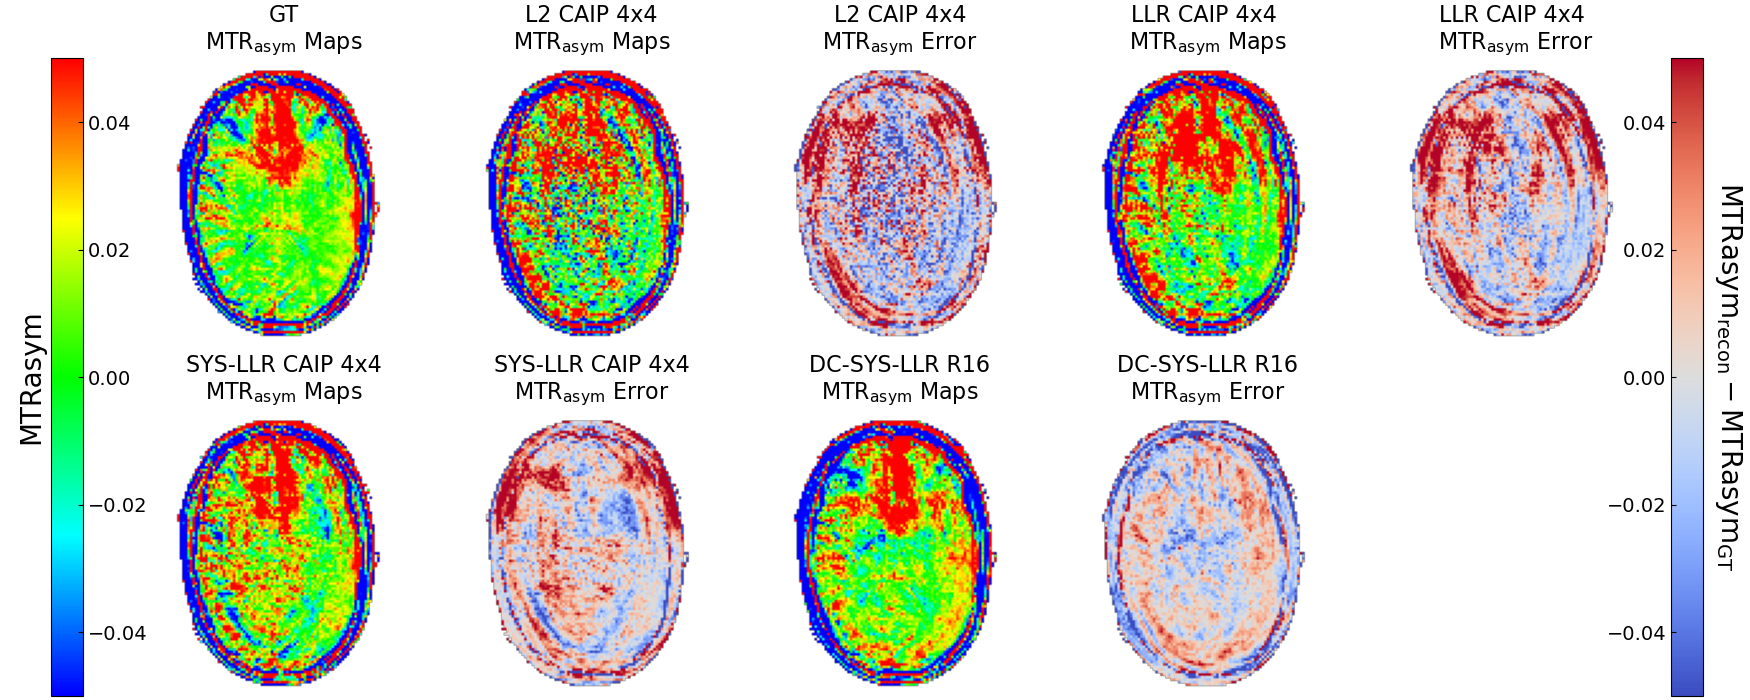

In [11]:
#+APTw Retro
# APTw MTRasym maps using the CEST++ asymmetry measure, not an error map.
# Run the Retrospective (all methods selection) cell first, load volumes, then run this cell.

aptw_vlim = (-0.05, 0.05)
aptw_diff_vlim = (-0.05, 0.05)


def aptw_display_image(img):
    if 'metric_display_image' in globals():
        return metric_display_image(img)
    rotate_widget = globals().get('metric_rotate_roi_heatmaps')
    rotate = True if rotate_widget is None else bool(rotate_widget.value)
    return np.rot90(np.asarray(img), k=-1) if rotate else np.asarray(img)


def aptw_idl_rainbow_cmap():
    return mcolors.LinearSegmentedColormap.from_list(
        'aptw_idl_rainbow',
        ['#0000ff', '#00ffff', '#00ff00', '#ffff00', '#ff0000'],
        N=256,
    )


def aptw_mtr_asym_value(z_norm, ppm):
    """CEST++-style APTw asymmetry: S0-normalized Z(-ppm) - Z(+ppm)."""
    pos_idx = np.where(np.isclose(offsets_ppm, ppm))[0]
    neg_idx = np.where(np.isclose(offsets_ppm, -ppm))[0]
    if pos_idx.size == 0 or neg_idx.size == 0:
        return np.nan
    z_pos = z_norm[pos_idx[0]]
    z_neg = z_norm[neg_idx[0]]
    if not np.isfinite(z_pos) or not np.isfinite(z_neg):
        return np.nan
    return z_neg - z_pos 
    # return (z_neg - z_pos) / z_neg



def compute_aptw_mtr_asym_map(vols, label, slice_idx, mask, ppm):
    _, _, ydim, xdim = vols[label].shape
    aptw_map = np.full((ydim, xdim), np.nan, dtype=np.float64)
    for iy, ix in np.argwhere(mask):
        z = normalize_by_s0(vols[label][:, slice_idx, iy, ix])
        aptw_map[iy, ix] = aptw_mtr_asym_value(z, ppm)
    return aptw_map


def selected_aptw_labels(vols):
    labels = []
    if 'metric_curve_checkboxes' in globals() and metric_curve_checkboxes:
        labels = [label for label, checkbox in metric_curve_checkboxes.items() if checkbox.value and label in vols]
    if not labels:
        labels = ['GT'] if 'GT' in vols else list(vols.keys())[:1]
    return labels


def plot_aptw_mtr_asym_maps():
    if 'metric_loaded_vols' not in globals() or metric_loaded_vols is None:
        print('Load volumes in the Retrospective (all methods selection) cell first, then rerun +APTw.')
        return

    vols = metric_loaded_vols
    labels = selected_aptw_labels(vols)
    slice_idx = metric_slice.value if 'metric_slice' in globals() else 0
    frac = metric_mask_frac.value if 'metric_mask_frac' in globals() else 0.05
    ppm = nearest_positive_ppm(metric_mtr_ppm.value) if 'metric_mtr_ppm' in globals() else nearest_positive_ppm(3.5)

    mask_methods = [label for label in labels if label != 'GT']
    shared_mask = global_shared_mask_volume(vols, mask_methods, frac=frac)[slice_idx]

    aptw_maps = {
        label: compute_aptw_mtr_asym_map(vols, label, slice_idx, shared_mask, ppm)
        for label in labels
    }

    if 'GT' not in vols:
        print('Skipping APTw difference maps: GT volume is not loaded.')
    elif 'GT' not in aptw_maps:
        aptw_maps['GT'] = compute_aptw_mtr_asym_map(vols, 'GT', slice_idx, shared_mask, ppm)

    cmap = aptw_idl_rainbow_cmap()
    plot_items = []
    for label in labels:
        plot_items.append({
            'title': f'{label}\n' + r'$\mathrm{MTR}_{\mathrm{asym}}$ Maps',
            'kind': 'map',
            'image': aptw_maps[label],
            'cmap': cmap,
            'vmin': aptw_vlim[0],
            'vmax': aptw_vlim[1],
            'cbar_label': 'MTRasym',
        })
        if label != 'GT' and 'GT' in aptw_maps:
            plot_items.append({
                'title': f'{label}\n' + r'$\mathrm{MTR}_{\mathrm{asym}}$ Error',
                'kind': 'error',
                'image': aptw_maps[label] - aptw_maps['GT'],
                'cmap': 'coolwarm',
                'vmin': aptw_diff_vlim[0],
                'vmax': aptw_diff_vlim[1],
                'cbar_label': 'Delta MTRasym',
            })

    cols = 5
    rows = int(np.ceil(len(plot_items) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(3.5 * cols, 3.5 * rows), squeeze=False, constrained_layout=True)
    for ax in axes.ravel():
        ax.axis('off')

    map_axes = []
    map_im = None
    error_axes = []
    error_im = None
    for idx, item in enumerate(plot_items):
        row = idx // cols
        col = idx % cols
        ax = axes[row, col]
        im = ax.imshow(
            aptw_display_image(item['image']),
            cmap=item['cmap'],
            origin='lower',
            vmin=item['vmin'],
            vmax=item['vmax'],
        )
        ax.set_title(item['title'], fontsize=title_fontsize)
        ax.tick_params(axis='both', labelsize=axes_label_fontsize)
        if item['kind'] == 'map':
            map_axes.append(ax)
            map_im = im
        else:
            error_axes.append(ax)
            error_im = im

    if map_im is not None:
        cbar_map = fig.colorbar(map_im, ax=axes.ravel().tolist(), location='left', fraction=0.25, pad=-0.02)
        cbar_map.set_label('MTRasym', fontsize=20)
        cbar_map.ax.yaxis.set_label_position('left')
        cbar_map.ax.yaxis.tick_right()
        cbar_map.ax.tick_params(labelsize=axes_label_fontsize, direction='in')

    if error_im is not None:
        cbar_error = fig.colorbar(error_im, ax=axes.ravel().tolist(), location='right', fraction=0.025, pad=-0.02)
        cbar_error.set_label(
            r'$\mathrm{MTRasym}_{\mathrm{recon}} - \mathrm{MTRasym}_{\mathrm{GT}}$', fontsize=20, rotation=270, labelpad=30,
        )
        cbar_error.ax.yaxis.set_label_position('right')
        cbar_error.ax.yaxis.tick_left()
        cbar_error.ax.tick_params(labelsize=axes_label_fontsize, direction='in')

    plt.show()


plot_aptw_mtr_asym_maps()


In [ ]:
# Retrospective (DC-SYS-LLR Finetuning)
# Optional CAIP 3x2 variables are included if defined before running this cell.
#+APTw
%matplotlib widget
import os
import builtins
from dataclasses import dataclass
from typing import Literal
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.widgets import RectangleSelector
import ipywidgets as widgets
from IPython.display import display
from skimage.metrics import structural_similarity as ssim


# -------------------------------------------------------------------------
# Settings
# -------------------------------------------------------------------------
s0_idx = 0
roi_display_offset_idx = 1  # display-only ROI selector offset; S0 normalization still uses s0_idx
sweep_step=0.25
offsets_ppm = np.concatenate(([-300.0], np.arange(-4, 4.1, sweep_step))) #offsets = 34
sweep_idx = np.arange(1, len(offsets_ppm))

# Figure font sizes. Change these three values to control all figures in this cell.
title_fontsize = 16
legend_fontsize = 12
axes_label_fontsize = 14

# Image-level metric normalization modes.
# minmax/robust_minmax/zscore estimate their parameters from each offset volume itself
# under the shared support mask, not from the reference peak.
# CEST spectral metrics remain S0-normalized through s0_idx, independent of this setting.
image_metric_norm_options = ['robust_minmax', 'minmax', 'zscore', 'ref_peak', 'none']
psnr_normalization_mode = image_metric_norm_options[0]
ssim_normalization_mode = image_metric_norm_options[2]
minmax_robust_percentiles = (0.005, 0.995)

for _mode_name, _mode_value in {
    'psnr_normalization_mode': psnr_normalization_mode,
    'ssim_normalization_mode': ssim_normalization_mode,
}.items():
    if _mode_value not in image_metric_norm_options:
        raise ValueError(f'{_mode_name}={_mode_value!r} must be one of {image_metric_norm_options}.')

# If shapes differ, all volumes are cropped to the common [offset, slice, y, x]
# extent using indices 0:min_dim, matching your RO_0_114 convention.
metric_crop_to_common_shape = True

# Self-contained H5 loading. By default, load the configured full H5 datasets.
# Set metric_prefer_existing_variables=True only when the in-memory volume_* variables
# are known to contain the full offset series.
metric_prefer_existing_variables = False
metric_data_dir = '/home/vault/iwbi/iwbi112h/CEST_DATA_06052026/'
metric_h5_dataset = 'imgs'
metric_saggital = False
metric_ro_range = range(0, 114)

regs=['0.05','0.03','0.01','0.009','0.007','0.005']
blks=['1x1','3x3','5x5','7x7','9x9','11x11','13x13','15x15'] #LLR Block size list


# Spec-driven method discovery. Add future methods by adding one ReconSpec.
@dataclass(frozen=True)
class ReconSpec:
    label: str
    files: tuple[str, ...]
    color: str | None = None
    variable: str | None = None
    loader: Literal['imgs_dataset', 'ro_keys', 'split_ro_keys'] = 'imgs_dataset'
    required: bool = False


metric_ref_spec = ReconSpec(
    label='GT',
    variable='GT',
    files=('CEST_GRAPPA3_3Shot/kdat_3D_R34_C52_3Shot_imgs.h5',),
    loader='imgs_dataset',
    color='red',
    required=True,
)

metric_recon_specs = [

    
    ReconSpec(
        label=f' Lambda {regs[0]}',
        files=    
        (f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_1of2_Reps_0_17_RO_0_114_1x{blks[2]}_r_{regs[0]}_i_30_R34_C52_3Shot_us_CAIP_5x4_sym_yshift_True_dc_16_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
        f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_2of2_Reps_17_34_RO_0_114_1x{blks[2]}_r_{regs[0]}_i_30_R34_C52_3Shot_us_CAIP_5x4_sym_yshift_True_dc_16_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',),
        loader='split_ro_keys',
    
    ),
    
    ReconSpec(
        label=f' Lambda {regs[1]}',
        files=    
        (f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_1of2_Reps_0_17_RO_0_114_1x{blks[2]}_r_{regs[1]}_i_30_R34_C52_3Shot_us_CAIP_5x4_sym_yshift_True_dc_16_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
        f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_2of2_Reps_17_34_RO_0_114_1x{blks[2]}_r_{regs[1]}_i_30_R34_C52_3Shot_us_CAIP_5x4_sym_yshift_True_dc_16_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',),
        loader='split_ro_keys',
    
    ),
    
    ReconSpec(
        label=f' Lambda {regs[2]}',
        files=    
        (f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_1of2_Reps_0_17_RO_0_114_1x{blks[2]}_r_{regs[2]}_i_30_R34_C52_3Shot_us_CAIP_5x4_sym_yshift_True_dc_16_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
        f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_2of2_Reps_17_34_RO_0_114_1x{blks[2]}_r_{regs[2]}_i_30_R34_C52_3Shot_us_CAIP_5x4_sym_yshift_True_dc_16_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',),
        loader='split_ro_keys',

    ),
 

    
    ReconSpec(
        label=f' Lambda {regs[3]}',
        files=    
        (f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_1of2_Reps_0_17_RO_0_114_1x{blks[2]}_r_{regs[3]}_i_30_R34_C52_3Shot_us_CAIP_5x4_sym_yshift_True_dc_16_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
        f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_2of2_Reps_17_34_RO_0_114_1x{blks[2]}_r_{regs[3]}_i_30_R34_C52_3Shot_us_CAIP_5x4_sym_yshift_True_dc_16_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',),
        loader='split_ro_keys',
    
    ),
    
    ReconSpec(
        label=f' Lambda {regs[4]}',
        files=    
        (f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_1of2_Reps_0_17_RO_0_114_1x{blks[2]}_r_{regs[4]}_i_30_R34_C52_3Shot_us_CAIP_5x4_sym_yshift_True_dc_16_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
        f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_2of2_Reps_17_34_RO_0_114_1x{blks[2]}_r_{regs[4]}_i_30_R34_C52_3Shot_us_CAIP_5x4_sym_yshift_True_dc_16_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',),
        loader='split_ro_keys',
    
    ),
    
    ReconSpec(
        label=f' Block-Size {blks[0]}',
        files=    
        (f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_1of2_Reps_0_17_RO_0_114_1x{blks[0]}_r_{regs[2]}_i_30_R34_C52_3Shot_us_CAIP_5x4_sym_yshift_True_dc_16_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
        f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_2of2_Reps_17_34_RO_0_114_1x{blks[0]}_r_{regs[2]}_i_30_R34_C52_3Shot_us_CAIP_5x4_sym_yshift_True_dc_16_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',),
        loader='split_ro_keys',
      ),
  
    ReconSpec(
        label=f' Block-Size {blks[1]}',
        files=    
        (f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_1of2_Reps_0_17_RO_0_114_1x{blks[1]}_r_{regs[2]}_i_30_R34_C52_3Shot_us_CAIP_5x4_sym_yshift_True_dc_16_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
        f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_2of2_Reps_17_34_RO_0_114_1x{blks[1]}_r_{regs[2]}_i_30_R34_C52_3Shot_us_CAIP_5x4_sym_yshift_True_dc_16_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',),
        loader='split_ro_keys',
     ),

    ReconSpec(
        label=f' Block-Size {blks[2]}',
        files=    
        (f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_1of2_Reps_0_17_RO_0_114_1x{blks[2]}_r_{regs[2]}_i_30_R34_C52_3Shot_us_CAIP_5x4_sym_yshift_True_dc_16_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
        f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_2of2_Reps_17_34_RO_0_114_1x{blks[2]}_r_{regs[2]}_i_30_R34_C52_3Shot_us_CAIP_5x4_sym_yshift_True_dc_16_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',),
        loader='split_ro_keys',
    ),

    ReconSpec(
        label=f' Block-Size {blks[3]}',
        files=    
        (f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_1of2_Reps_0_17_RO_0_114_1x{blks[3]}_r_{regs[2]}_i_30_R34_C52_3Shot_us_CAIP_5x4_sym_yshift_True_dc_16_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
        f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_2of2_Reps_17_34_RO_0_114_1x{blks[3]}_r_{regs[2]}_i_30_R34_C52_3Shot_us_CAIP_5x4_sym_yshift_True_dc_16_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',),
        loader='split_ro_keys',
    
    ),
    ReconSpec(
        label=f' Block-Size {blks[4]}',
        files=    
        (f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_1of2_Reps_0_17_RO_0_114_1x{blks[4]}_r_{regs[2]}_i_30_R34_C52_3Shot_us_CAIP_5x4_sym_yshift_True_dc_16_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
        f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_2of2_Reps_17_34_RO_0_114_1x{blks[4]}_r_{regs[2]}_i_30_R34_C52_3Shot_us_CAIP_5x4_sym_yshift_True_dc_16_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',),
        loader='split_ro_keys',
    
    ),
    ReconSpec(
        label=f' Block-Size {blks[5]}',
        files=    
        (f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_1of2_Reps_0_17_RO_0_114_1x{blks[5]}_r_{regs[2]}_i_30_R34_C52_3Shot_us_CAIP_5x4_sym_yshift_True_dc_16_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
        f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_2of2_Reps_17_34_RO_0_114_1x{blks[5]}_r_{regs[2]}_i_30_R34_C52_3Shot_us_CAIP_5x4_sym_yshift_True_dc_16_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',),
        loader='split_ro_keys',
    
    ),
    ReconSpec(
        label=f' Block-Size {blks[6]}',
        files=    
        (f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_1of2_Reps_0_17_RO_0_114_1x{blks[6]}_r_{regs[2]}_i_30_R34_C52_3Shot_us_CAIP_5x4_sym_yshift_True_dc_16_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
        f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_2of2_Reps_17_34_RO_0_114_1x{blks[6]}_r_{regs[2]}_i_30_R34_C52_3Shot_us_CAIP_5x4_sym_yshift_True_dc_16_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',),
        loader='split_ro_keys',
    
    ),
    ReconSpec(
        label=f' Block-Size {blks[7]}',
        files=    
        (f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_1of2_Reps_0_17_RO_0_114_1x{blks[7]}_r_{regs[2]}_i_30_R34_C52_3Shot_us_CAIP_5x4_sym_yshift_True_dc_16_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
        f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_2of2_Reps_17_34_RO_0_114_1x{blks[7]}_r_{regs[2]}_i_30_R34_C52_3Shot_us_CAIP_5x4_sym_yshift_True_dc_16_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',),
        loader='split_ro_keys',
    
    ),
        

]

metric_all_specs = [metric_ref_spec] + metric_recon_specs
method_colors = {}
for spec in metric_all_specs:
    color = getattr(spec, 'color', None)
    if color is None:
        continue
    try:
        color_ok = mcolors.is_color_like(color)
    except (TypeError, ValueError):
        color_ok = False
    if color_ok:
        method_colors[spec.label] = color

def color_key(color):
    try:
        return mcolors.to_rgba(color)
    except (TypeError, ValueError):
        return None

def related_color_keys(color):
    key = color_key(color)
    keys = {key} if key is not None else set()
    red_keys = {color_key(c) for c in ('red', 'r', 'tab:red', 'C3', '#d62728')}
    red_keys.discard(None)
    if key in red_keys:
        keys.update(red_keys)
    return keys

def color_luminance(color):
    rgba = color_key(color)
    if rgba is None:
        return np.nan
    r, g, b = rgba[:3]
    return 0.2126 * r + 0.7152 * g + 0.0722 * b


def color_saturation(color):
    rgba = color_key(color)
    if rgba is None:
        return np.nan
    r, g, b = rgba[:3]
    return max(r, g, b) - min(r, g, b)


def is_near_reference_red(color):
    rgba = color_key(color)
    if rgba is None:
        return False
    hue, sat, _ = mcolors.rgb_to_hsv(np.asarray(rgba[:3]))
    red_distance = min(hue, 1.0 - hue)
    return sat >= 0.25 and red_distance <= 0.08


def is_medium_dark_color(color):
    lum = color_luminance(color)
    sat = color_saturation(color)
    return (
        np.isfinite(lum)
        and np.isfinite(sat)
        and 0.12 <= lum <= 0.62
        and sat >= 0.18
        and not is_near_reference_red(color)
    )


def color_distance(color_a, color_b):
    rgba_a = color_key(color_a)
    rgba_b = color_key(color_b)
    if rgba_a is None or rgba_b is None:
        return 0.0
    rgb_a = np.asarray(rgba_a[:3], dtype=np.float64)
    rgb_b = np.asarray(rgba_b[:3], dtype=np.float64)
    hsv_a = mcolors.rgb_to_hsv(rgb_a)
    hsv_b = mcolors.rgb_to_hsv(rgb_b)
    hue_distance = min(abs(hsv_a[0] - hsv_b[0]), 1.0 - abs(hsv_a[0] - hsv_b[0]))
    rgb_distance = np.linalg.norm(rgb_a - rgb_b)
    sv_distance = np.linalg.norm(hsv_a[1:] - hsv_b[1:])
    return float(rgb_distance + 0.8 * hue_distance + 0.25 * sv_distance)


def min_color_distance(color, existing_colors):
    if not existing_colors:
        return np.inf
    return min(color_distance(color, existing) for existing in existing_colors)


def choose_distinct_color(candidates, existing_colors, used_color_keys, min_distance=0.42):
    best = None
    best_distance = -np.inf
    for candidate in candidates:
        key = color_key(candidate)
        if key is None or key in used_color_keys:
            continue
        distance = min_color_distance(candidate, existing_colors)
        if distance > best_distance:
            best = candidate
            best_distance = distance
    if best is not None and best_distance >= min_distance:
        return best
    return best


metric_auto_palette_raw = (
    list(plt.get_cmap('tab10').colors)
    + list(plt.get_cmap('Dark2').colors)
    + list(plt.get_cmap('Set1').colors)
    + list(plt.get_cmap('Paired').colors)
    + list(plt.get_cmap('tab20b').colors)
    + list(plt.get_cmap('tab20').colors)
    + list(plt.get_cmap('tab20c').colors)
)
metric_auto_palette = [color for color in metric_auto_palette_raw if is_medium_dark_color(color)]
metric_used_color_keys = {
    key
    for color in method_colors.values()
    for key in related_color_keys(color)
}
for spec in metric_all_specs:
    if spec.label in method_colors:
        continue
    existing_colors = list(method_colors.values())
    assigned = choose_distinct_color(metric_auto_palette, existing_colors, metric_used_color_keys)
    if assigned is None:
        assigned = choose_distinct_color(metric_auto_palette_raw, existing_colors, metric_used_color_keys, min_distance=0.0)
    if assigned is None:
        assigned = f'C{len(method_colors)}'
    method_colors[spec.label] = assigned
    metric_used_color_keys.update(related_color_keys(assigned))


# -------------------------------------------------------------------------
# Helpers
# -------------------------------------------------------------------------
def mag(x):
    return np.abs(np.asarray(x))


def method_color(label):
    color = method_colors.get(label)
    if color is not None and mcolors.is_color_like(color):
        return color
    return 'C0'


def color_boxplot(bp, labels, alpha=0.25):
    for box, label in zip(bp['boxes'], labels):
        color = method_color(label)
        box.set_facecolor(color)
        box.set_alpha(alpha)
        box.set_edgecolor(color)
    for element in ['whiskers', 'caps', 'medians']:
        for item in bp[element]:
            item.set_color('0.25')


def normalize_by_s0(z):
    """Normalize one pixel Z-spectrum by its own S0 sample."""
    z = np.asarray(z, dtype=np.float64)
    s0 = z[s0_idx]
    if not np.isfinite(s0) or s0 == 0:
        return np.full_like(z, np.nan, dtype=np.float64)
    return z / s0


def relative_l2_nrmse(test_vec, ref_vec):
    valid = np.isfinite(test_vec) & np.isfinite(ref_vec)
    if not np.any(valid):
        return np.nan
    denom = np.sqrt(np.nanmean(ref_vec[valid] ** 2))
    if not np.isfinite(denom) or denom == 0:
        return np.nan
    return np.sqrt(np.nanmean((test_vec[valid] - ref_vec[valid]) ** 2)) / denom


def h5_path(file_name):
    return file_name if os.path.isabs(file_name) else os.path.join(metric_data_dir, file_name)


def load_imgs_dataset(file_name, dataset=metric_h5_dataset):
    path = h5_path(file_name)
    if not os.path.exists(path):
        raise FileNotFoundError(f'H5 file not found: {path}')
    with h5py.File(path, 'r') as f:
        vol = np.asarray(f[dataset])
    if metric_saggital:
        vol = np.transpose(vol, axes=[-4, -1, -2, -3])
    return abs(vol)


def load_ro_keys(file_name):
    path = h5_path(file_name)
    if not os.path.exists(path):
        raise FileNotFoundError(f'H5 file not found: {path}')
    with h5py.File(path, 'r') as f:
        ro_stack = np.asarray([f[f'CEST_recon_RO_idx_{ro_idx}'][:] for ro_idx in metric_ro_range])
    vol = np.transpose(ro_stack, (-3, -2, -1, -4))
    if metric_saggital:
        vol = np.transpose(vol, axes=[-4, -1, -2, -3])
    return abs(vol)


def load_spec_files(spec):
    if spec.loader == 'imgs_dataset':
        if len(spec.files) != 1:
            raise ValueError(f'{spec.label}: imgs_dataset loader expects exactly one file.')
        return load_imgs_dataset(spec.files[0])
    if spec.loader == 'ro_keys':
        if len(spec.files) != 1:
            raise ValueError(f'{spec.label}: ro_keys loader expects exactly one file.')
        return load_ro_keys(spec.files[0])
    if spec.loader == 'split_ro_keys':
        if not spec.files:
            raise ValueError(f'{spec.label}: split_ro_keys loader needs at least one file.')
        return np.concatenate([load_ro_keys(file_name) for file_name in spec.files], axis=0)
    raise ValueError(f'{spec.label}: unknown loader {spec.loader!r}')


def get_volume(spec):
    if metric_prefer_existing_variables and spec.variable and spec.variable in globals():
        vol = np.asarray(globals()[spec.variable])
        if vol.shape[0] == len(offsets_ppm):
            return vol, f'variable {spec.variable}'
        if spec.files:
            print(
                f'{spec.label}: ignoring variable {spec.variable} with {vol.shape[0]} offsets; '
                f'loading configured full dataset with {len(offsets_ppm)} offsets.'
            )
        elif spec.required:
            raise ValueError(
                f'{spec.label}: variable {spec.variable} has {vol.shape[0]} offsets, '
                f'but offsets_ppm has {len(offsets_ppm)} and no files are configured.'
            )
        else:
            return None, None

    if spec.files:
        return load_spec_files(spec), f'{spec.loader} {spec.files}'
    if spec.required:
        raise NameError(f'Missing required {spec.label}; define {spec.variable!r} or set spec.files.')
    return None, None


def collect_volumes():
    ref_vol, ref_source = get_volume(metric_ref_spec)
    vols = {metric_ref_spec.label: ref_vol}
    sources = {metric_ref_spec.label: ref_source}
    skipped = []

    for spec in metric_recon_specs:
        vol, source = get_volume(spec)
        if vol is None:
            skipped.append(f'{spec.label}: define {spec.variable!r} or set files in metric_recon_specs')
            continue
        vols[spec.label] = vol
        sources[spec.label] = source

    if len(vols) == 1:
        raise NameError(
            'No reconstruction method volumes were found. Define method variables or H5 names. '
            f'Skipped: {skipped}'
        )

    print('Loaded comparison Cart volumes:')
    for label, source in sources.items():
        print(f'  {label}: {source}, shape={vols[label].shape}')
    if skipped:
        print('Skipped optional methods:')
        for item in skipped:
            print(' ', item)

    shapes = {label: vol.shape for label, vol in vols.items()}
    if len(set(shapes.values())) != 1:
        if not metric_crop_to_common_shape:
            raise ValueError(f'Volume shapes differ: {shapes}')
        common = tuple(min(shape[dim] for shape in shapes.values()) for dim in builtins.range(4))
        vols = {label: vol[:common[0], :common[1], :common[2], :common[3]] for label, vol in vols.items()}
        print('Cropped to common shape:', common)
        print('Original shapes:', shapes)

    for label, vol in vols.items():
        if vol.shape[0] != len(offsets_ppm):
            raise ValueError(
                f'{label} has {vol.shape[0]} offsets, but offsets_ppm has {len(offsets_ppm)}. '
                'Adjust offsets_ppm or the loaded volume.'
            )
    return vols


def global_shared_mask_volume(vols, methods, frac=0.05):
    """One 3D shared S0 support mask for GT and every displayed method.

    This mask is used for S0-normalized CEST metrics, ROI selection, and
    heatmaps. Image-level PSNR/SSIM use offset-specific volume masks below.
    """
    ref_s0 = mag(vols['GT'][s0_idx])
    mask = np.zeros_like(ref_s0, dtype=bool)

    for z in builtins.range(ref_s0.shape[0]):
        ref_slice = ref_s0[z]
        finite_ref = np.isfinite(ref_slice)
        thresh = frac * np.nanmax(ref_slice[finite_ref]) if np.any(finite_ref) else np.inf
        mask[z] = finite_ref & (ref_slice > thresh)

    for method in methods:
        test_s0 = mag(vols[method][s0_idx])
        mask &= np.isfinite(test_s0) & (test_s0 > 0)

    return mask


def global_shared_mask(vols, methods, slice_idx, frac=0.05):
    """2D slice view of the shared support mask used by ROI/heatmap metrics."""
    return global_shared_mask_volume(vols, methods, frac=frac)[slice_idx]

def offset_shared_mask_4d(vols, methods, frac=0.05):
    """Offset-specific shared support masks for image-level metrics.

    Returns a 4D mask [offset, slice, y, x]. For each offset, the support is
    shared across GT and every displayed method, but it is not reused across
    offsets. This lets offset-volume normalization use the relevant signal
    support of that offset volume instead of the S0 support for all offsets.
    """
    ref = mag(vols['GT'])
    masks = np.zeros_like(ref, dtype=bool)

    for off in builtins.range(ref.shape[0]):
        for z in builtins.range(ref.shape[1]):
            ref_slice = ref[off, z]
            finite_ref = np.isfinite(ref_slice)
            thresh = frac * np.nanmax(ref_slice[finite_ref]) if np.any(finite_ref) else np.inf
            masks[off, z] = finite_ref & (ref_slice > thresh)

        for method in methods:
            test_off = mag(vols[method][off])
            masks[off] &= np.isfinite(test_off) & (test_off > 0)

    return masks


def compute_z_nrmse_map(vols, method, slice_idx, mask):
    _, _, ydim, xdim = vols['GT'].shape
    nrmse_map = np.full((ydim, xdim), np.nan, dtype=np.float64)

    for iy, ix in np.argwhere(mask):
        zref = normalize_by_s0(vols['GT'][:, slice_idx, iy, ix])
        ztest = normalize_by_s0(vols[method][:, slice_idx, iy, ix])
        nrmse_map[iy, ix] = relative_l2_nrmse(ztest[sweep_idx], zref[sweep_idx])
    return nrmse_map

def nearest_positive_ppm(ppm):
    positive = offsets_ppm[offsets_ppm > 0]
    if positive.size == 0:
        raise ValueError('offsets_ppm must include positive offsets for MTRasym.')
    return float(positive[np.argmin(np.abs(positive - ppm))])


def mtr_asym_value(z_norm, ppm):
    pos_idx = np.where(np.isclose(offsets_ppm, ppm))[0]
    neg_idx = np.where(np.isclose(offsets_ppm, -ppm))[0]
    if pos_idx.size == 0 or neg_idx.size == 0:
        return np.nan
    z_pos = z_norm[pos_idx[0]]
    z_neg = z_norm[neg_idx[0]]
    if not np.isfinite(z_pos) or not np.isfinite(z_neg) or z_neg == 0:
        return np.nan
    
      ############
    #    Normalized MTRasym
      ############
    
    # return (z_neg - z_pos) / z_neg

      ############
    #   Non-Normalized MTRasym
      ############
    
    return (z_neg - z_pos)





def _finite_1d(values):
    values = np.asarray(values, dtype=np.float64).ravel()
    return values[np.isfinite(values)]


def normalize_offset_volume_pair(
    ref_vol,
    test_vol,
    norm_mask_3d,
    mode=None,
    ref_s0_vol=None,
    test_s0_vol=None,
    robust_quantiles=None,
    eps=1e-8,
):
    """Normalize one GT/test offset volume pair for image-level metrics.

    Inputs are 3D volumes for a single offset: [slice, y, x]. The scaling
    parameters are estimated from the whole offset volume inside norm_mask_3d,
    then the selected slice is extracted later for PSNR/SSIM.

    Modes:
    - robust_minmax: each offset volume independently scaled by valid-mask quantiles.
    - minmax: each offset volume independently min-max scaled inside valid mask.
    - zscore: each offset volume independently zero-mean/std scaled inside valid mask.
    - ref_peak: both offset volumes divided by the GT peak inside valid mask.
    - none: raw magnitude values.
    """
    if mode is None:
        raise ValueError('normalize_offset_volume_pair requires an explicit mode.')
    robust_quantiles = minmax_robust_percentiles if robust_quantiles is None else robust_quantiles

    ref_vol = np.asarray(ref_vol, dtype=np.float64)
    test_vol = np.asarray(test_vol, dtype=np.float64)
    norm_mask_3d = np.asarray(norm_mask_3d, dtype=bool)
    valid = norm_mask_3d & np.isfinite(ref_vol) & np.isfinite(test_vol)

    if mode == 's0':
        if ref_s0_vol is None or test_s0_vol is None:
            raise ValueError('s0 normalization requires ref_s0_vol and test_s0_vol.')
        ref_s0_vol = np.asarray(ref_s0_vol, dtype=np.float64)
        test_s0_vol = np.asarray(test_s0_vol, dtype=np.float64)
        valid = valid & np.isfinite(ref_s0_vol) & np.isfinite(test_s0_vol) & (ref_s0_vol != 0) & (test_s0_vol != 0)

    if np.count_nonzero(valid) < 3:
        return ref_vol, test_vol, np.nan, valid

    ref_vals = _finite_1d(ref_vol[valid])
    test_vals = _finite_1d(test_vol[valid])
    if mode in {'ref_peak', 'minmax', 'robust_minmax', 'zscore'}:
        if ref_vals.size == 0 or test_vals.size == 0:
            return ref_vol, test_vol, np.nan, valid

    nominal_range = None

    if mode == 'none':
        ref_n = ref_vol
        test_n = test_vol

    elif mode == 'ref_peak':
        scale = np.nanmax(ref_vals)
        if not np.isfinite(scale) or scale <= eps:
            return ref_vol, test_vol, np.nan, valid
        ref_n = ref_vol / scale
        test_n = test_vol / scale
        nominal_range = 1.0

    elif mode == 'minmax':
        ref_min, ref_max = np.nanmin(ref_vals), np.nanmax(ref_vals)
        test_min, test_max = np.nanmin(test_vals), np.nanmax(test_vals)
        ref_range = ref_max - ref_min
        test_range = test_max - test_min
        if not np.isfinite(ref_range) or ref_range <= eps or not np.isfinite(test_range) or test_range <= eps:
            return ref_vol, test_vol, np.nan, valid
        ref_n = (ref_vol - ref_min) / ref_range
        test_n = (test_vol - test_min) / test_range
        nominal_range = 1.0

    elif mode == 'robust_minmax':
        q_low, q_high = robust_quantiles
        ref_min, ref_max = np.nanquantile(ref_vals, [q_low, q_high])
        test_min, test_max = np.nanquantile(test_vals, [q_low, q_high])
        ref_range = ref_max - ref_min
        test_range = test_max - test_min
        if not np.isfinite(ref_range) or ref_range <= eps or not np.isfinite(test_range) or test_range <= eps:
            return ref_vol, test_vol, np.nan, valid
        ref_n = (ref_vol - ref_min) / ref_range
        test_n = (test_vol - test_min) / test_range
        nominal_range = 1.0

    elif mode == 'zscore':
        ref_std = np.nanstd(ref_vals)
        test_std = np.nanstd(test_vals)
        if not np.isfinite(ref_std) or ref_std <= eps or not np.isfinite(test_std) or test_std <= eps:
            return ref_vol, test_vol, np.nan, valid
        ref_n = (ref_vol - np.nanmean(ref_vals)) / ref_std
        test_n = (test_vol - np.nanmean(test_vals)) / test_std


    else:
        raise ValueError(f'Unknown image metric normalization mode: {mode}')

    if nominal_range is not None:
        data_range = nominal_range
    else:
        ref_metric_vals = _finite_1d(ref_n[valid])
        data_range = np.nanmax(ref_metric_vals) - np.nanmin(ref_metric_vals) if ref_metric_vals.size else np.nan

    if not np.isfinite(data_range) or data_range <= 0:
        data_range = np.nan
    return ref_n, test_n, data_range, valid

def image_metric_crop(mask):
    """Bounding box used by image-level SSIM while preserving 2D geometry."""
    ys, xs = np.where(mask)
    if ys.size == 0:
        return None
    return ys.min(), ys.max() + 1, xs.min(), xs.max() + 1




def compute_image_metrics_per_offset(vols, method, slice_idx, image_mask_4d=None):
    """Compute PSNR and SSIM after explicit whole-offset-volume normalizations.

    PSNR uses psnr_normalization_mode. SSIM uses ssim_normalization_mode.
    Each offset first gets its own shared 3D support mask [slice, y, x], then
    the full offset volumes are normalized and the selected slice is evaluated.
    """
    ref = mag(vols['GT'])
    test = mag(vols[method])
    n_offsets = ref.shape[0]
    psnr = np.full(n_offsets, np.nan, dtype=np.float64)
    mse = np.full(n_offsets, np.nan, dtype=np.float64)
    psnr_ranges = np.full(n_offsets, np.nan, dtype=np.float64)
    ssim_scores = np.full(n_offsets, np.nan, dtype=np.float64)
    ssim_ranges = np.full(n_offsets, np.nan, dtype=np.float64)

    if image_mask_4d is None:
        image_mask_4d = np.isfinite(ref) & np.isfinite(test) & (ref > 0) & (test > 0)

    ref_s0_vol = ref[s0_idx]
    test_s0_vol = test[s0_idx]
    for i in builtins.range(n_offsets):
        norm_mask_3d = image_mask_4d[i]

        ref_psnr_vol, test_psnr_vol, psnr_ranges[i], valid_psnr_vol = normalize_offset_volume_pair(
            ref[i],
            test[i],
            norm_mask_3d,
            mode=psnr_normalization_mode,
            ref_s0_vol=ref_s0_vol,
            test_s0_vol=test_s0_vol,
        )
        if np.isfinite(psnr_ranges[i]):
            ref_img = ref_psnr_vol[slice_idx]
            test_img = test_psnr_vol[slice_idx]
            valid = valid_psnr_vol[slice_idx] & np.isfinite(ref_img) & np.isfinite(test_img)
            if np.any(valid):
                mse[i] = np.nanmean((ref_img[valid] - test_img[valid]) ** 2)
                if mse[i] > 0:
                    psnr[i] = 10.0 * np.log10((psnr_ranges[i] ** 2) / mse[i])

        ref_ssim_vol, test_ssim_vol, ssim_ranges[i], valid_ssim_vol = normalize_offset_volume_pair(
            ref[i],
            test[i],
            norm_mask_3d,
            mode=ssim_normalization_mode,
            ref_s0_vol=ref_s0_vol,
            test_s0_vol=test_s0_vol,
        )
        if np.isfinite(ssim_ranges[i]):
            ref_img = ref_ssim_vol[slice_idx]
            test_img = test_ssim_vol[slice_idx]
            valid = valid_ssim_vol[slice_idx] & np.isfinite(ref_img) & np.isfinite(test_img)
            if np.count_nonzero(valid) >= 3:
                try:
                    ssim_scores[i] = float(
                        ssim(
                            ref_img[valid],
                            test_img[valid],
                            win_size=3,
                            data_range=ssim_ranges[i],
                            gaussian_weights=False,
                        )
                    )
                except ValueError:
                    ssim_scores[i] = np.nan

    return psnr, mse, psnr_ranges, ssim_scores, ssim_ranges


def compute_mtr_asym_delta_map(vols, method, slice_idx, mask, ppm):
    _, _, ydim, xdim = vols['GT'].shape
    delta_map = np.full((ydim, xdim), np.nan, dtype=np.float64)
    for iy, ix in np.argwhere(mask):
        zref = normalize_by_s0(vols['GT'][:, slice_idx, iy, ix])
        ztest = normalize_by_s0(vols[method][:, slice_idx, iy, ix])
        m_ref = mtr_asym_value(zref, ppm)
        m_test = mtr_asym_value(ztest, ppm)
        if np.isfinite(m_ref) and np.isfinite(m_test):
            delta_map[iy, ix] = m_test - m_ref
    return delta_map


def volume_diagnostic_slices(zdim, drop_first=2, drop_last=4):
    start = int(drop_first)
    stop = int(zdim) - int(drop_last)
    if stop <= start:
        return np.arange(int(zdim), dtype=int)
    return np.arange(start, stop, dtype=int)


def compute_volume_image_metrics_per_offset(vols, method, image_mask_4d, eval_slices):
    ref = mag(vols['GT'])
    test = mag(vols[method])
    n_offsets, zdim = ref.shape[:2]
    psnr = np.full(n_offsets, np.nan, dtype=np.float64)
    mse = np.full(n_offsets, np.nan, dtype=np.float64)
    ssim_scores = np.full(n_offsets, np.nan, dtype=np.float64)
    slice_keep = np.zeros(zdim, dtype=bool)
    slice_keep[np.asarray(eval_slices, dtype=int)] = True
    slice_keep_3d = slice_keep[:, None, None]
    ref_s0_vol = ref[s0_idx]
    test_s0_vol = test[s0_idx]

    for i in builtins.range(n_offsets):
        norm_mask_3d = image_mask_4d[i] & slice_keep_3d
        ref_psnr_vol, test_psnr_vol, psnr_range, valid_psnr_vol = normalize_offset_volume_pair(
            ref[i],
            test[i],
            norm_mask_3d,
            mode=psnr_normalization_mode,
            ref_s0_vol=ref_s0_vol,
            test_s0_vol=test_s0_vol,
        )
        valid = valid_psnr_vol & slice_keep_3d & np.isfinite(ref_psnr_vol) & np.isfinite(test_psnr_vol)
        if np.isfinite(psnr_range) and np.any(valid):
            mse[i] = np.nanmean((ref_psnr_vol[valid] - test_psnr_vol[valid]) ** 2)
            if mse[i] > 0:
                psnr[i] = 10.0 * np.log10((psnr_range ** 2) / mse[i])

        ref_ssim_vol, test_ssim_vol, ssim_range, valid_ssim_vol = normalize_offset_volume_pair(
            ref[i],
            test[i],
            norm_mask_3d,
            mode=ssim_normalization_mode,
            ref_s0_vol=ref_s0_vol,
            test_s0_vol=test_s0_vol,
        )
        if np.isfinite(ssim_range):
            slice_scores = []
            for z in eval_slices:
                ref_img = ref_ssim_vol[z]
                test_img = test_ssim_vol[z]
                valid = valid_ssim_vol[z] & np.isfinite(ref_img) & np.isfinite(test_img)
                if np.count_nonzero(valid) >= 3:
                    try:
                        slice_scores.append(
                            float(
                                ssim(
                                    ref_img[valid],
                                    test_img[valid],
                                    win_size=3,
                                    data_range=ssim_range,
                                    gaussian_weights=False,
                                )
                            )
                        )
                    except ValueError:
                        pass
            if slice_scores:
                ssim_scores[i] = np.nanmean(slice_scores)

    return psnr, mse, ssim_scores


def compute_volume_diagnostics(vols, method, shared_mask_volume, image_mask_4d, mtr_eval_ppm, eval_slices):
    z_vals = []
    mtr_delta_vals = []
    for z in eval_slices:
        mask = shared_mask_volume[z]
        for iy, ix in np.argwhere(mask):
            zref = normalize_by_s0(vols['GT'][:, z, iy, ix])
            ztest = normalize_by_s0(vols[method][:, z, iy, ix])
            nrmse = relative_l2_nrmse(ztest[sweep_idx], zref[sweep_idx])
            if np.isfinite(nrmse):
                z_vals.append(nrmse)
            m_ref = mtr_asym_value(zref, mtr_eval_ppm)
            m_test = mtr_asym_value(ztest, mtr_eval_ppm)
            if np.isfinite(m_ref) and np.isfinite(m_test):
                mtr_delta_vals.append(m_test - m_ref)

    psnr, mse, ssim_vals = compute_volume_image_metrics_per_offset(vols, method, image_mask_4d, eval_slices)
    z_vals = np.asarray(z_vals, dtype=np.float64)
    mtr_delta_vals = np.asarray(mtr_delta_vals, dtype=np.float64)
    return {
        'slice_start': int(eval_slices[0]) if len(eval_slices) else None,
        'slice_stop': int(eval_slices[-1]) if len(eval_slices) else None,
        'slice_count': int(len(eval_slices)),
        'z_nrmse_mean': float(np.nanmean(z_vals)) if z_vals.size else np.nan,
        'z_nrmse_median': float(np.nanmedian(z_vals)) if z_vals.size else np.nan,
        'z_nrmse_count': int(np.isfinite(z_vals).sum()),
        'mse_offset_mean': float(np.nanmean(mse[sweep_idx])) if np.any(np.isfinite(mse[sweep_idx])) else np.nan,
        'psnr_offset_mean': float(np.nanmean(psnr[sweep_idx])) if np.any(np.isfinite(psnr[sweep_idx])) else np.nan,
        'ssim_offset_mean': float(np.nanmean(ssim_vals[sweep_idx])) if np.any(np.isfinite(ssim_vals[sweep_idx])) else np.nan,
        'mtr_abs_mean': float(np.nanmean(np.abs(mtr_delta_vals))) if mtr_delta_vals.size else np.nan,
        'mtr_abs_median': float(np.nanmedian(np.abs(mtr_delta_vals))) if mtr_delta_vals.size else np.nan,
        'mtr_count': int(np.isfinite(mtr_delta_vals).sum()),
        'mtr_ppm': float(mtr_eval_ppm),
    }


def bounds_to_roi(shape_yx, bounds):
    ydim, xdim = shape_yx
    if bounds is None:
        return np.ones((ydim, xdim), dtype=bool)
    x0, x1, y0, y1 = bounds
    x0, x1 = sorted((max(0, int(round(x0))), min(xdim - 1, int(round(x1)))))
    y0, y1 = sorted((max(0, int(round(y0))), min(ydim - 1, int(round(y1)))))
    roi = np.zeros((ydim, xdim), dtype=bool)
    roi[y0:y1 + 1, x0:x1 + 1] = True
    return roi



def roi_z_values(vols, labels, slice_idx, roi_mask):
    values = {}
    for label in labels:
        data = mag(vols[label][:, slice_idx])[:, roi_mask]
        with np.errstate(divide='ignore', invalid='ignore'):
            z = data / data[s0_idx:s0_idx + 1]
        values[label] = z
    return values




def roi_mtr_asym_values(z_values):
    pos_ppms = []
    pairs = []
    for ppm in offsets_ppm[offsets_ppm > 0]:
        pos_idx = np.where(np.isclose(offsets_ppm, ppm))[0]
        neg_idx = np.where(np.isclose(offsets_ppm, -ppm))[0]
        if pos_idx.size and neg_idx.size:
            pos_ppms.append(float(ppm))
            pairs.append((pos_idx[0], neg_idx[0]))

    out = {}
    for label, z in z_values.items():
        curves = []
        for pos_i, neg_i in pairs:
            z_pos = z[pos_i]
            z_neg = z[neg_i]
            with np.errstate(divide='ignore', invalid='ignore'):
                ############
                #    Normalized MTRasym
                ############
                # mtr = (z_neg - z_pos) / z_neg

                ############
                #   Non-Normalized MTRasym
                ############
                mtr = (z_neg - z_pos) 
            mtr[~np.isfinite(mtr)] = np.nan
            curves.append(mtr)
        out[label] = np.asarray(curves, dtype=np.float64)
    return np.asarray(pos_ppms, dtype=np.float64), out

def finite_ylim(arrays, lower=None, upper_percentile=None, pad_frac=0.05):
    vals = np.concatenate([np.ravel(a) for a in arrays])
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return None
    ymin = np.nanmin(vals) if lower is None else lower
    ymax = np.nanpercentile(vals, upper_percentile) if upper_percentile else np.nanmax(vals)
    if not np.isfinite(ymin) or not np.isfinite(ymax) or ymin == ymax:
        return None
    pad = pad_frac * (ymax - ymin)
    ymin = ymin if lower is not None else ymin - pad
    return ymin, ymax + pad


# -------------------------------------------------------------------------
# Interactive controls/state
# -------------------------------------------------------------------------
plt.close('all')  # Drop stale figures from previous runs of this widget cell.
metric_load_button = widgets.Button(description='Load volumes')
metric_slice = widgets.IntSlider(value=0, min=0, max=1, description='Slice')
metric_mask_frac = widgets.FloatSlider(value=0.05, min=0.0, max=0.30, step=0.01, description='S0 mask frac')
# metric_ssim_debug = widgets.Checkbox(value=False, description='SSIM debug')
metric_mtr_ppm = widgets.FloatSlider(value=3.5, min=0.25, max=float(np.nanmax(offsets_ppm)), step=sweep_step, description='MTR ppm')
metric_rotate_roi_heatmaps = widgets.Checkbox(value=True, description='Rotate ROI/heatmaps 90 CCW', indent=False)
metric_roi_select_out = widgets.Output()
metric_out = widgets.Output()
metric_roi_x0 = widgets.IntText(value=50, description='x0')
metric_roi_x1 = widgets.IntText(value=60, description='x1')
metric_roi_y0 = widgets.IntText(value=35, description='y0')
metric_roi_y1 = widgets.IntText(value=40, description='y1')
metric_apply_roi_button = widgets.Button(description='Apply ROI coordinates')
metric_show_roi_distribution = widgets.Checkbox(value=False, description='ROI spectrum distribution', indent=False)
metric_roi_coord_box = widgets.VBox([
    widgets.HTML('<b>ROI coordinates</b>'),
    widgets.HBox([metric_roi_x0, metric_roi_x1, metric_roi_y0, metric_roi_y1]),
    metric_apply_roi_button,
    metric_show_roi_distribution,
])
metric_apply_curves_button = widgets.Button(description='Apply method selection')
metric_show_volume_diagnostics = widgets.Checkbox(value=False, description='Volume/offset diagnostics', indent=False)
metric_curve_checkboxes = {}
metric_curve_box = widgets.VBox()
metric_curve_filter_box = widgets.VBox([
    widgets.HTML('<b>Displayed methods for all plots</b>'),
    metric_curve_box,
    metric_show_volume_diagnostics,
    metric_apply_curves_button,
])
metric_loaded_vols = None
metric_roi_bounds = (50, 60, 35, 40)
metric_roi_selector = None
metric_suppress_updates = False


def metric_rotate_enabled():
    return bool(metric_rotate_roi_heatmaps.value) if 'metric_rotate_roi_heatmaps' in globals() else True


def metric_display_image(img):
    img = np.asarray(img)
    return np.rot90(img, k=-1) if metric_rotate_enabled() else img


def metric_bounds_to_display(bounds, shape_yx):
    if bounds is None or not metric_rotate_enabled():
        return bounds
    x0, x1, y0, y1 = bounds
    ydim, _ = shape_yx
    corners = [(x0, y0), (x0, y1), (x1, y0), (x1, y1)]
    pts = [(ydim - 1 - y, x) for x, y in corners]
    xs, ys = zip(*pts)
    return min(xs), max(xs), min(ys), max(ys)


def metric_bounds_from_display(bounds, shape_yx):
    if bounds is None or not metric_rotate_enabled():
        return bounds
    x0, x1, y0, y1 = bounds
    ydim, _ = shape_yx
    corners = [(x0, y0), (x0, y1), (x1, y0), (x1, y1)]
    pts = [(y, ydim - 1 - x) for x, y in corners]
    xs, ys = zip(*pts)
    return min(xs), max(xs), min(ys), max(ys)


def show_metric_figure(fig):
    """Display a metric figure inside metric_out. Old figures are cleared at plot start."""
    plt.show()


def method_labels(vols):
    return [label for label in vols.keys() if label != 'GT']


def selected_nonref_methods():
    return [
        label for label, checkbox in metric_curve_checkboxes.items()
        if label != 'GT' and checkbox.value
    ]


def set_roi_coord_fields(bounds):
    if bounds is None:
        return
    x0, x1, y0, y1 = bounds
    metric_roi_x0.value = int(round(x0))
    metric_roi_x1.value = int(round(x1))
    metric_roi_y0.value = int(round(y0))
    metric_roi_y1.value = int(round(y1))


def update_after_roi_change():
    if metric_loaded_vols is None:
        return
    if selected_nonref_methods():
        plot_metrics(refresh_roi_selector=False)
    show_roi_selector()


def curve_checked_labels(labels):
    return [label for label in labels if metric_curve_checkboxes.get(label) is None or metric_curve_checkboxes[label].value]


def sync_curve_checkboxes(labels):
    old = metric_curve_checkboxes.copy()
    metric_curve_checkboxes.clear()
    children = []
    for label in labels:
        checkbox = old.get(label)
        if checkbox is None:
            checkbox = widgets.Checkbox(value=False, description=label, indent=False)
        metric_curve_checkboxes[label] = checkbox
        children.append(checkbox)
    metric_curve_box.children = tuple(children)


sync_curve_checkboxes(['GT'] + [spec.label for spec in metric_recon_specs])


def load_volumes_once():
    global metric_loaded_vols, metric_suppress_updates
    if metric_loaded_vols is None:
        metric_loaded_vols = collect_volumes()
        zmax = metric_loaded_vols['GT'].shape[1] - 1
        metric_suppress_updates = True
        try:
            metric_slice.max = zmax
            metric_slice.value = zmax // 2 + 2
        finally:
            metric_suppress_updates = False
    return metric_loaded_vols


def show_roi_selector():
    global metric_roi_selector
    if metric_loaded_vols is None:
        return
    vols = metric_loaded_vols
    slice_idx = metric_slice.value
    with metric_roi_select_out:
        metric_roi_select_out.clear_output()
        fig, ax = plt.subplots(figsize=(5, 5))
        roi_img = mag(vols['GT'][roi_display_offset_idx, slice_idx])
        ax.imshow(metric_display_image(roi_img), cmap='gray', origin='lower')
        ax.set_title(f' ROI Selection', fontsize=title_fontsize)
        ax.tick_params(axis='both', labelsize=axes_label_fontsize)
        ax.axis('off')
        if metric_roi_bounds is not None:
            x0, x1, y0, y1 = metric_bounds_to_display(metric_roi_bounds, roi_img.shape)
            ax.add_patch(
                mpatches.Rectangle(
                    (min(x0, x1), min(y0, y1)),
                    abs(x1 - x0),
                    abs(y1 - y0),
                    edgecolor='red',
                    facecolor='none',
                    linewidth=2,
                )
            )

        def on_select(eclick, erelease):
            global metric_roi_bounds
            if None in [eclick.xdata, eclick.ydata, erelease.xdata, erelease.ydata]:
                return
            display_bounds = (eclick.xdata, erelease.xdata, eclick.ydata, erelease.ydata)
            metric_roi_bounds = metric_bounds_from_display(display_bounds, roi_img.shape)
            set_roi_coord_fields(metric_roi_bounds)
            update_after_roi_change()

        metric_roi_selector = RectangleSelector(
            ax,
            on_select,
            useblit=True,
            button=[1],
            minspanx=3,
            minspany=3,
            spancoords='pixels',
            interactive=True,
        )
        plt.show()

def compute_all_results(vols, slice_idx, frac, methods=None):
    # global metric_ssim_debug_rows
    # metric_ssim_debug_rows = []
    results = {}
    masks = {}
    heatmaps = []
    if methods is None:
        methods = method_labels(vols)
    methods = list(methods)
    shared_mask_volume = global_shared_mask_volume(vols, methods, frac=frac)
    image_mask_4d = offset_shared_mask_4d(vols, methods, frac=frac)
    run_volume_diag = bool(metric_show_volume_diagnostics.value)
    eval_slices = volume_diagnostic_slices(vols['GT'].shape[1]) if run_volume_diag else None
    shared_mask = shared_mask_volume[slice_idx]
    for method in methods:
        nrmse_map = compute_z_nrmse_map(vols, method, slice_idx, shared_mask)
        psnr, mse, psnr_range, ssim_vals, ssim_range = compute_image_metrics_per_offset(
            vols, method, slice_idx, image_mask_4d
        )
        mtr_eval_ppm = nearest_positive_ppm(metric_mtr_ppm.value)
        mtr_delta = compute_mtr_asym_delta_map(vols, method, slice_idx, shared_mask, mtr_eval_ppm)
        volume_diag = None
        if run_volume_diag:
            volume_diag = compute_volume_diagnostics(
                vols, method, shared_mask_volume, image_mask_4d, mtr_eval_ppm, eval_slices
            )
        results[method] = {
            'nrmse': nrmse_map,
            'psnr': psnr,
            'mse': mse,
            'psnr_data_range': psnr_range,
            'ssim_data_range': ssim_range,
            'ssim': ssim_vals,
            'mtr_delta': mtr_delta,
            'mtr_ppm': mtr_eval_ppm,
            'volume_diag': volume_diag,
        }
        masks[method] = shared_mask.copy()
        heatmaps.append(nrmse_map)
    return results, masks, heatmaps, shared_mask

def plot_metrics(refresh_roi_selector=True):
    plt.close('all')
    vols = load_volumes_once()
    slice_idx = metric_slice.value
    frac = metric_mask_frac.value
    all_methods = method_labels(vols)
    curve_labels = ['GT'] + all_methods
    sync_curve_checkboxes(curve_labels)
    curve_plot_labels = curve_checked_labels(curve_labels)
    methods = [label for label in curve_plot_labels if label != 'GT']
    z_plot_labels = curve_plot_labels
    mtr_plot_labels = curve_plot_labels
    results, masks, heatmaps, shared_mask = compute_all_results(vols, slice_idx, frac, methods=methods)

    roi = bounds_to_roi(shared_mask.shape, metric_roi_bounds) & shared_mask

    psnr_ylim = finite_ylim([results[m]['psnr'][1:] for m in methods]) if methods else None
    nrmse_ylim = finite_ylim([results[m]['nrmse'] for m in methods], lower=0, upper_percentile=99) if methods else None
    n_vmin, n_vmax = 0.0, 0.15

    with metric_out:
        metric_out.clear_output()
        print('Cart 3-shot comparison: GT vs selected methods', methods)
        print(f'PSNR normalization: {psnr_normalization_mode}; SSIM normalization: {ssim_normalization_mode}; robust q={minmax_robust_percentiles}')
        # if metric_ssim_debug.value:
        #     print('SSIM debug rows: method, offset_idx, data_range, dtype, image_shape, mean_abs_diff, max_abs_diff, ssim')
        #     for row in metric_ssim_debug_rows[:40]:
        #         print('  ', row)
        #     if len(metric_ssim_debug_rows) > 40:
        #         print(f'  ... {len(metric_ssim_debug_rows) - 40} more rows')
        #     if not metric_ssim_debug_rows:
        #         print('  No SSIM rows recorded: check skimage import, empty mask, or crop size < win_size.')
        print(f'S0 CEST shared mask pixels: {int(shared_mask.sum())}; ROI pixels inside shared mask: {int(roi.sum())}')
        if metric_roi_bounds is None:
            print('ROI: full global shared support. Draw a rectangle above to select a smaller ROI.')
        if metric_show_volume_diagnostics.value:
            for method in methods:
                result = results[method]
                diag = result.get('volume_diag') or {}
                print(
                    f'{method} vs GT | volume/offset avg excluding first 2 and last 4 slices '
                    f'(z={diag.get("slice_start")}..{diag.get("slice_stop")}, n={diag.get("slice_count")}): '
                    f'Z-nRMSE mean={diag.get("z_nrmse_mean", np.nan):.4f}, '
                    f'MSE mean/offset={diag.get("mse_offset_mean", np.nan):.4g}, '
                    f'PSNR mean/offset={diag.get("psnr_offset_mean", np.nan):.2f} dB, '
                    f'SSIM mean/offset={diag.get("ssim_offset_mean", np.nan):.4f}, '
                    f'|Delta MTRasym| mean={diag.get("mtr_abs_mean", np.nan):.4f} '
                    f'@ {diag.get("mtr_ppm", np.nan):.2f} ppm'
                )

        # Shared ROI and ROI Z-spectrum .
        fig, ax = plt.subplots(figsize=(5, 5))
        ax.imshow(metric_display_image(mag(vols['GT'][roi_display_offset_idx, slice_idx])), cmap='gray', origin='lower')
        display_roi = metric_display_image(roi)
        ys, xs = np.where(display_roi)
        if ys.size:
            ax.plot([xs.min(), xs.max(), xs.max(), xs.min(), xs.min()], [ys.min(), ys.min(), ys.max(), ys.max(), ys.min()], 'r-')
        ax.set_title('Selected ROI', fontsize=title_fontsize)
        ax.tick_params(axis='both', labelsize=axes_label_fontsize)
        ax.axis('off')
        plt.tight_layout()
        show_metric_figure(fig)

        if np.any(roi):
            labels = curve_labels
            z_vals = roi_z_values(vols, labels, slice_idx, roi)
            pos_ppm, mtr_vals = roi_mtr_asym_values(z_vals)
            show_roi_distribution = metric_show_roi_distribution.value
            if show_roi_distribution:
                fig, axes = plt.subplots(2, 2, figsize=(15, 10), gridspec_kw={'height_ratios': [1, 1.3]})
            else:
                fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), squeeze=False)
            colors = {label: method_color(label) for label in labels}

            if z_plot_labels:
                for label in z_plot_labels:
                    z = z_vals[label]
                    mean = np.nanmean(z, axis=1)
                    axes[0, 0].plot(offsets_ppm[1:], mean[1:], 'o-', color=colors.get(label), label=label)
            else:
                axes[0, 0].text(0.5, 0.5, 'No Z-Spectrum curves selected', ha='center', va='center', transform=axes[0, 0].transAxes, fontsize=axes_label_fontsize)
            axes[0, 0].set_title('ROI Z-Spectrum mean', fontsize=title_fontsize)
            axes[0, 0].set_xlabel('PPM', fontsize=axes_label_fontsize)
            axes[0, 0].set_ylabel('S / S0', fontsize=axes_label_fontsize)
            axes[0, 0].grid(True, alpha=0.3)
            axes[0, 0].invert_xaxis()
            axes[0, 0].tick_params(axis='both', labelsize=axes_label_fontsize)
            if z_plot_labels:
                axes[0, 0].legend(fontsize=legend_fontsize)

            if pos_ppm.size and mtr_plot_labels:
                for label in mtr_plot_labels:
                    mtr = mtr_vals[label]
                    axes[0, 1].plot(pos_ppm, np.nanmean(mtr, axis=1), 'o-', color=colors.get(label), label=label)
                axes[0, 1].set_title('ROI MTRasym mean', fontsize=title_fontsize)
                axes[0, 1].set_xlabel('ppm', fontsize=axes_label_fontsize)
                axes[0, 1].set_ylabel('MTRasym', fontsize=axes_label_fontsize)
                axes[0, 1].grid(True, alpha=0.3)
                axes[0, 1].tick_params(axis='both', labelsize=axes_label_fontsize)
                axes[0, 1].legend(fontsize=legend_fontsize)
            else:
                axes[0, 1].text(0.5, 0.5, 'No MTR curves selected' if pos_ppm.size else 'No +/- ppm pairs for MTRasym', ha='center', va='center', transform=axes[0, 1].transAxes, fontsize=axes_label_fontsize)
                axes[0, 1].axis('off')

            if show_roi_distribution:
                base_positions = offsets_ppm[sweep_idx]
                if z_plot_labels:
                    ppm_step = np.nanmin(np.abs(np.diff(base_positions))) if len(base_positions) > 1 else 0.25
                    width = 0.26 * ppm_step
                    shifts = dict(zip(z_plot_labels, np.linspace(-width, width, len(z_plot_labels))))
                    tick_step = max(1, len(base_positions) // 8)
                    tick_positions = base_positions[::tick_step]
                    tick_labels = [f'{ppm:.2g}' for ppm in tick_positions]
                    legend_handles = []
                    for label in z_plot_labels:
                        z = z_vals[label]
                        box_data = [z[i, np.isfinite(z[i])] for i in sweep_idx]
                        bp = axes[1, 0].boxplot(
                            box_data,
                            positions=base_positions + shifts[label],
                            widths=width * 0.8,
                            patch_artist=True,
                            showfliers=False,
                            manage_ticks=False,
                        )
                        color = colors.get(label, 'gray')
                        for patch in bp['boxes']:
                            patch.set_facecolor(color)
                            patch.set_alpha(0.25)
                            patch.set_edgecolor(color)
                        for element in ['whiskers', 'caps', 'medians']:
                            for item in bp[element]:
                                item.set_color(color)
                        legend_handles.append(mpatches.Patch(facecolor=color, alpha=0.25, edgecolor=color, label=label))
                    axes[1, 0].set_xticks(tick_positions)
                    axes[1, 0].set_xticklabels(tick_labels, rotation=45, fontsize=axes_label_fontsize)
                    axes[1, 0].legend(handles=legend_handles, loc='best', fontsize=legend_fontsize)
                else:
                    axes[1, 0].text(0.5, 0.5, 'No Z-Spectrum curves selected', ha='center', va='center', transform=axes[1, 0].transAxes, fontsize=axes_label_fontsize)
                axes[1, 0].set_title('ROI Z-Spectrum distribution by offset', fontsize=title_fontsize)
                axes[1, 0].set_xlabel('ppm', fontsize=axes_label_fontsize)
                axes[1, 0].set_ylabel('S / S0', fontsize=axes_label_fontsize)
                axes[1, 0].grid(True, axis='y', alpha=0.3)
                axes[1, 0].invert_xaxis()
                axes[1, 0].tick_params(axis='both', labelsize=axes_label_fontsize)

                if pos_ppm.size and mtr_plot_labels:
                    ppm_step = np.nanmin(np.abs(np.diff(pos_ppm))) if len(pos_ppm) > 1 else metric_mtr_ppm.step
                    width = 0.26 * ppm_step
                    shifts = dict(zip(mtr_plot_labels, np.linspace(-width, width, len(mtr_plot_labels))))
                    tick_step = max(1, len(pos_ppm) // 8)
                    tick_positions = pos_ppm[::tick_step]
                    tick_labels = [f'{ppm:.2g}' for ppm in tick_positions]
                    legend_handles = []
                    for label in mtr_plot_labels:
                        mtr = mtr_vals[label]
                        box_data = [mtr[i, np.isfinite(mtr[i])] for i in builtins.range(mtr.shape[0])]
                        bp = axes[1, 1].boxplot(
                            box_data,
                            positions=pos_ppm + shifts[label],
                            widths=width * 0.8,
                            patch_artist=True,
                            showfliers=False,
                            manage_ticks=False,
                        )
                        color = colors.get(label, 'gray')
                        for patch in bp['boxes']:
                            patch.set_facecolor(color)
                            patch.set_alpha(0.25)
                            patch.set_edgecolor(color)
                        for element in ['whiskers', 'caps', 'medians']:
                            for item in bp[element]:
                                item.set_color(color)
                        legend_handles.append(mpatches.Patch(facecolor=color, alpha=0.25, edgecolor=color, label=label))
                    axes[1, 1].set_title('ROI MTRasym distribution by offset', fontsize=title_fontsize)
                    axes[1, 1].set_xticks(tick_positions)
                    axes[1, 1].set_xticklabels(tick_labels, rotation=45, fontsize=axes_label_fontsize)
                    axes[1, 1].set_xlabel('ppm', fontsize=axes_label_fontsize)
                    axes[1, 1].set_ylabel('MTRasym', fontsize=axes_label_fontsize)
                    axes[1, 1].grid(True, axis='y', alpha=0.3)
                    axes[1, 1].tick_params(axis='both', labelsize=axes_label_fontsize)
                    axes[1, 1].legend(handles=legend_handles, loc='best', fontsize=legend_fontsize)
                else:
                    axes[1, 1].text(0.5, 0.5, 'No MTR curves selected' if pos_ppm.size else 'No +/- ppm pairs for MTRasym', ha='center', va='center', transform=axes[1, 1].transAxes, fontsize=axes_label_fontsize)
                    axes[1, 1].axis('off')

            plt.tight_layout()
            show_metric_figure(fig)

        if not methods:
            print('No reconstruction methods selected for metric plots; showing only selected ROI curves.')
            if refresh_roi_selector:
                show_roi_selector()
            return


        # Combined PSNR and SSIM plots.
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        for method in methods:
            axes[0].plot(offsets_ppm[1:], results[method]['psnr'][1:], marker='o', color=method_color(method), label=method)
        axes[0].set_title('PSNR per offset', fontsize=title_fontsize)
        axes[0].set_xlabel('ppm', fontsize=axes_label_fontsize)
        axes[0].set_ylabel('PSNR [dB]', fontsize=axes_label_fontsize)
        if psnr_ylim is not None:
            axes[0].set_ylim(*psnr_ylim)
        axes[0].grid(True, alpha=0.3)
        axes[0].tick_params(axis='both', labelsize=axes_label_fontsize)
        axes[0].legend(fontsize=legend_fontsize)

        if ssim is not None:
            for method in methods:
                axes[1].plot(offsets_ppm[1:], results[method]['ssim'][1:], marker='o', color=method_color(method), label=method)
            axes[1].set_title('SSIM per offset', fontsize=title_fontsize)
            axes[1].set_xlabel('ppm', fontsize=axes_label_fontsize)
            axes[1].set_ylabel('SSIM', fontsize=axes_label_fontsize)
            axes[1].set_ylim(0.5, 1.0)
            axes[1].grid(True, alpha=0.3)
            axes[1].tick_params(axis='both', labelsize=axes_label_fontsize)
            axes[1].legend(fontsize=legend_fontsize)
        else:
            axes[1].text(0.5, 0.5, 'SSIM skipped: scikit-image unavailable', ha='center', va='center', fontsize=axes_label_fontsize)
            axes[1].axis('off')
        plt.tight_layout()
        show_metric_figure(fig)

        # Flattened nRMSE.
        fig, ax = plt.subplots(figsize=(9, 4))
        for method in methods:
            flat = results[method]['nrmse'].ravel()
            valid = np.isfinite(flat)
            ax.plot(np.arange(flat.size)[valid], flat[valid], '.', ms=3, alpha=0.65, color=method_color(method), label=method)
        ax.set_title('Flattened Z-spectrum relative-L2 nRMSE', fontsize=title_fontsize)
        ax.set_xlabel('Pixel index (flattened y*x)', fontsize=axes_label_fontsize)
        ax.set_ylabel('nRMSE', fontsize=axes_label_fontsize)
        if nrmse_ylim is not None:
            ax.set_ylim(*nrmse_ylim)
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='both', labelsize=axes_label_fontsize)
        ax.legend(fontsize=legend_fontsize)
        plt.tight_layout()
        show_metric_figure(fig)

        # Boxplots.
        labels = methods
        nrmse_box = []
        mtr_box = []
        for method in methods:
            nvals = results[method]['nrmse'].ravel()
            nrmse_box.append(nvals[np.isfinite(nvals)])
            mvals = np.abs(results[method]['mtr_delta'].ravel())
            mtr_box.append(mvals[np.isfinite(mvals)])
        fig, axes = plt.subplots(1, 2, figsize=(11.5, 4))
        bp = axes[0].boxplot(nrmse_box, tick_labels=labels, showfliers=False, patch_artist=True)
        color_boxplot(bp, labels)
        axes[0].set_title('Z-spectrum relative-L2 nRMSE', fontsize=title_fontsize)
        axes[0].set_ylabel('nRMSE', fontsize=axes_label_fontsize)
        axes[0].tick_params(axis='x', labelrotation=35, labelsize=axes_label_fontsize)
        axes[0].grid(True, axis='y', alpha=0.3)
        bp = axes[1].boxplot(mtr_box, tick_labels=labels, showfliers=False, patch_artist=True)
        color_boxplot(bp, labels)
        axes[1].set_title(f'|Delta MTRasym| @ {nearest_positive_ppm(metric_mtr_ppm.value):.2f} ppm', fontsize=title_fontsize)
        axes[1].set_ylabel('|Delta MTRasym|', fontsize=axes_label_fontsize)
        axes[1].tick_params(axis='x', labelrotation=35, labelsize=axes_label_fontsize)
        axes[1].grid(True, axis='y', alpha=0.3)
        plt.tight_layout()
        show_metric_figure(fig)

        # Z-spectrum error heatmaps.
        heatmap_cols = 4
        heatmap_rows = int(np.ceil(len(methods) / heatmap_cols))
        fig, axes = plt.subplots(heatmap_rows, heatmap_cols, figsize=(3.5 * heatmap_cols, 3.5 * heatmap_rows), squeeze=False, constrained_layout=True)
        for ax in axes.ravel():
            ax.axis('off')

        z_axes = []
        for idx, method in enumerate(methods):
            row = idx // heatmap_cols
            col = idx % heatmap_cols
            ax_z = axes[row, col]
            im_z = ax_z.imshow(metric_display_image(results[method]['nrmse']), cmap='viridis', origin='lower', vmin=n_vmin, vmax=n_vmax)
            ax_z.set_title(f'{method}\nSpectrum Error', fontsize=title_fontsize)
            ax_z.axis('off')
            z_axes.append(ax_z)

        cbar_z = fig.colorbar(im_z, ax=z_axes, fraction=0.025, pad=0.02)
        cbar_z.set_label(r'$\mathrm{Z-nRMSE}$', fontsize=20, fontweight='bold')
        cbar_z.ax.yaxis.set_label_position('left')
        cbar_z.ax.tick_params(labelsize=10)
        show_metric_figure(fig)

    if refresh_roi_selector:
        show_roi_selector()


def on_load_clicked(_):
    vols = load_volumes_once()
    sync_curve_checkboxes(['GT'] + method_labels(vols))
    show_roi_selector()
    with metric_out:
        metric_out.clear_output()
        print('Volumes loaded. Select displayed methods, then press Apply method selection.')






def on_apply_roi_coords_clicked(_):
    global metric_roi_bounds
    metric_roi_bounds = (
        metric_roi_x0.value,
        metric_roi_x1.value,
        metric_roi_y0.value,
        metric_roi_y1.value,
    )
    set_roi_coord_fields(metric_roi_bounds)
    update_after_roi_change()



def on_apply_curve_filters_clicked(_):
    if metric_loaded_vols is not None:
        plot_metrics(refresh_roi_selector=True)



def on_widget_change(change):
    # Slice/mask/MTR ppm changes are intentionally applied only when
    # pressing Apply method selection, so slider drags do not duplicate figures.
    return


def on_rotate_roi_heatmaps_changed(change):
    if change.get('name') == 'value' and metric_loaded_vols is not None:
        plot_metrics(refresh_roi_selector=True)



metric_load_button.on_click(on_load_clicked)
metric_apply_curves_button.on_click(on_apply_curve_filters_clicked)
metric_apply_roi_button.on_click(on_apply_roi_coords_clicked)
metric_rotate_roi_heatmaps.observe(on_rotate_roi_heatmaps_changed, names='value')

display(widgets.VBox([
    widgets.HTML('<b>Cart metrics: load volumes, select methods, then press Apply method selection.</b>'),
    widgets.HBox([metric_load_button]),
    widgets.HBox([metric_slice, metric_mask_frac, metric_mtr_ppm]),
    metric_rotate_roi_heatmaps,
    metric_curve_filter_box,
    metric_roi_coord_box,
    metric_roi_select_out,
    metric_out,
]))


In [1]:
# Retrospective Cartesian 3-shot metrics:   Y-shift  LLR Variation
# Uses existing volumes from earlier cells:
#   volume_ref  : fully sampled 3-shot reference
#   volume_llr  : retrospectively undersampled LLR reconstruction
#   volume_sens : retrospectively undersampled SENSE reconstruction
# Add future reconstructions to retro_recon_specs below.
# Optional CAIP 3x2 variables are included if defined before running this cell.

%matplotlib widget
import os
import builtins
from dataclasses import dataclass
from typing import Literal
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.widgets import RectangleSelector
import ipywidgets as widgets
from IPython.display import display
from skimage.metrics import structural_similarity as ssim

# -------------------------------------------------------------------------
# Settings
# -------------------------------------------------------------------------
s0_idx = 0
roi_display_offset_idx = 1  # display-only ROI selector offset; S0 normalization still uses s0_idx
sweep_step=0.25
offsets_ppm = np.concatenate(([-300.0], np.arange(-4, 4.1, sweep_step)))
sweep_idx = np.arange(1, len(offsets_ppm))

# Image-level metric normalization modes.
# minmax/robust_minmax/zscore estimate their parameters from each offset volume itself
# under the shared support mask, not from the reference peak.
# CEST spectral metrics remain S0-normalized through s0_idx, independent of this setting.
image_metric_norm_options = ['robust_minmax', 'minmax', 'zscore', 'ref_peak', 'none']
psnr_normalization_mode = image_metric_norm_options[0]
ssim_normalization_mode = image_metric_norm_options[2]
minmax_robust_percentiles = (0.005, 0.995)

for _mode_name, _mode_value in {
    'psnr_normalization_mode': psnr_normalization_mode,
    'ssim_normalization_mode': ssim_normalization_mode,
}.items():
    if _mode_value not in image_metric_norm_options:
        raise ValueError(f'{_mode_name}={_mode_value!r} must be one of {image_metric_norm_options}.')

# If shapes differ, all volumes are cropped to the common [offset, slice, y, x]
# extent using indices 0:min_dim, matching your RO_0_114 convention.
retro_crop_to_common_shape = True

# Self-contained H5 loading. By default, load the configured full H5 datasets.
# Set retro_prefer_existing_variables=True only when the in-memory volume_* variables
# are known to contain the full offset series.
retro_prefer_existing_variables = False
retro_data_dir = '/home/vault/iwbi/iwbi112h/CEST_DATA_06052026/'
retro_h5_dataset = 'imgs'
retro_saggital = False
retro_ro_range = range(0, 114)

Regs=['0.01','0.001']
SENSE_Reg=Regs[1]
LLR_Reg=Regs[0]


# Spec-driven method discovery. Add future methods by adding one RetroReconSpec.
@dataclass(frozen=True)
class RetroReconSpec:
    label: str
    files: tuple[str, ...]
    color: str | None = None
    variable: str | None = None
    loader: Literal['imgs_dataset', 'ro_keys', 'split_ro_keys'] = 'imgs_dataset'
    required: bool = False


retro_ref_spec = RetroReconSpec(
    label='REF',
    variable='volume_ref',
    files=('CEST_GRAPPA3_3Shot/kdat_3D_R34_C52_3Shot_imgs.h5',),
    loader='imgs_dataset',
    color='red',
    required=True,
)

retro_recon_specs = [

    RetroReconSpec(
        label=f'LLR 5x5, CAIP 3x2 YS, r=0.01',
        variable='llr_5x5_caip_3x2_r01_ys',
        files=(
            f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_1of2_Reps_0_17_RO_0_114_1x5x5_r_0.01_i_30_R34_C52_3Shot_us_CAIP_3x2_yshift_True_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
            f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_2of2_Reps_17_34_RO_0_114_1x5x5_r_0.01_i_30_R34_C52_3Shot_us_CAIP_3x2_yshift_True_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5'
        ),
        loader='split_ro_keys',
        color='tab:orange',
    ),
      
    RetroReconSpec(
        label=f'LLR 5x5, CAIP 3x2 YS, r=0.001',
        variable='llr_5x5_caip_3x2_r001_ys',
        files=(
            f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_1of2_Reps_0_17_RO_0_114_1x5x5_r_0.001_i_30_R34_C52_3Shot_us_CAIP_3x2_yshift_True_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
            f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_2of2_Reps_17_34_RO_0_114_1x5x5_r_0.001_i_30_R34_C52_3Shot_us_CAIP_3x2_yshift_True_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5'
        ),
        loader='split_ro_keys',
        
    ),
    RetroReconSpec(
        label=f'LLR 5x5, CAIP 3x2 YS, r=0.001',
        variable='llr_5x5_caip_3x2_r001_ys',
        files=(
            f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_1of2_Reps_0_17_RO_0_114_1x5x5_r_0.001_i_30_R34_C52_3Shot_us_CAIP_3x2_yshift_True_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
            f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_2of2_Reps_17_34_RO_0_114_1x5x5_r_0.001_i_30_R34_C52_3Shot_us_CAIP_3x2_yshift_True_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5'
        ),
        loader='split_ro_keys',
        
    ),

    RetroReconSpec(
        label=f'LLR 5x5, CAIP 3x2 YS, r=0.0001',
        variable='llr_5x5_caip_3x2_r0001_ys',
        files=(
            f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_1of2_Reps_0_17_RO_0_114_1x5x5_r_0.0001_i_30_R34_C52_3Shot_us_CAIP_3x2_yshift_True_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
            f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_2of2_Reps_17_34_RO_0_114_1x5x5_r_0.0001_i_30_R34_C52_3Shot_us_CAIP_3x2_yshift_True_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5'
        ),
        loader='split_ro_keys',
        
    ),
      
    RetroReconSpec(
        label=f'LLR 5x5, CAIP 3x2 YS, r=1e-05',
        variable='llr_5x5_caip_3x2_r1e-05_ys',
        files=(
            f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_1of2_Reps_0_17_RO_0_114_1x5x5_r_1e-05_i_30_R34_C52_3Shot_us_CAIP_3x2_yshift_True_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
            f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_2of2_Reps_17_34_RO_0_114_1x5x5_r_1e-05_i_30_R34_C52_3Shot_us_CAIP_3x2_yshift_True_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5'
        ),
        loader='split_ro_keys',
        
    ),
      
      
    RetroReconSpec(
        label=f'LLR 5x5, CAIP 3x2 YS, r=1e-06',
        variable='llr_5x5_caip_3x2_r1e-06_ys',
        files=(
            f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_1of2_Reps_0_17_RO_0_114_1x5x5_r_1e-06_i_30_R34_C52_3Shot_us_CAIP_3x2_yshift_True_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
            f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_2of2_Reps_17_34_RO_0_114_1x5x5_r_1e-06_i_30_R34_C52_3Shot_us_CAIP_3x2_yshift_True_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5'
        ),
        loader='split_ro_keys',
        
    ),
      
    RetroReconSpec(
        label=f'LLR 3x3, CAIP 3x2 YS, r=1e-06',
        variable='llr_3x3_caip_3x2_r1e-06_ys',
        files=(
            f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_1of2_Reps_0_17_RO_0_114_1x3x3_r_1e-06_i_30_R34_C52_3Shot_us_CAIP_3x2_yshift_True_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
            f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_2of2_Reps_17_34_RO_0_114_1x3x3_r_1e-06_i_30_R34_C52_3Shot_us_CAIP_3x2_yshift_True_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5'
        ),
        loader='split_ro_keys',
        
    ),
      
    RetroReconSpec(
        label=f'LLR 1x1, CAIP 3x2 YS, r=1e-06',
        variable='llr_1x1_caip_3x2_r1e-06_ys',
        files=(
            f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_1of2_Reps_0_17_RO_0_114_1x1x1_r_1e-06_i_30_R34_C52_3Shot_us_CAIP_3x2_yshift_True_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
            f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_2of2_Reps_17_34_RO_0_114_1x1x1_r_1e-06_i_30_R34_C52_3Shot_us_CAIP_3x2_yshift_True_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
        ),
        loader='split_ro_keys',
    ),
        
    RetroReconSpec(
        label=f'LLR 3x3, CAIP 3x2 YS, r=1e-06, splits=4',
        variable='llr_3x3_sp4_caip_3x2_r1e-06_ys',
        files=(
            f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_1of4_Reps_0_8_RO_0_114_1x3x3_r_1e-06_i_30_R34_C52_3Shot_us_CAIP_3x2_yshift_True_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
            f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_2of4_Reps_8_16_RO_0_114_1x3x3_r_1e-06_i_30_R34_C52_3Shot_us_CAIP_3x2_yshift_True_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
            f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_3of4_Reps_16_24_RO_0_114_1x3x3_r_1e-06_i_30_R34_C52_3Shot_us_CAIP_3x2_yshift_True_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
            f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_4of4_Reps_24_34_RO_0_114_1x3x3_r_1e-06_i_30_R34_C52_3Shot_us_CAIP_3x2_yshift_True_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
        ),
        loader='split_ro_keys',
    ),
        
    RetroReconSpec(
        label=f'LLR 3x3, CAIP 3x2 YS, r=1e-06, splits=8',
        variable='llr_3x3_sp8_caip_3x2_r1e-06_ys',
        files=(
            f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_1of8_Reps_0_4_RO_0_114_1x3x3_r_1e-06_i_30_R34_C52_3Shot_us_CAIP_3x2_yshift_True_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
            f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_2of8_Reps_4_8_RO_0_114_1x3x3_r_1e-06_i_30_R34_C52_3Shot_us_CAIP_3x2_yshift_True_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
            f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_3of8_Reps_8_12_RO_0_114_1x3x3_r_1e-06_i_30_R34_C52_3Shot_us_CAIP_3x2_yshift_True_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
            f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_4of8_Reps_12_16_RO_0_114_1x3x3_r_1e-06_i_30_R34_C52_3Shot_us_CAIP_3x2_yshift_True_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
            f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_5of8_Reps_16_20_RO_0_114_1x3x3_r_1e-06_i_30_R34_C52_3Shot_us_CAIP_3x2_yshift_True_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
            f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_6of8_Reps_20_24_RO_0_114_1x3x3_r_1e-06_i_30_R34_C52_3Shot_us_CAIP_3x2_yshift_True_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
            f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_7of8_Reps_24_28_RO_0_114_1x3x3_r_1e-06_i_30_R34_C52_3Shot_us_CAIP_3x2_yshift_True_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
            f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_8of8_Reps_28_34_RO_0_114_1x3x3_r_1e-06_i_30_R34_C52_3Shot_us_CAIP_3x2_yshift_True_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
        ),
        loader='split_ro_keys',
    ),
    RetroReconSpec(
        label=f'LLR 5x5, CAIP 3x2 YS, r=0.08, splits=8',
        variable='llr_5x5_sp8_caip_3x2_r08_ys',
        files=(
            f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_1of8_Reps_0_4_RO_0_114_1x5x5_r_0.08_i_30_R34_C52_3Shot_us_CAIP_3x2_yshift_True_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
            f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_2of8_Reps_4_8_RO_0_114_1x5x5_r_0.08_i_30_R34_C52_3Shot_us_CAIP_3x2_yshift_True_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
            f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_3of8_Reps_8_12_RO_0_114_1x5x5_r_0.08_i_30_R34_C52_3Shot_us_CAIP_3x2_yshift_True_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
            f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_4of8_Reps_12_16_RO_0_114_1x5x5_r_0.08_i_30_R34_C52_3Shot_us_CAIP_3x2_yshift_True_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
            f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_5of8_Reps_16_20_RO_0_114_1x5x5_r_0.08_i_30_R34_C52_3Shot_us_CAIP_3x2_yshift_True_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
            f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_6of8_Reps_20_24_RO_0_114_1x5x5_r_0.08_i_30_R34_C52_3Shot_us_CAIP_3x2_yshift_True_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
            f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_7of8_Reps_24_28_RO_0_114_1x5x5_r_0.08_i_30_R34_C52_3Shot_us_CAIP_3x2_yshift_True_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
            f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_8of8_Reps_28_34_RO_0_114_1x5x5_r_0.08_i_30_R34_C52_3Shot_us_CAIP_3x2_yshift_True_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
        ),
        loader='split_ro_keys',
    ),

    RetroReconSpec(
        label=f'LLR 5x5x5, CAIP 3x2 YS, r=1e-06, splits=8',
        variable='llr_5x5x5_sp8_caip_3x2_r1e-06_ys',
        files=(
            f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_1of8_Reps_0_4_RO_0_114_5x5x5_r_1e-06_i_30_R34_C52_3Shot_us_CAIP_3x2_yshift_True_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
            f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_2of8_Reps_4_8_RO_0_114_5x5x5_r_1e-06_i_30_R34_C52_3Shot_us_CAIP_3x2_yshift_True_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
            f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_3of8_Reps_8_12_RO_0_114_5x5x5_r_1e-06_i_30_R34_C52_3Shot_us_CAIP_3x2_yshift_True_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
            f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_4of8_Reps_12_16_RO_0_114_5x5x5_r_1e-06_i_30_R34_C52_3Shot_us_CAIP_3x2_yshift_True_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
            f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_5of8_Reps_16_20_RO_0_114_5x5x5_r_1e-06_i_30_R34_C52_3Shot_us_CAIP_3x2_yshift_True_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
            f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_6of8_Reps_20_24_RO_0_114_5x5x5_r_1e-06_i_30_R34_C52_3Shot_us_CAIP_3x2_yshift_True_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
            f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_7of8_Reps_24_28_RO_0_114_5x5x5_r_1e-06_i_30_R34_C52_3Shot_us_CAIP_3x2_yshift_True_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
            f'CEST_GRAPPA3_3Shot/CEST_LLR_recons_splits_8of8_Reps_28_34_RO_0_114_5x5x5_r_1e-06_i_30_R34_C52_3Shot_us_CAIP_3x2_yshift_True_mps_c_0.9_t0.05_w_36_kw_6_sp_ksp_3D_R34_C52_3Shot.h5',
        ),
        loader='split_ro_keys',
    ),
        

      

      
]

retro_all_specs = [retro_ref_spec] + retro_recon_specs
retro_method_colors = {}
for spec in retro_all_specs:
    color = getattr(spec, 'color', None)
    if color is None:
        continue
    try:
        color_ok = mcolors.is_color_like(color)
    except (TypeError, ValueError):
        color_ok = False
    if color_ok:
        retro_method_colors[spec.label] = color

def retro_color_key(color):
    try:
        return mcolors.to_rgba(color)
    except (TypeError, ValueError):
        return None

def retro_related_color_keys(color):
    key = retro_color_key(color)
    keys = {key} if key is not None else set()
    red_keys = {retro_color_key(c) for c in ('red', 'r', 'tab:red', 'C3', '#d62728')}
    red_keys.discard(None)
    if key in red_keys:
        keys.update(red_keys)
    return keys

retro_auto_palette = (
    plt.rcParams['axes.prop_cycle'].by_key().get('color', [])
    + list(plt.get_cmap('tab20').colors)
    + list(plt.get_cmap('tab20b').colors)
    + list(plt.get_cmap('tab20c').colors)
)
retro_used_color_keys = {
    key
    for color in retro_method_colors.values()
    for key in retro_related_color_keys(color)
}
retro_palette_idx = 0
for spec in retro_all_specs:
    if spec.label in retro_method_colors:
        continue
    assigned = None
    while retro_palette_idx < len(retro_auto_palette):
        candidate = retro_auto_palette[retro_palette_idx]
        retro_palette_idx += 1
        key = retro_color_key(candidate)
        if key is not None and key not in retro_used_color_keys:
            assigned = candidate
            retro_used_color_keys.update(retro_related_color_keys(candidate))
            break
    if assigned is None:
        assigned = f'C{len(retro_method_colors)}'
    retro_method_colors[spec.label] = assigned


# -------------------------------------------------------------------------
# Helpers
# -------------------------------------------------------------------------
def mag(x):
    return np.abs(np.asarray(x))


def retro_method_color(label):
    color = retro_method_colors.get(label)
    if color is not None and mcolors.is_color_like(color):
        return color
    return 'C0'


def retro_color_boxplot(bp, labels, alpha=0.25):
    for box, label in zip(bp['boxes'], labels):
        color = retro_method_color(label)
        box.set_facecolor(color)
        box.set_alpha(alpha)
        box.set_edgecolor(color)
    for element in ['whiskers', 'caps', 'medians']:
        for item in bp[element]:
            item.set_color('0.25')


def retro_normalize_by_s0(z):
    """Normalize one pixel Z-spectrum by its own S0 sample."""
    z = np.asarray(z, dtype=np.float64)
    s0 = z[s0_idx]
    if not np.isfinite(s0) or s0 == 0:
        return np.full_like(z, np.nan, dtype=np.float64)
    return z / s0


def retro_relative_l2_nrmse(test_vec, ref_vec):
    valid = np.isfinite(test_vec) & np.isfinite(ref_vec)
    if not np.any(valid):
        return np.nan
    denom = np.sqrt(np.nanmean(ref_vec[valid] ** 2))
    if not np.isfinite(denom) or denom == 0:
        return np.nan
    return np.sqrt(np.nanmean((test_vec[valid] - ref_vec[valid]) ** 2)) / denom


def retro_h5_path(file_name):
    return file_name if os.path.isabs(file_name) else os.path.join(retro_data_dir, file_name)


def retro_load_imgs_dataset(file_name, dataset=retro_h5_dataset):
    path = retro_h5_path(file_name)
    if not os.path.exists(path):
        raise FileNotFoundError(f'H5 file not found: {path}')
    with h5py.File(path, 'r') as f:
        vol = np.asarray(f[dataset])
    if retro_saggital:
        vol = np.transpose(vol, axes=[-4, -1, -2, -3])
    return vol


def retro_load_ro_keys(file_name):
    path = retro_h5_path(file_name)
    if not os.path.exists(path):
        raise FileNotFoundError(f'H5 file not found: {path}')
    with h5py.File(path, 'r') as f:
        ro_stack = np.asarray([f[f'CEST_recon_RO_idx_{ro_idx}'][:] for ro_idx in retro_ro_range])
    vol = np.transpose(ro_stack, (-3, -2, -1, -4))
    if retro_saggital:
        vol = np.transpose(vol, axes=[-4, -1, -2, -3])
    return vol


def retro_load_spec_files(spec):
    if spec.loader == 'imgs_dataset':
        if len(spec.files) != 1:
            raise ValueError(f'{spec.label}: imgs_dataset loader expects exactly one file.')
        return retro_load_imgs_dataset(spec.files[0])
    if spec.loader == 'ro_keys':
        if len(spec.files) != 1:
            raise ValueError(f'{spec.label}: ro_keys loader expects exactly one file.')
        return retro_load_ro_keys(spec.files[0])
    if spec.loader == 'split_ro_keys':
        if not spec.files:
            raise ValueError(f'{spec.label}: split_ro_keys loader needs at least one file.')
        return np.concatenate([retro_load_ro_keys(file_name) for file_name in spec.files], axis=0)
    raise ValueError(f'{spec.label}: unknown loader {spec.loader!r}')


def retro_get_volume(spec):
    if retro_prefer_existing_variables and spec.variable and spec.variable in globals():
        vol = np.asarray(globals()[spec.variable])
        if vol.shape[0] == len(offsets_ppm):
            return vol, f'variable {spec.variable}'
        if spec.files:
            print(
                f'{spec.label}: ignoring variable {spec.variable} with {vol.shape[0]} offsets; '
                f'loading configured full dataset with {len(offsets_ppm)} offsets.'
            )
        elif spec.required:
            raise ValueError(
                f'{spec.label}: variable {spec.variable} has {vol.shape[0]} offsets, '
                f'but offsets_ppm has {len(offsets_ppm)} and no files are configured.'
            )
        else:
            return None, None

    if spec.files:
        return retro_load_spec_files(spec), f'{spec.loader} {spec.files}'
    if spec.required:
        raise NameError(f'Missing required {spec.label}; define {spec.variable!r} or set spec.files.')
    return None, None


def retro_collect_volumes():
    ref_vol, ref_source = retro_get_volume(retro_ref_spec)
    vols = {retro_ref_spec.label: ref_vol}
    sources = {retro_ref_spec.label: ref_source}
    skipped = []

    for spec in retro_recon_specs:
        vol, source = retro_get_volume(spec)
        if vol is None:
            skipped.append(f'{spec.label}: define {spec.variable!r} or set files in retro_recon_specs')
            continue
        vols[spec.label] = vol
        sources[spec.label] = source

    if len(vols) == 1:
        raise NameError(
            'No reconstruction method volumes were found. Define method variables or H5 names. '
            f'Skipped: {skipped}'
        )

    print('Loaded retrospective Cartesian volumes:')
    for label, source in sources.items():
        print(f'  {label}: {source}, shape={vols[label].shape}')
    if skipped:
        print('Skipped optional methods:')
        for item in skipped:
            print(' ', item)

    shapes = {label: vol.shape for label, vol in vols.items()}
    if len(set(shapes.values())) != 1:
        if not retro_crop_to_common_shape:
            raise ValueError(f'Volume shapes differ: {shapes}')
        common = tuple(min(shape[dim] for shape in shapes.values()) for dim in builtins.range(4))
        vols = {label: vol[:common[0], :common[1], :common[2], :common[3]] for label, vol in vols.items()}
        print('Cropped to common shape:', common)
        print('Original shapes:', shapes)

    for label, vol in vols.items():
        if vol.shape[0] != len(offsets_ppm):
            raise ValueError(
                f'{label} has {vol.shape[0]} offsets, but offsets_ppm has {len(offsets_ppm)}. '
                'Adjust offsets_ppm or the loaded volume.'
            )
    return vols


def retro_global_shared_mask_volume(vols, methods, frac=0.05):
    """One 3D shared S0 support mask for REF and every displayed method.

    This mask is used for S0-normalized CEST metrics, ROI selection, and
    heatmaps. Image-level PSNR/SSIM use offset-specific volume masks below.
    """
    ref_s0 = mag(vols['REF'][s0_idx])
    mask = np.zeros_like(ref_s0, dtype=bool)

    for z in builtins.range(ref_s0.shape[0]):
        ref_slice = ref_s0[z]
        finite_ref = np.isfinite(ref_slice)
        thresh = frac * np.nanmax(ref_slice[finite_ref]) if np.any(finite_ref) else np.inf
        mask[z] = finite_ref & (ref_slice > thresh)

    for method in methods:
        test_s0 = mag(vols[method][s0_idx])
        mask &= np.isfinite(test_s0) & (test_s0 > 0)

    return mask


def retro_global_shared_mask(vols, methods, slice_idx, frac=0.05):
    """2D slice view of the shared support mask used by ROI/heatmap metrics."""
    return retro_global_shared_mask_volume(vols, methods, frac=frac)[slice_idx]

def retro_offset_shared_mask_4d(vols, methods, frac=0.05):
    """Offset-specific shared support masks for image-level metrics.

    Returns a 4D mask [offset, slice, y, x]. For each offset, the support is
    shared across REF and every displayed method, but it is not reused across
    offsets. This lets offset-volume normalization use the relevant signal
    support of that offset volume instead of the S0 support for all offsets.
    """
    ref = mag(vols['REF'])
    masks = np.zeros_like(ref, dtype=bool)

    for off in builtins.range(ref.shape[0]):
        for z in builtins.range(ref.shape[1]):
            ref_slice = ref[off, z]
            finite_ref = np.isfinite(ref_slice)
            thresh = frac * np.nanmax(ref_slice[finite_ref]) if np.any(finite_ref) else np.inf
            masks[off, z] = finite_ref & (ref_slice > thresh)

        for method in methods:
            test_off = mag(vols[method][off])
            masks[off] &= np.isfinite(test_off) & (test_off > 0)

    return masks


def retro_compute_z_nrmse_map(vols, method, slice_idx, mask):
    _, _, ydim, xdim = vols['REF'].shape
    nrmse_map = np.full((ydim, xdim), np.nan, dtype=np.float64)

    for iy, ix in np.argwhere(mask):
        zref = retro_normalize_by_s0(vols['REF'][:, slice_idx, iy, ix])
        ztest = retro_normalize_by_s0(vols[method][:, slice_idx, iy, ix])
        nrmse_map[iy, ix] = retro_relative_l2_nrmse(ztest[sweep_idx], zref[sweep_idx])
    return nrmse_map

def retro_nearest_positive_ppm(ppm):
    positive = offsets_ppm[offsets_ppm > 0]
    if positive.size == 0:
        raise ValueError('offsets_ppm must include positive offsets for MTRasym.')
    return float(positive[np.argmin(np.abs(positive - ppm))])


def retro_mtr_asym_value(z_norm, ppm):
    pos_idx = np.where(np.isclose(offsets_ppm, ppm))[0]
    neg_idx = np.where(np.isclose(offsets_ppm, -ppm))[0]
    if pos_idx.size == 0 or neg_idx.size == 0:
        return np.nan
    z_pos = z_norm[pos_idx[0]]
    z_neg = z_norm[neg_idx[0]]
    if not np.isfinite(z_pos) or not np.isfinite(z_neg) or z_neg == 0:
        return np.nan
    return (z_neg - z_pos) / z_neg





def _finite_1d(values):
    values = np.asarray(values, dtype=np.float64).ravel()
    return values[np.isfinite(values)]


def normalize_offset_volume_pair(
    ref_vol,
    test_vol,
    norm_mask_3d,
    mode=None,
    ref_s0_vol=None,
    test_s0_vol=None,
    robust_quantiles=None,
    eps=1e-8,
):
    """Normalize one REF/test offset volume pair for image-level metrics.

    Inputs are 3D volumes for a single offset: [slice, y, x]. The scaling
    parameters are estimated from the whole offset volume inside norm_mask_3d,
    then the selected slice is extracted later for PSNR/SSIM.

    Modes:
    - robust_minmax: each offset volume independently scaled by valid-mask quantiles.
    - minmax: each offset volume independently min-max scaled inside valid mask.
    - zscore: each offset volume independently zero-mean/std scaled inside valid mask.
    - ref_peak: both offset volumes divided by the REF peak inside valid mask.
    - none: raw magnitude values.
    """
    if mode is None:
        raise ValueError('normalize_offset_volume_pair requires an explicit mode.')
    robust_quantiles = minmax_robust_percentiles if robust_quantiles is None else robust_quantiles

    ref_vol = np.asarray(ref_vol, dtype=np.float64)
    test_vol = np.asarray(test_vol, dtype=np.float64)
    norm_mask_3d = np.asarray(norm_mask_3d, dtype=bool)
    valid = norm_mask_3d & np.isfinite(ref_vol) & np.isfinite(test_vol)

    if mode == 's0':
        if ref_s0_vol is None or test_s0_vol is None:
            raise ValueError('s0 normalization requires ref_s0_vol and test_s0_vol.')
        ref_s0_vol = np.asarray(ref_s0_vol, dtype=np.float64)
        test_s0_vol = np.asarray(test_s0_vol, dtype=np.float64)
        valid = valid & np.isfinite(ref_s0_vol) & np.isfinite(test_s0_vol) & (ref_s0_vol != 0) & (test_s0_vol != 0)

    if np.count_nonzero(valid) < 3:
        return ref_vol, test_vol, np.nan, valid

    ref_vals = _finite_1d(ref_vol[valid])
    test_vals = _finite_1d(test_vol[valid])
    if mode in {'ref_peak', 'minmax', 'robust_minmax', 'zscore'}:
        if ref_vals.size == 0 or test_vals.size == 0:
            return ref_vol, test_vol, np.nan, valid

    nominal_range = None

    if mode == 'none':
        ref_n = ref_vol
        test_n = test_vol

    elif mode == 'ref_peak':
        scale = np.nanmax(ref_vals)
        if not np.isfinite(scale) or scale <= eps:
            return ref_vol, test_vol, np.nan, valid
        ref_n = ref_vol / scale
        test_n = test_vol / scale
        nominal_range = 1.0

    elif mode == 'minmax':
        ref_min, ref_max = np.nanmin(ref_vals), np.nanmax(ref_vals)
        test_min, test_max = np.nanmin(test_vals), np.nanmax(test_vals)
        ref_range = ref_max - ref_min
        test_range = test_max - test_min
        if not np.isfinite(ref_range) or ref_range <= eps or not np.isfinite(test_range) or test_range <= eps:
            return ref_vol, test_vol, np.nan, valid
        ref_n = (ref_vol - ref_min) / ref_range
        test_n = (test_vol - test_min) / test_range
        nominal_range = 1.0

    elif mode == 'robust_minmax':
        q_low, q_high = robust_quantiles
        ref_min, ref_max = np.nanquantile(ref_vals, [q_low, q_high])
        test_min, test_max = np.nanquantile(test_vals, [q_low, q_high])
        ref_range = ref_max - ref_min
        test_range = test_max - test_min
        if not np.isfinite(ref_range) or ref_range <= eps or not np.isfinite(test_range) or test_range <= eps:
            return ref_vol, test_vol, np.nan, valid
        ref_n = (ref_vol - ref_min) / ref_range
        test_n = (test_vol - test_min) / test_range
        nominal_range = 1.0

    elif mode == 'zscore':
        ref_std = np.nanstd(ref_vals)
        test_std = np.nanstd(test_vals)
        if not np.isfinite(ref_std) or ref_std <= eps or not np.isfinite(test_std) or test_std <= eps:
            return ref_vol, test_vol, np.nan, valid
        ref_n = (ref_vol - np.nanmean(ref_vals)) / ref_std
        test_n = (test_vol - np.nanmean(test_vals)) / test_std


    else:
        raise ValueError(f'Unknown image metric normalization mode: {mode}')

    if nominal_range is not None:
        data_range = nominal_range
    else:
        ref_metric_vals = _finite_1d(ref_n[valid])
        data_range = np.nanmax(ref_metric_vals) - np.nanmin(ref_metric_vals) if ref_metric_vals.size else np.nan

    if not np.isfinite(data_range) or data_range <= 0:
        data_range = np.nan
    return ref_n, test_n, data_range, valid

def image_metric_crop(mask):
    """Bounding box used by image-level SSIM while preserving 2D geometry."""
    ys, xs = np.where(mask)
    if ys.size == 0:
        return None
    return ys.min(), ys.max() + 1, xs.min(), xs.max() + 1




def retro_compute_image_metrics_per_offset(vols, method, slice_idx, image_mask_4d=None):
    """Compute PSNR and SSIM after explicit whole-offset-volume normalizations.

    PSNR uses psnr_normalization_mode. SSIM uses ssim_normalization_mode.
    Each offset first gets its own shared 3D support mask [slice, y, x], then
    the full offset volumes are normalized and the selected slice is evaluated.
    """
    ref = mag(vols['REF'])
    test = mag(vols[method])
    n_offsets = ref.shape[0]
    psnr = np.full(n_offsets, np.nan, dtype=np.float64)
    mse = np.full(n_offsets, np.nan, dtype=np.float64)
    psnr_ranges = np.full(n_offsets, np.nan, dtype=np.float64)
    ssim_scores = np.full(n_offsets, np.nan, dtype=np.float64)
    ssim_ranges = np.full(n_offsets, np.nan, dtype=np.float64)

    if image_mask_4d is None:
        image_mask_4d = np.isfinite(ref) & np.isfinite(test) & (ref > 0) & (test > 0)

    ref_s0_vol = ref[s0_idx]
    test_s0_vol = test[s0_idx]
    for i in builtins.range(n_offsets):
        norm_mask_3d = image_mask_4d[i]

        ref_psnr_vol, test_psnr_vol, psnr_ranges[i], valid_psnr_vol = normalize_offset_volume_pair(
            ref[i],
            test[i],
            norm_mask_3d,
            mode=psnr_normalization_mode,
            ref_s0_vol=ref_s0_vol,
            test_s0_vol=test_s0_vol,
        )
        if np.isfinite(psnr_ranges[i]):
            ref_img = ref_psnr_vol[slice_idx]
            test_img = test_psnr_vol[slice_idx]
            valid = valid_psnr_vol[slice_idx] & np.isfinite(ref_img) & np.isfinite(test_img)
            if np.any(valid):
                mse[i] = np.nanmean((ref_img[valid] - test_img[valid]) ** 2)
                if mse[i] > 0:
                    psnr[i] = 10.0 * np.log10((psnr_ranges[i] ** 2) / mse[i])

        ref_ssim_vol, test_ssim_vol, ssim_ranges[i], valid_ssim_vol = normalize_offset_volume_pair(
            ref[i],
            test[i],
            norm_mask_3d,
            mode=ssim_normalization_mode,
            ref_s0_vol=ref_s0_vol,
            test_s0_vol=test_s0_vol,
        )
        if np.isfinite(ssim_ranges[i]):
            ref_img = ref_ssim_vol[slice_idx]
            test_img = test_ssim_vol[slice_idx]
            valid = valid_ssim_vol[slice_idx] & np.isfinite(ref_img) & np.isfinite(test_img)
            if np.count_nonzero(valid) >= 3:
                try:
                    ssim_scores[i] = float(
                        ssim(
                            ref_img[valid],
                            test_img[valid],
                            win_size=3,
                            data_range=ssim_ranges[i],
                            gaussian_weights=False,
                        )
                    )
                except ValueError:
                    ssim_scores[i] = np.nan

    return psnr, mse, psnr_ranges, ssim_scores, ssim_ranges


def retro_compute_mtr_asym_delta_map(vols, method, slice_idx, mask, ppm):
    _, _, ydim, xdim = vols['REF'].shape
    delta_map = np.full((ydim, xdim), np.nan, dtype=np.float64)
    for iy, ix in np.argwhere(mask):
        zref = retro_normalize_by_s0(vols['REF'][:, slice_idx, iy, ix])
        ztest = retro_normalize_by_s0(vols[method][:, slice_idx, iy, ix])
        m_ref = retro_mtr_asym_value(zref, ppm)
        m_test = retro_mtr_asym_value(ztest, ppm)
        if np.isfinite(m_ref) and np.isfinite(m_test):
            delta_map[iy, ix] = m_test - m_ref
    return delta_map


def retro_bounds_to_roi(shape_yx, bounds):
    ydim, xdim = shape_yx
    if bounds is None:
        return np.ones((ydim, xdim), dtype=bool)
    x0, x1, y0, y1 = bounds
    x0, x1 = sorted((max(0, int(round(x0))), min(xdim - 1, int(round(x1)))))
    y0, y1 = sorted((max(0, int(round(y0))), min(ydim - 1, int(round(y1)))))
    roi = np.zeros((ydim, xdim), dtype=bool)
    roi[y0:y1 + 1, x0:x1 + 1] = True
    return roi



def retro_roi_z_values(vols, labels, slice_idx, roi_mask):
    values = {}
    for label in labels:
        data = mag(vols[label][:, slice_idx])[:, roi_mask]
        with np.errstate(divide='ignore', invalid='ignore'):
            z = data / data[s0_idx:s0_idx + 1]
        values[label] = z
    return values




def retro_roi_mtr_asym_values(z_values):
    pos_ppms = []
    pairs = []
    for ppm in offsets_ppm[offsets_ppm > 0]:
        pos_idx = np.where(np.isclose(offsets_ppm, ppm))[0]
        neg_idx = np.where(np.isclose(offsets_ppm, -ppm))[0]
        if pos_idx.size and neg_idx.size:
            pos_ppms.append(float(ppm))
            pairs.append((pos_idx[0], neg_idx[0]))

    out = {}
    for label, z in z_values.items():
        curves = []
        for pos_i, neg_i in pairs:
            z_pos = z[pos_i]
            z_neg = z[neg_i]
            with np.errstate(divide='ignore', invalid='ignore'):
                mtr = (z_neg - z_pos) / z_neg
            mtr[~np.isfinite(mtr)] = np.nan
            curves.append(mtr)
        out[label] = np.asarray(curves, dtype=np.float64)
    return np.asarray(pos_ppms, dtype=np.float64), out

def retro_finite_ylim(arrays, lower=None, upper_percentile=None, pad_frac=0.05):
    vals = np.concatenate([np.ravel(a) for a in arrays])
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return None
    ymin = np.nanmin(vals) if lower is None else lower
    ymax = np.nanpercentile(vals, upper_percentile) if upper_percentile else np.nanmax(vals)
    if not np.isfinite(ymin) or not np.isfinite(ymax) or ymin == ymax:
        return None
    pad = pad_frac * (ymax - ymin)
    ymin = ymin if lower is not None else ymin - pad
    return ymin, ymax + pad


# -------------------------------------------------------------------------
# Interactive controls/state
# -------------------------------------------------------------------------
retro_load_button = widgets.Button(description='Load/plot retrospective')
retro_reset_roi_button = widgets.Button(description='Use full mask')
retro_slice = widgets.IntSlider(value=0, min=0, max=1, description='Slice')
retro_mask_frac = widgets.FloatSlider(value=0.05, min=0.0, max=0.30, step=0.01, description='S0 mask frac')
# retro_ssim_debug = widgets.Checkbox(value=False, description='SSIM debug')
retro_mtr_ppm = widgets.FloatSlider(value=3.5, min=0.25, max=float(np.nanmax(offsets_ppm)), step=sweep_step, description='MTR ppm')
retro_roi_select_out = widgets.Output()
retro_out = widgets.Output()
retro_loaded_vols = None
retro_roi_bounds = None
retro_roi_selector = None
retro_suppress_updates = False


def retro_method_labels(vols):
    return [label for label in vols.keys() if label != 'REF']


def retro_load_volumes_once():
    global retro_loaded_vols, retro_suppress_updates
    if retro_loaded_vols is None:
        retro_loaded_vols = retro_collect_volumes()
        zmax = retro_loaded_vols['REF'].shape[1] - 1
        retro_suppress_updates = True
        try:
            retro_slice.max = zmax
            retro_slice.value = zmax // 2
        finally:
            retro_suppress_updates = False
    return retro_loaded_vols


def retro_show_roi_selector():
    global retro_roi_selector
    if retro_loaded_vols is None:
        return
    vols = retro_loaded_vols
    slice_idx = retro_slice.value
    with retro_roi_select_out:
        retro_roi_select_out.clear_output()
        fig, ax = plt.subplots(figsize=(5, 5))
        ax.imshow(mag(vols['REF'][roi_display_offset_idx, slice_idx]), cmap='gray', origin='lower')
        ax.set_title(f'Draw shared ROI on fully sampled REF offset index {roi_display_offset_idx}')
        ax.axis('off')
        if retro_roi_bounds is not None:
            x0, x1, y0, y1 = retro_roi_bounds
            ax.add_patch(
                mpatches.Rectangle(
                    (min(x0, x1), min(y0, y1)),
                    abs(x1 - x0),
                    abs(y1 - y0),
                    edgecolor='red',
                    facecolor='none',
                    linewidth=2,
                )
            )

        def on_select(eclick, erelease):
            global retro_roi_bounds
            if None in [eclick.xdata, eclick.ydata, erelease.xdata, erelease.ydata]:
                return
            retro_roi_bounds = (eclick.xdata, erelease.xdata, eclick.ydata, erelease.ydata)
            retro_plot_metrics(refresh_roi_selector=False)
            retro_show_roi_selector()

        retro_roi_selector = RectangleSelector(
            ax,
            on_select,
            useblit=True,
            button=[1],
            minspanx=3,
            minspany=3,
            spancoords='pixels',
            interactive=True,
        )
        plt.show()

def retro_compute_all_results(vols, slice_idx, frac):
    # global retro_ssim_debug_rows
    # retro_ssim_debug_rows = []
    results = {}
    masks = {}
    heatmaps = []
    methods = retro_method_labels(vols)
    shared_mask_volume = retro_global_shared_mask_volume(vols, methods, frac=frac)
    image_mask_4d = retro_offset_shared_mask_4d(vols, methods, frac=frac)
    shared_mask = shared_mask_volume[slice_idx]
    for method in methods:
        nrmse_map = retro_compute_z_nrmse_map(vols, method, slice_idx, shared_mask)
        psnr, mse, psnr_range, ssim_vals, ssim_range = retro_compute_image_metrics_per_offset(
            vols, method, slice_idx, image_mask_4d
        )
        mtr_eval_ppm = retro_nearest_positive_ppm(retro_mtr_ppm.value)
        mtr_delta = retro_compute_mtr_asym_delta_map(vols, method, slice_idx, shared_mask, mtr_eval_ppm)
        results[method] = {
            'nrmse': nrmse_map,
            'psnr': psnr,
            'mse': mse,
            'psnr_data_range': psnr_range,
            'ssim_data_range': ssim_range,
            'ssim': ssim_vals,
            'mtr_delta': mtr_delta,
            'mtr_ppm': mtr_eval_ppm,
        }
        masks[method] = shared_mask.copy()
        heatmaps.append(nrmse_map)
    return results, masks, heatmaps, shared_mask

def retro_plot_metrics(refresh_roi_selector=True):
    vols = retro_load_volumes_once()
    slice_idx = retro_slice.value
    frac = retro_mask_frac.value
    methods = retro_method_labels(vols)
    results, masks, heatmaps, shared_mask = retro_compute_all_results(vols, slice_idx, frac)

    roi = retro_bounds_to_roi(shared_mask.shape, retro_roi_bounds) & shared_mask

    psnr_ylim = retro_finite_ylim([results[m]['psnr'][1:] for m in methods])
    nrmse_ylim = retro_finite_ylim([results[m]['nrmse'] for m in methods], lower=0, upper_percentile=99)
    n_vmin, n_vmax = np.nanpercentile(np.concatenate([h.ravel() for h in heatmaps]), [0.0, 80])

    with retro_out:
        retro_out.clear_output()
        print('Retrospective Cartesian 3-shot: REF vs', methods)
        print(f'PSNR normalization: {psnr_normalization_mode}; SSIM normalization: {ssim_normalization_mode}; robust q={minmax_robust_percentiles}')
        # if retro_ssim_debug.value:
        #     print('SSIM debug rows: method, offset_idx, data_range, dtype, image_shape, mean_abs_diff, max_abs_diff, ssim')
        #     for row in retro_ssim_debug_rows[:40]:
        #         print('  ', row)
        #     if len(retro_ssim_debug_rows) > 40:
        #         print(f'  ... {len(retro_ssim_debug_rows) - 40} more rows')
        #     if not retro_ssim_debug_rows:
        #         print('  No SSIM rows recorded: check skimage import, empty mask, or crop size < win_size.')
        print(f'S0 CEST shared mask pixels: {int(shared_mask.sum())}; ROI pixels inside shared mask: {int(roi.sum())}')
        if retro_roi_bounds is None:
            print('ROI: full global shared support. Draw a rectangle above to select a smaller ROI.')
        for method in methods:
            result = results[method]
            nmap = result['nrmse']
            valid = np.isfinite(nmap)
            overall_mse = np.nanmean(result['mse'][sweep_idx])
            overall_psnr = 10.0 * np.log10(1.0 / overall_mse) if np.isfinite(overall_mse) and overall_mse > 0 else np.nan
            mtr_abs_med = np.nanmedian(np.abs(result['mtr_delta']))
            print(
                f'{method} vs REF | Z-nRMSE median={np.nanmedian(nmap):.4f}, '
                f'mean={np.nanmean(nmap):.4f}, pixels={int(valid.sum())}, PSNR={overall_psnr:.2f} dB, '
                f'|Delta MTRasym| median={mtr_abs_med:.4f} @ {result["mtr_ppm"]:.2f} ppm'
            )

        # Shared ROI and ROI Z-spectrum .
        fig, ax = plt.subplots(figsize=(5, 5))
        ax.imshow(mag(vols['REF'][roi_display_offset_idx, slice_idx]), cmap='gray', origin='lower')
        ys, xs = np.where(roi)
        if ys.size:
            ax.plot([xs.min(), xs.max(), xs.max(), xs.min(), xs.min()], [ys.min(), ys.min(), ys.max(), ys.max(), ys.min()], 'r-')
        ax.set_title('Shared ROI shown on fully sampled REF S0')
        ax.axis('off')
        plt.tight_layout()
        plt.show()

        if np.any(roi):
            labels = ['REF'] + methods
            z_vals = retro_roi_z_values(vols, labels, slice_idx, roi)
            pos_ppm, mtr_vals = retro_roi_mtr_asym_values(z_vals)
            fig, axes = plt.subplots(2, 2, figsize=(15, 10), gridspec_kw={'height_ratios': [1, 1.3]})
            colors = {label: retro_method_color(label) for label in labels}

            for label in labels:
                z = z_vals[label]
                mean = np.nanmean(z, axis=1)
                axes[0, 0].plot(offsets_ppm[1:], mean[1:], 'o-', color=colors.get(label), label=label)
            axes[0, 0].set_title('ROI Z-spectrum mean')
            axes[0, 0].set_ylabel('S/S0')
            axes[0, 0].grid(True, alpha=0.3)
            axes[0, 0].invert_xaxis()
            axes[0, 0].legend()

            if pos_ppm.size:
                for label in labels:
                    mtr = mtr_vals[label]
                    axes[0, 1].plot(pos_ppm, np.nanmean(mtr, axis=1), 'o-', color=colors.get(label), label=label)
                axes[0, 1].set_title('ROI MTRasym mean')
                axes[0, 1].set_ylabel('MTRasym')
                axes[0, 1].grid(True, alpha=0.3)
                axes[0, 1].legend()
            else:
                axes[0, 1].text(0.5, 0.5, 'No +/- ppm pairs for MTRasym', ha='center', va='center')
                axes[0, 1].axis('off')

            base_positions = offsets_ppm[sweep_idx]
            ppm_step = np.nanmin(np.abs(np.diff(base_positions))) if len(base_positions) > 1 else 0.25
            width = 0.26 * ppm_step
            shifts = dict(zip(labels, np.linspace(-width, width, len(labels))))
            tick_step = max(1, len(base_positions) // 8)
            tick_positions = base_positions[::tick_step]
            tick_labels = [f'{ppm:.2g}' for ppm in tick_positions]
            legend_handles = []
            for label in labels:
                z = z_vals[label]
                box_data = [z[i, np.isfinite(z[i])] for i in sweep_idx]
                bp = axes[1, 0].boxplot(
                    box_data,
                    positions=base_positions + shifts[label],
                    widths=width * 0.8,
                    patch_artist=True,
                    showfliers=False,
                    manage_ticks=False,
                )
                color = colors.get(label, 'gray')
                for patch in bp['boxes']:
                    patch.set_facecolor(color)
                    patch.set_alpha(0.25)
                    patch.set_edgecolor(color)
                for element in ['whiskers', 'caps', 'medians']:
                    for item in bp[element]:
                        item.set_color(color)
                legend_handles.append(mpatches.Patch(facecolor=color, alpha=0.25, edgecolor=color, label=label))
            axes[1, 0].set_title('ROI S/S0 distribution by offset')
            axes[1, 0].set_xticks(tick_positions)
            axes[1, 0].set_xticklabels(tick_labels, rotation=45)
            axes[1, 0].set_xlabel('ppm')
            axes[1, 0].set_ylabel('S/S0')
            axes[1, 0].grid(True, axis='y', alpha=0.3)
            axes[1, 0].invert_xaxis()
            axes[1, 0].legend(handles=legend_handles, loc='best')

            if pos_ppm.size:
                ppm_step = np.nanmin(np.abs(np.diff(pos_ppm))) if len(pos_ppm) > 1 else retro_mtr_ppm.step
                width = 0.26 * ppm_step
                shifts = dict(zip(labels, np.linspace(-width, width, len(labels))))
                tick_step = max(1, len(pos_ppm) // 8)
                tick_positions = pos_ppm[::tick_step]
                tick_labels = [f'{ppm:.2g}' for ppm in tick_positions]
                legend_handles = []
                for label in labels:
                    mtr = mtr_vals[label]
                    box_data = [mtr[i, np.isfinite(mtr[i])] for i in builtins.range(mtr.shape[0])]
                    bp = axes[1, 1].boxplot(
                        box_data,
                        positions=pos_ppm + shifts[label],
                        widths=width * 0.8,
                        patch_artist=True,
                        showfliers=False,
                        manage_ticks=False,
                    )
                    color = colors.get(label, 'gray')
                    for patch in bp['boxes']:
                        patch.set_facecolor(color)
                        patch.set_alpha(0.25)
                        patch.set_edgecolor(color)
                    for element in ['whiskers', 'caps', 'medians']:
                        for item in bp[element]:
                            item.set_color(color)
                    legend_handles.append(mpatches.Patch(facecolor=color, alpha=0.25, edgecolor=color, label=label))
                axes[1, 1].set_title('ROI MTRasym distribution by positive offset')
                axes[1, 1].set_xticks(tick_positions)
                axes[1, 1].set_xticklabels(tick_labels, rotation=45)
                axes[1, 1].set_xlabel('positive ppm')
                axes[1, 1].set_ylabel('MTRasym')
                axes[1, 1].grid(True, axis='y', alpha=0.3)
                axes[1, 1].legend(handles=legend_handles, loc='best')
            else:
                axes[1, 1].axis('off')

            plt.tight_layout()
            plt.show()

        # Combined PSNR and SSIM plots.
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        for method in methods:
            axes[0].plot(offsets_ppm[1:], results[method]['psnr'][1:], marker='o', color=retro_method_color(method), label=method)
        axes[0].set_title('PSNR per offset vs fully sampled REF')
        axes[0].set_xlabel('ppm')
        axes[0].set_ylabel('PSNR [dB]')
        if psnr_ylim is not None:
            axes[0].set_ylim(*psnr_ylim)
        axes[0].grid(True, alpha=0.3)
        axes[0].legend()

        if ssim is not None:
            for method in methods:
                axes[1].plot(offsets_ppm[1:], results[method]['ssim'][1:], marker='o', color=retro_method_color(method), label=method)
            axes[1].set_title('SSIM per offset vs fully sampled REF')
            axes[1].set_xlabel('ppm')
            axes[1].set_ylabel('SSIM')
            axes[1].set_ylim(0.6, 1.0)
            axes[1].grid(True, alpha=0.3)
            axes[1].legend()
        else:
            axes[1].text(0.5, 0.5, 'SSIM skipped: scikit-image unavailable', ha='center', va='center')
            axes[1].axis('off')
        plt.tight_layout()
        plt.show()

        # Flattened nRMSE.
        fig, ax = plt.subplots(figsize=(9, 4))
        for method in methods:
            flat = results[method]['nrmse'].ravel()
            valid = np.isfinite(flat)
            ax.plot(np.arange(flat.size)[valid], flat[valid], '.', ms=3, alpha=0.65, color=retro_method_color(method), label=method)
        ax.set_title('Flattened Z-spectrum relative-L2 nRMSE')
        ax.set_xlabel('Pixel index (flattened y*x)')
        ax.set_ylabel('nRMSE')
        if nrmse_ylim is not None:
            ax.set_ylim(*nrmse_ylim)
        ax.grid(True, alpha=0.3)
        ax.legend()
        plt.tight_layout()
        plt.show()

        # Boxplots.
        labels = methods
        nrmse_box = []
        mtr_box = []
        for method in methods:
            nvals = results[method]['nrmse'].ravel()
            nrmse_box.append(nvals[np.isfinite(nvals)])
            mvals = np.abs(results[method]['mtr_delta'].ravel())
            mtr_box.append(mvals[np.isfinite(mvals)])
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        bp = axes[0].boxplot(nrmse_box, tick_labels=labels, showfliers=False, patch_artist=True)
        retro_color_boxplot(bp, labels)
        axes[0].set_title('Z-spectrum relative-L2 nRMSE')
        axes[0].set_ylabel('nRMSE')
        axes[0].grid(True, axis='y', alpha=0.3)
        bp = axes[1].boxplot(mtr_box, tick_labels=labels, showfliers=False, patch_artist=True)
        retro_color_boxplot(bp, labels)
        axes[1].set_title(f'|Delta MTRasym| @ {retro_nearest_positive_ppm(retro_mtr_ppm.value):.2f} ppm')
        axes[1].set_ylabel('|Delta MTRasym|')
        axes[1].grid(True, axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()

        # Heatmaps.
        mtr_all = np.concatenate([results[m]['mtr_delta'].ravel() for m in methods])
        mtr_lim = np.nanpercentile(np.abs(mtr_all), 90)
        if not np.isfinite(mtr_lim) or mtr_lim == 0:
            mtr_lim = 1.0
        fig, axes = plt.subplots(2, len(methods), figsize=(3.5 * len(methods), 7), squeeze=False)
        for col, method in enumerate(methods):
            im = axes[0, col].imshow(results[method]['nrmse'], cmap='viridis', origin='lower', vmin=n_vmin, vmax=n_vmax)
            axes[0, col].set_title(f'{method} Z-nRMSE')
            axes[0, col].axis('off')
            plt.colorbar(im, ax=axes[0, col], fraction=0.046, pad=0.04)

            im = axes[1, col].imshow(results[method]['mtr_delta'], cmap='coolwarm', origin='lower', vmin=-mtr_lim, vmax=mtr_lim)
            axes[1, col].set_title(f'{method} Delta MTRasym @ {retro_nearest_positive_ppm(retro_mtr_ppm.value):.2f} ppm')
            axes[1, col].axis('off')
            plt.colorbar(im, ax=axes[1, col], fraction=0.046, pad=0.04)
        plt.tight_layout()
        plt.show()

    if refresh_roi_selector:
        retro_show_roi_selector()


def retro_on_load_clicked(_):
    retro_plot_metrics()


def retro_on_reset_roi_clicked(_):
    global retro_roi_bounds
    retro_roi_bounds = None
    if retro_loaded_vols is not None:
        retro_plot_metrics()


def retro_on_widget_change(change):
    if retro_suppress_updates:
        return
    if change['name'] == 'value' and retro_loaded_vols is not None:
        if change['owner'] is retro_slice:
            retro_show_roi_selector()
        retro_plot_metrics(refresh_roi_selector=False)

retro_load_button.on_click(retro_on_load_clicked)
retro_reset_roi_button.on_click(retro_on_reset_roi_clicked)
for widget in [retro_slice, retro_mask_frac, retro_mtr_ppm]:
    widget.observe(retro_on_widget_change, names='value')

display(widgets.VBox([
    widgets.HTML('<b>Retrospective Cartesian metrics: run Cartesian loading cells, then click Load/plot retrospective.</b>'),
    widgets.HBox([retro_load_button, retro_reset_roi_button]),
    widgets.HBox([retro_slice, retro_mask_frac, retro_mtr_ppm]),
    retro_roi_select_out,
    retro_out,
]))


In [ ]:
# Cartesian pixel-wise Z-spectrum and MTRasym explorer
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import ipywidgets as widgets
from IPython.display import display

# -------------------------------------------------------------------------
# Configuration
# -------------------------------------------------------------------------
cart_pix_ref_idx = 0
cart_pix_sweep_step = 0.25
cart_pix_offsets = globals().get('retro_offsets', np.concatenate(([-300.0], np.arange(-4, 4.1, cart_pix_sweep_step))))
cart_pix_sweep_idx = np.arange(1, len(cart_pix_offsets))
cart_pix_crop_to_common_shape = True
cart_pix_colors = {'REF': 'red', 'LLR': 'black', 'SENSE': 'blue', 'GRAPPA': 'green'}


# -------------------------------------------------------------------------
# Helpers
# -------------------------------------------------------------------------
def cart_pix_mag(x):
    return np.abs(np.asarray(x))


def cart_pix_collect_volumes():
    missing = [name for name in ['volume_ref', 'volume_llr', 'volume_sens'] if name not in globals()]
    if missing:
        raise NameError(f'Missing required volume(s): {missing}. Run the Cartesian 3-shot loading cells first.')

    vols = {
        'REF': np.asarray(volume_ref),
        'LLR': np.asarray(volume_llr),
        'SENSE': np.asarray(volume_sens),
    }
    if 'volume_grappa' in globals():
        vols['GRAPPA'] = np.asarray(volume_grappa)

    shapes = {label: vol.shape for label, vol in vols.items()}
    if len(set(shapes.values())) != 1:
        if not cart_pix_crop_to_common_shape:
            raise ValueError(f'Volume shapes differ: {shapes}')
        common = tuple(min(shape[dim] for shape in shapes.values()) for dim in range(4))
        vols = {label: vol[:common[0], :common[1], :common[2], :common[3]] for label, vol in vols.items()}
        print('Cropped to common shape:', common)
        print('Original shapes:', shapes)

    n_offsets = vols['REF'].shape[0]
    if n_offsets != len(cart_pix_offsets):
        raise ValueError(
            f'Cartesian volumes have {n_offsets} offsets, but cart_pix_offsets has {len(cart_pix_offsets)}. '
            'Adjust cart_pix_offsets at the top of this cell.'
        )
    return vols


def cart_pix_labels(vols):
    return [label for label in ['REF', 'LLR', 'SENSE', 'GRAPPA'] if label in vols]


def cart_pix_normalize_vector(z):
    z = np.asarray(z, dtype=np.float64)
    s0 = z[cart_pix_ref_idx]
    if not np.isfinite(s0) or s0 == 0:
        return np.full_like(z, np.nan, dtype=np.float64)
    return z / s0


def cart_pix_z_image(vol, offset_idx, slice_idx):
    data = cart_pix_mag(vol[:, slice_idx]).astype(np.float64)
    s0 = data[cart_pix_ref_idx]
    with np.errstate(divide='ignore', invalid='ignore'):
        z_img = data[offset_idx] / s0
    z_img[~np.isfinite(z_img)] = np.nan
    return z_img


def cart_pix_nearest_offset_idx(ppm):
    return int(np.argmin(np.abs(cart_pix_offsets - ppm)))


def cart_pix_nearest_positive_ppm(ppm):
    positive = cart_pix_offsets[cart_pix_offsets > 0]
    if positive.size == 0:
        raise ValueError('cart_pix_offsets must include positive ppm offsets for MTRasym.')
    return float(positive[np.argmin(np.abs(positive - ppm))])


def cart_pix_mtr_curve(z_norm):
    pos_ppm = []
    mtr = []
    for ppm in cart_pix_offsets[cart_pix_offsets > 0]:
        pos_idx = np.where(np.isclose(cart_pix_offsets, ppm))[0]
        neg_idx = np.where(np.isclose(cart_pix_offsets, -ppm))[0]
        if not (pos_idx.size and neg_idx.size):
            continue
        z_pos = z_norm[pos_idx[0]]
        z_neg = z_norm[neg_idx[0]]
        with np.errstate(divide='ignore', invalid='ignore'):
            val = (z_neg - z_pos) / z_neg
        pos_ppm.append(float(ppm))
        mtr.append(val if np.isfinite(val) else np.nan)
    return np.asarray(pos_ppm), np.asarray(mtr, dtype=np.float64)


def cart_pix_mtr_map(vol, slice_idx, ppm):
    ppm = cart_pix_nearest_positive_ppm(ppm)
    pos_idx = np.where(np.isclose(cart_pix_offsets, ppm))[0][0]
    neg_idx = np.where(np.isclose(cart_pix_offsets, -ppm))[0][0]
    data = cart_pix_mag(vol[:, slice_idx]).astype(np.float64)
    with np.errstate(divide='ignore', invalid='ignore'):
        z_pos = data[pos_idx] / data[cart_pix_ref_idx]
        z_neg = data[neg_idx] / data[cart_pix_ref_idx]
        mtr = (z_neg - z_pos) / z_neg
    mtr[~np.isfinite(mtr)] = np.nan
    return mtr, ppm


def cart_pix_support_mask(vols, slice_idx, frac):
    ref_s0 = cart_pix_mag(vols['REF'][cart_pix_ref_idx, slice_idx]).astype(np.float64)
    finite_mask = np.isfinite(ref_s0)
    peak = np.nanmax(ref_s0) if np.any(finite_mask) else np.nan
    mask = finite_mask & (ref_s0 > frac * peak) if np.isfinite(peak) and peak > 0 else finite_mask
    for vol in vols.values():
        s0 = cart_pix_mag(vol[cart_pix_ref_idx, slice_idx]).astype(np.float64)
        mask &= np.isfinite(s0) & (s0 > 0)
    return mask


def cart_pix_default_pixel(mask):
    ys, xs = np.where(mask)
    if ys.size == 0:
        return None
    cy, cx = np.array(mask.shape) / 2.0
    idx = np.argmin((ys - cy) ** 2 + (xs - cx) ** 2)
    return int(xs[idx]), int(ys[idx])


def cart_pix_finite_vlim(arrays, percentiles=(2, 98), symmetric=False):
    vals = np.concatenate([np.ravel(a) for a in arrays])
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return None
    if symmetric:
        vmax = np.nanpercentile(np.abs(vals), percentiles[1])
        return -vmax, vmax
    return tuple(np.nanpercentile(vals, percentiles))


# -------------------------------------------------------------------------
# Interactive state
# -------------------------------------------------------------------------
cart_pix_load_button = widgets.Button(description='Load/plot Cartesian')
cart_pix_reset_button = widgets.Button(description='Reset pixel')
cart_pix_slice = widgets.IntSlider(value=0, min=0, max=1, description='Slice')
cart_pix_mask_frac = widgets.FloatSlider(value=0.05, min=0.0, max=0.30, step=0.01, description='S0 mask frac')
cart_pix_z_ppm = widgets.FloatSlider(value=3.5, min=float(np.nanmin(cart_pix_offsets[1:])), max=float(np.nanmax(cart_pix_offsets[1:])), step=cart_pix_sweep_step, description='Z ppm')
cart_pix_mtr_ppm = widgets.FloatSlider(value=3.5, min=float(np.nanmin(cart_pix_offsets[cart_pix_offsets > 0])), max=float(np.nanmax(cart_pix_offsets)), step=cart_pix_sweep_step, description='MTR ppm')
cart_pix_selector_out = widgets.Output()
cart_pix_out = widgets.Output()
cart_pix_loaded_vols = None
cart_pix_selected_xy = None
cart_pix_click_cid = None
cart_pix_suppress_updates = False


def cart_pix_load_once():
    global cart_pix_loaded_vols, cart_pix_suppress_updates
    if cart_pix_loaded_vols is None:
        cart_pix_loaded_vols = cart_pix_collect_volumes()
        zmax = cart_pix_loaded_vols['REF'].shape[1] - 1
        cart_pix_suppress_updates = True
        try:
            cart_pix_slice.max = zmax
            cart_pix_slice.value = zmax // 2
        finally:
            cart_pix_suppress_updates = False
    return cart_pix_loaded_vols


def cart_pix_show_selector():
    global cart_pix_click_cid
    if cart_pix_loaded_vols is None:
        return
    vols = cart_pix_loaded_vols
    slice_idx = cart_pix_slice.value
    mask = cart_pix_support_mask(vols, slice_idx, cart_pix_mask_frac.value)
    xy = cart_pix_selected_xy or cart_pix_default_pixel(mask)

    with cart_pix_selector_out:
        cart_pix_selector_out.clear_output()
        fig, ax = plt.subplots(figsize=(5.5, 5.5))
        ref_s0 = cart_pix_mag(vols['REF'][cart_pix_ref_idx, slice_idx])
        ax.imshow(ref_s0, cmap='gray', origin='lower')
        if np.any(mask):
            ax.contour(mask.astype(float), levels=[0.5], colors='cyan', linewidths=1, origin='lower')
        if xy is not None:
            ax.plot(xy[0], xy[1], 'r+', markersize=13, markeredgewidth=2)
        ax.set_title('Click one pixel inside the shared S0 mask')
        ax.axis('off')

        def on_click(event):
            global cart_pix_selected_xy
            if event.inaxes is not ax or event.xdata is None or event.ydata is None:
                return
            x = int(round(event.xdata))
            y = int(round(event.ydata))
            if 0 <= y < mask.shape[0] and 0 <= x < mask.shape[1]:
                cart_pix_selected_xy = (x, y)
                cart_pix_plot(refresh_selector=False)
                cart_pix_show_selector()

        cart_pix_click_cid = fig.canvas.mpl_connect('button_press_event', on_click)
        plt.show()


def cart_pix_plot(refresh_selector=True):
    vols = cart_pix_load_once()
    labels = cart_pix_labels(vols)
    slice_idx = cart_pix_slice.value
    mask = cart_pix_support_mask(vols, slice_idx, cart_pix_mask_frac.value)
    xy = cart_pix_selected_xy or cart_pix_default_pixel(mask)

    with cart_pix_out:
        cart_pix_out.clear_output()
        if xy is None:
            print('No finite support pixels found. Lower the S0 mask threshold or check the loaded volumes.')
            return
        x, y = xy
        inside = 0 <= y < mask.shape[0] and 0 <= x < mask.shape[1] and bool(mask[y, x])
        print(f'Slice {slice_idx}, selected pixel x={x}, y={y}, inside shared mask: {inside}')
        print('MTRasym convention: (Z(-ppm) - Z(+ppm)) / Z(-ppm); MTR x-axis uses positive ppm.')

        # Pixel-wise Z-spectrum and MTRasym curves.
        fig, axes = plt.subplots(1, 2, figsize=(13, 4))
        for label in labels:
            z = cart_pix_normalize_vector(cart_pix_mag(vols[label][:, slice_idx, y, x]))
            axes[0].plot(cart_pix_offsets[1:], z[1:], 'o-', color=cart_pix_colors.get(label), label=label)
            pos_ppm, mtr = cart_pix_mtr_curve(z)
            axes[1].plot(pos_ppm, mtr, 'o-', color=cart_pix_colors.get(label), label=label)
        axes[0].set_title('Pixel Z-spectrum')
        axes[0].set_xlabel('ppm')
        axes[0].set_ylabel('S/S0')
        axes[0].invert_xaxis()
        axes[0].grid(True, alpha=0.3)
        axes[0].legend()
        axes[1].set_title('Pixel MTRasym')
        axes[1].set_xlabel('positive ppm')
        axes[1].set_ylabel('MTRasym')
        axes[1].grid(True, alpha=0.3)
        axes[1].legend()
        plt.tight_layout()
        plt.show()

        # Slice Z and MTRasym images.
        z_idx = cart_pix_nearest_offset_idx(cart_pix_z_ppm.value)
        z_ppm = cart_pix_offsets[z_idx]
        mtr_ppm_eval = cart_pix_nearest_positive_ppm(cart_pix_mtr_ppm.value)
        z_imgs = []
        mtr_imgs = []
        for label in labels:
            z_img = cart_pix_z_image(vols[label], z_idx, slice_idx)
            z_imgs.append(np.where(mask, z_img, np.nan))
            mtr_img, _ = cart_pix_mtr_map(vols[label], slice_idx, mtr_ppm_eval)
            mtr_imgs.append(np.where(mask, mtr_img, np.nan))
        z_vlim = cart_pix_finite_vlim(z_imgs, percentiles=(2, 98), symmetric=False)
        mtr_vlim = cart_pix_finite_vlim(mtr_imgs, percentiles=(2, 98), symmetric=True)

        fig, axes = plt.subplots(2, len(labels), figsize=(4.6 * len(labels), 8), squeeze=False)
        for col, label in enumerate(labels):
            im0 = axes[0, col].imshow(z_imgs[col], cmap='viridis', origin='lower', vmin=None if z_vlim is None else z_vlim[0], vmax=None if z_vlim is None else z_vlim[1])
            axes[0, col].plot(x, y, 'r+', markersize=11, markeredgewidth=2)
            axes[0, col].set_title(f'{label} Z image @ {z_ppm:.2f} ppm')
            axes[0, col].axis('off')
            plt.colorbar(im0, ax=axes[0, col], fraction=0.046, pad=0.04)

            im1 = axes[1, col].imshow(mtr_imgs[col], cmap='coolwarm', origin='lower', vmin=None if mtr_vlim is None else mtr_vlim[0], vmax=None if mtr_vlim is None else mtr_vlim[1])
            axes[1, col].plot(x, y, 'k+', markersize=11, markeredgewidth=2)
            axes[1, col].set_title(f'{label} MTRasym @ {mtr_ppm_eval:.2f} ppm')
            axes[1, col].axis('off')
            plt.colorbar(im1, ax=axes[1, col], fraction=0.046, pad=0.04)
        plt.tight_layout()
        plt.show()

    if refresh_selector:
        cart_pix_show_selector()


def cart_pix_on_load_clicked(_):
    cart_pix_plot()


def cart_pix_on_reset_clicked(_):
    global cart_pix_selected_xy
    cart_pix_selected_xy = None
    if cart_pix_loaded_vols is not None:
        cart_pix_plot()


def cart_pix_on_widget_change(change):
    if cart_pix_suppress_updates:
        return
    if change['name'] == 'value' and cart_pix_loaded_vols is not None:
        if change['owner'] in [cart_pix_slice, cart_pix_mask_frac]:
            cart_pix_show_selector()
        cart_pix_plot(refresh_selector=False)


cart_pix_load_button.on_click(cart_pix_on_load_clicked)
cart_pix_reset_button.on_click(cart_pix_on_reset_clicked)
for widget in [cart_pix_slice, cart_pix_mask_frac, cart_pix_z_ppm, cart_pix_mtr_ppm]:
    widget.observe(cart_pix_on_widget_change, names='value')

display(widgets.VBox([
    widgets.HTML('<b>Cartesian pixel-wise Z-spectrum and MTRasym explorer</b>'),
    widgets.HBox([cart_pix_load_button, cart_pix_reset_button]),
    widgets.HBox([cart_pix_slice, cart_pix_mask_frac, cart_pix_z_ppm, cart_pix_mtr_ppm]),
    cart_pix_selector_out,
    cart_pix_out,
]))


NameError: Missing required volume(s): ['volume_ref', 'volume_llr', 'volume_sens']. Run the Cartesian 3-shot loading cells first.

In [ ]:
# min E(a) =  (R - aT)^2 = R^2 - 2 aRT +  (aT)^2 


# d(dE)/da = dE/da ( -2 RT + 2 a T^2 ) = 2 T^2

# dE/da= -2 RT +2 a T^2 =0
# a = +2 RT / +2 T^2